PASO4: ANALISIS DESCRIPTIVO.
SE REALIZARA UNA OBSERVACION GENERAL VARIABLE A VARIABLE, para ver la naturaleza de los datos sin buscar las relaciones entre variables, tambien para observar clases mayoritarias y caracteristicas
principales.
Visualizaremos la distribucion y si es cierto o no que cambian significativamente. Para

En mi trabajo sostengo que los datos economicos(inflacion, sueldo medio anual y PIB) 
parecidos de algunos paises entre ellos, de la union europea, es una variable importante que influye en las distribuciones de otras variables de razones varias como el posicionamiento politico, 
la confianza en instituciones o personas o incluso la sensacion de felicidad de las muestras. 
A tal punto que paises se pueden agrupar para obtener una clasificacion mas amplia por proximidad cultura y sobre todo economica.

La hipótesis nula plantearía que no existe una influencia significativa de los datos económicos similares (inflación, sueldo medio anual y PIB)
de algunos países de la Unión Europea sobre las distribuciones de las otras variables que menciono(posicionamiento político, confianza en instituciones o personas, sensación de felicidad).

In [23]:
import numpy as np, random
import pandas as pd
dfeu=pd.read_csv('C:/Users/Josue/4GA.DataScience/data/processed/UE128k.csv')

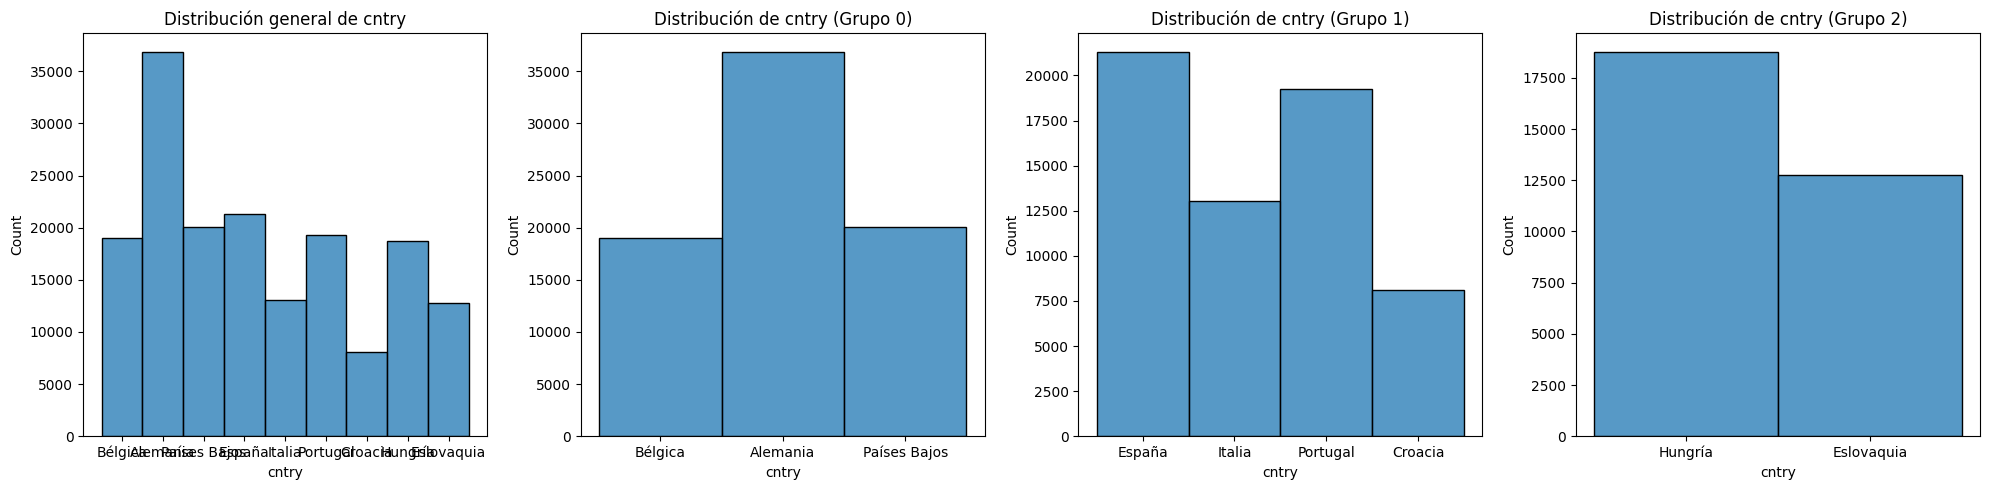

In [24]:
#Vamos a observar la columna cntry para ver la cantidad de muestras de cada pais.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def dist4(df, columna, grupo_columna='cntgrp_fc'):


    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    
    sns.histplot(df[columna], ax=axes[0])
    axes[0].set_title(f'Distribución general de {columna}')

   
    sns.histplot(df[df[grupo_columna] == 0][columna], ax=axes[1])
    axes[1].set_title(f'Distribución de {columna} (Grupo 0)')

    
    sns.histplot(df[df[grupo_columna] == 1][columna], ax=axes[2])
    axes[2].set_title(f'Distribución de {columna} (Grupo 1)')

    
    sns.histplot(df[df[grupo_columna] == 2][columna], ax=axes[3])
    axes[3].set_title(f'Distribución de {columna} (Grupo 2)')

    plt.tight_layout()
    plt.show()


dist4(dfeu, 'cntry')

Como podemos observar en la variable paises, hay un desbalanceo de clases, hay muchas mas muestras de alemania que del resto. Habra que tenerlo en cuenta a la hora de realizar el modelo de clasificacion.
Si el objetivo es ver la naturaleza de las distribuciones y obtener las principales variables estadisticas, un desbalance en las clases de este calibre, nos influira negativamente en el analisis de las distribuciones,
si nos interesa ver como influye cada grupo logico de muestras
.

En este documento se analizaran las principales variables estadisticas de cada columna.
Ademas de hacer una breve descripcion del tipo de funcion que describe la distribucion y un analisis breve de lo que ello significa.
'count': 'Número de muestras sin valores nulos',
'mean': 'Media aritmética',
'std': 'Desviación estándar, nos da una idea de cuanto se alejan los rangos de las muestras respecto a la media aritmetica, con un numero mas grande significa que mas varia',
'min': 'Valor mínimo, el valor minimo',
'25%': 'Percentil 25', el valor del rango de la variable donde se alojan el primer 25% de las muestras, ,
'50%': 'Mediana (percentil 50)', es el valor de la variable donde se divide el 50% de los datos,
'75%': 'Percentil 75', es el valor de la variable donde se ecuentran 3/4 de las muestras totales,
'max': 'Valor máximo', es el valor maximo de la variable que alcanza en el conjunto de las muestras,
'unique': 'Número de valores únicos',
'top': 'Valor más frecuente',
'freq': 'Frecuencia del valor más frecuente'

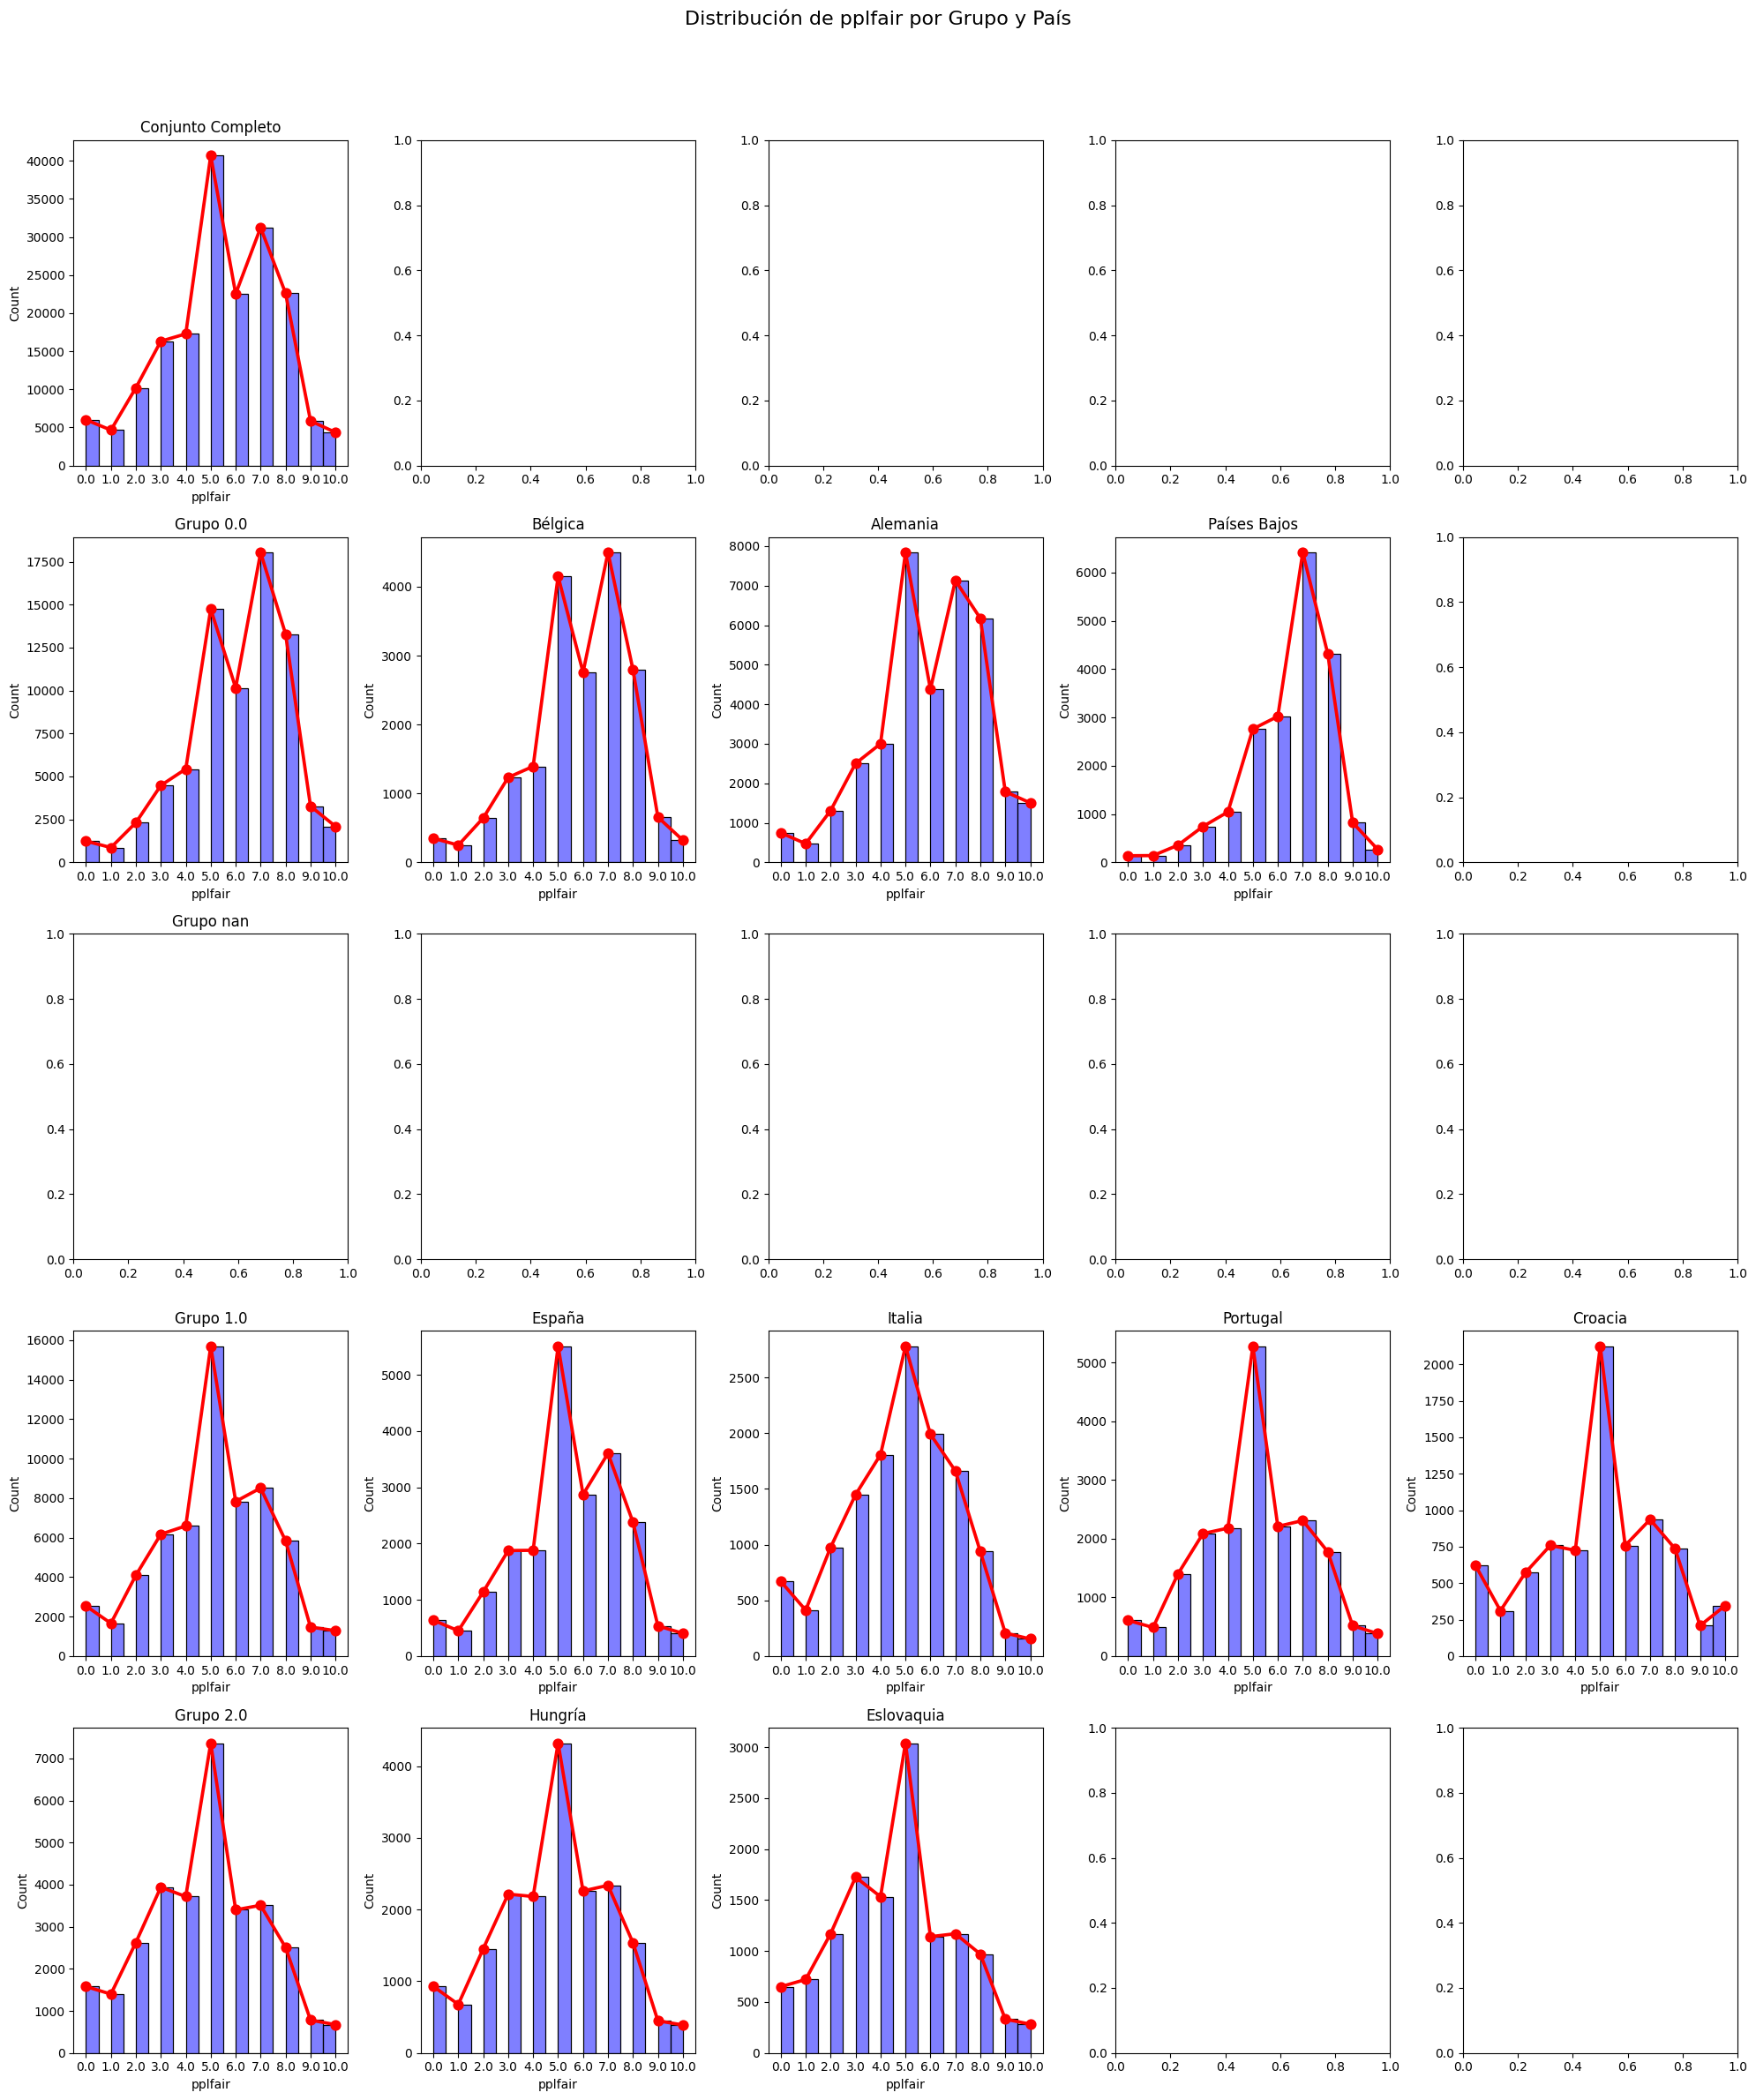

In [25]:
#Para la variable 'pplfair'
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def GroupDist(dataset, columna_a_graficar):


    
    grupos = dataset['cntgrp_fc'].unique()

    
    max_paises = max(dataset.groupby('cntgrp_fc')['cntry'].nunique())

    
    fig, axes = plt.subplots(len(grupos) + 1, max_paises + 1, figsize=(20, 5 * (len(grupos) + 1)))
    fig.suptitle(f'Distribución de {columna_a_graficar} por Grupo y País', fontsize=16)

    
    sns.histplot(dataset[columna_a_graficar], color='blue', alpha=0.5, binwidth=0.5, ax=axes[0, 0])
    sns.pointplot(x=dataset[columna_a_graficar].value_counts().sort_index().index,
                  y=dataset[columna_a_graficar].value_counts().sort_index().values,
                  color='red', linestyles='-', ax=axes[0, 0])
    axes[0, 0].set_title('Conjunto Completo')

    
    for i, grupo in enumerate(grupos):
        datos_grupo = dataset[dataset['cntgrp_fc'] == grupo]
        sns.histplot(datos_grupo[columna_a_graficar], color='blue', alpha=0.5, binwidth=0.5, ax=axes[i + 1, 0])
        sns.pointplot(x=datos_grupo[columna_a_graficar].value_counts().sort_index().index,
                      y=datos_grupo[columna_a_graficar].value_counts().sort_index().values,
                      color='red', linestyles='-', ax=axes[i + 1, 0])
        axes[i + 1, 0].set_title(f'Grupo {grupo}')

        
        paises = dataset[dataset['cntgrp_fc'] == grupo]['cntry'].unique()
        for j, pais in enumerate(paises):
            datos_pais = dataset[(dataset['cntgrp_fc'] == grupo) & (dataset['cntry'] == pais)]
            sns.histplot(datos_pais[columna_a_graficar], color='blue', alpha=0.5, binwidth=0.5, ax=axes[i + 1, j + 1])
            sns.pointplot(x=datos_pais[columna_a_graficar].value_counts().sort_index().index,
                          y=datos_pais[columna_a_graficar].value_counts().sort_index().values,
                          color='red', linestyles='-', ax=axes[i + 1, j + 1])
            axes[i + 1, j + 1].set_title(pais)

    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

GroupDist(dfeu, 'pplfair')

In [26]:
import pandas as pd

def statsgroup(dataset, columna_a_analizar):

    def calcular_varianza(columna):
        return columna.var()
    def calcular_moda_frecuencia(columna):
        moda = columna.mode()
        if not moda.empty:
            frecuencia = columna.value_counts()[moda.iloc[0]]
            return moda.iloc[0], frecuencia
        else:
            return None, None
    print(f"Estadísticas para {columna_a_analizar} - Conjunto Completo:")
    print(dataset[columna_a_analizar].describe())
    moda, frecuencia = calcular_moda_frecuencia(dataset[columna_a_analizar])
    print(f"Moda: {moda}, Frecuencia: {frecuencia}")
    print(f"Varianza: {calcular_varianza(dataset[columna_a_analizar])}")
    print("\n")

    
    grupos = dataset['cntgrp_fc'].unique()
    for grupo in grupos:
        datos_grupo = dataset[dataset['cntgrp_fc'] == grupo]
        print(f"Estadísticas para {columna_a_analizar} - Grupo {grupo}:")
        print(datos_grupo[columna_a_analizar].describe())
        moda, frecuencia = calcular_moda_frecuencia(datos_grupo[columna_a_analizar])
        print(f"Moda: {moda}, Frecuencia: {frecuencia}")
        print(f"Varianza: {calcular_varianza(datos_grupo[columna_a_analizar])}")
        print("\n")

        
        paises = dataset[dataset['cntgrp_fc'] == grupo]['cntry'].unique()
        for pais in paises:
            datos_pais = dataset[(dataset['cntgrp_fc'] == grupo) & (dataset['cntry'] == pais)]
            print(f"Estadísticas para {columna_a_analizar} - País {pais} (Grupo {grupo}):")
            print(datos_pais[columna_a_analizar].describe())
            moda, frecuencia = calcular_moda_frecuencia(datos_pais[columna_a_analizar])
            print(f"Moda: {moda}, Frecuencia: {frecuencia}")
            print(f"Varianza: {calcular_varianza(datos_pais[columna_a_analizar])}")
            print("\n")


statsgroup(dfeu, 'pplfair')

Estadísticas para pplfair - Conjunto Completo:
count    181677.000000
mean          5.378826
std           2.257209
min           0.000000
25%           4.000000
50%           5.000000
75%           7.000000
max          10.000000
Name: pplfair, dtype: float64
Moda: 5.0, Frecuencia: 40682
Varianza: 5.094991459887736


Estadísticas para pplfair - Grupo 0.0:
count    75914.000000
mean         6.036897
std          2.032969
min          0.000000
25%          5.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: pplfair, dtype: float64
Moda: 7.0, Frecuencia: 18038
Varianza: 4.132963411548268


Estadísticas para pplfair - País Bélgica (Grupo 0.0):
count    19045.000000
mean         5.831557
std          1.999339
min          0.000000
25%          5.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: pplfair, dtype: float64
Moda: 7.0, Frecuencia: 4496
Varianza: 3.9973553003424542


Estadísticas para pplfair - País Alemania (Grupo 0.0):
co

Para nuestra variable/columna 'pplfair':
(2-'pplfair': Escala 0 a 10. 0 si crees que la gente intenta aprovecharse, a 10 si crees que la gente es honesta.)
Es una variable discontinua que sigue una distribucion normal simetrica bimodal.
Es decir que la mayor cantidad de muestras se dividen en dos montones claramente visibles y en este caso en particular bastante centrados.
Si observamos esta variable en los conjuntos de paises, conforme los paises son mas pobres, la media aritmetica
va coincidiendo con la moda, por lo que graficamente solo se observa un maximo local y desaparece el segundo.
Tambien se aprecia una disminucion de la varianza.
De momento nuestra hipotesis de que la situacion economica influye en las variables es probable, los dibujos por grupos de paises coinciden bastante con los de paises individualmente.

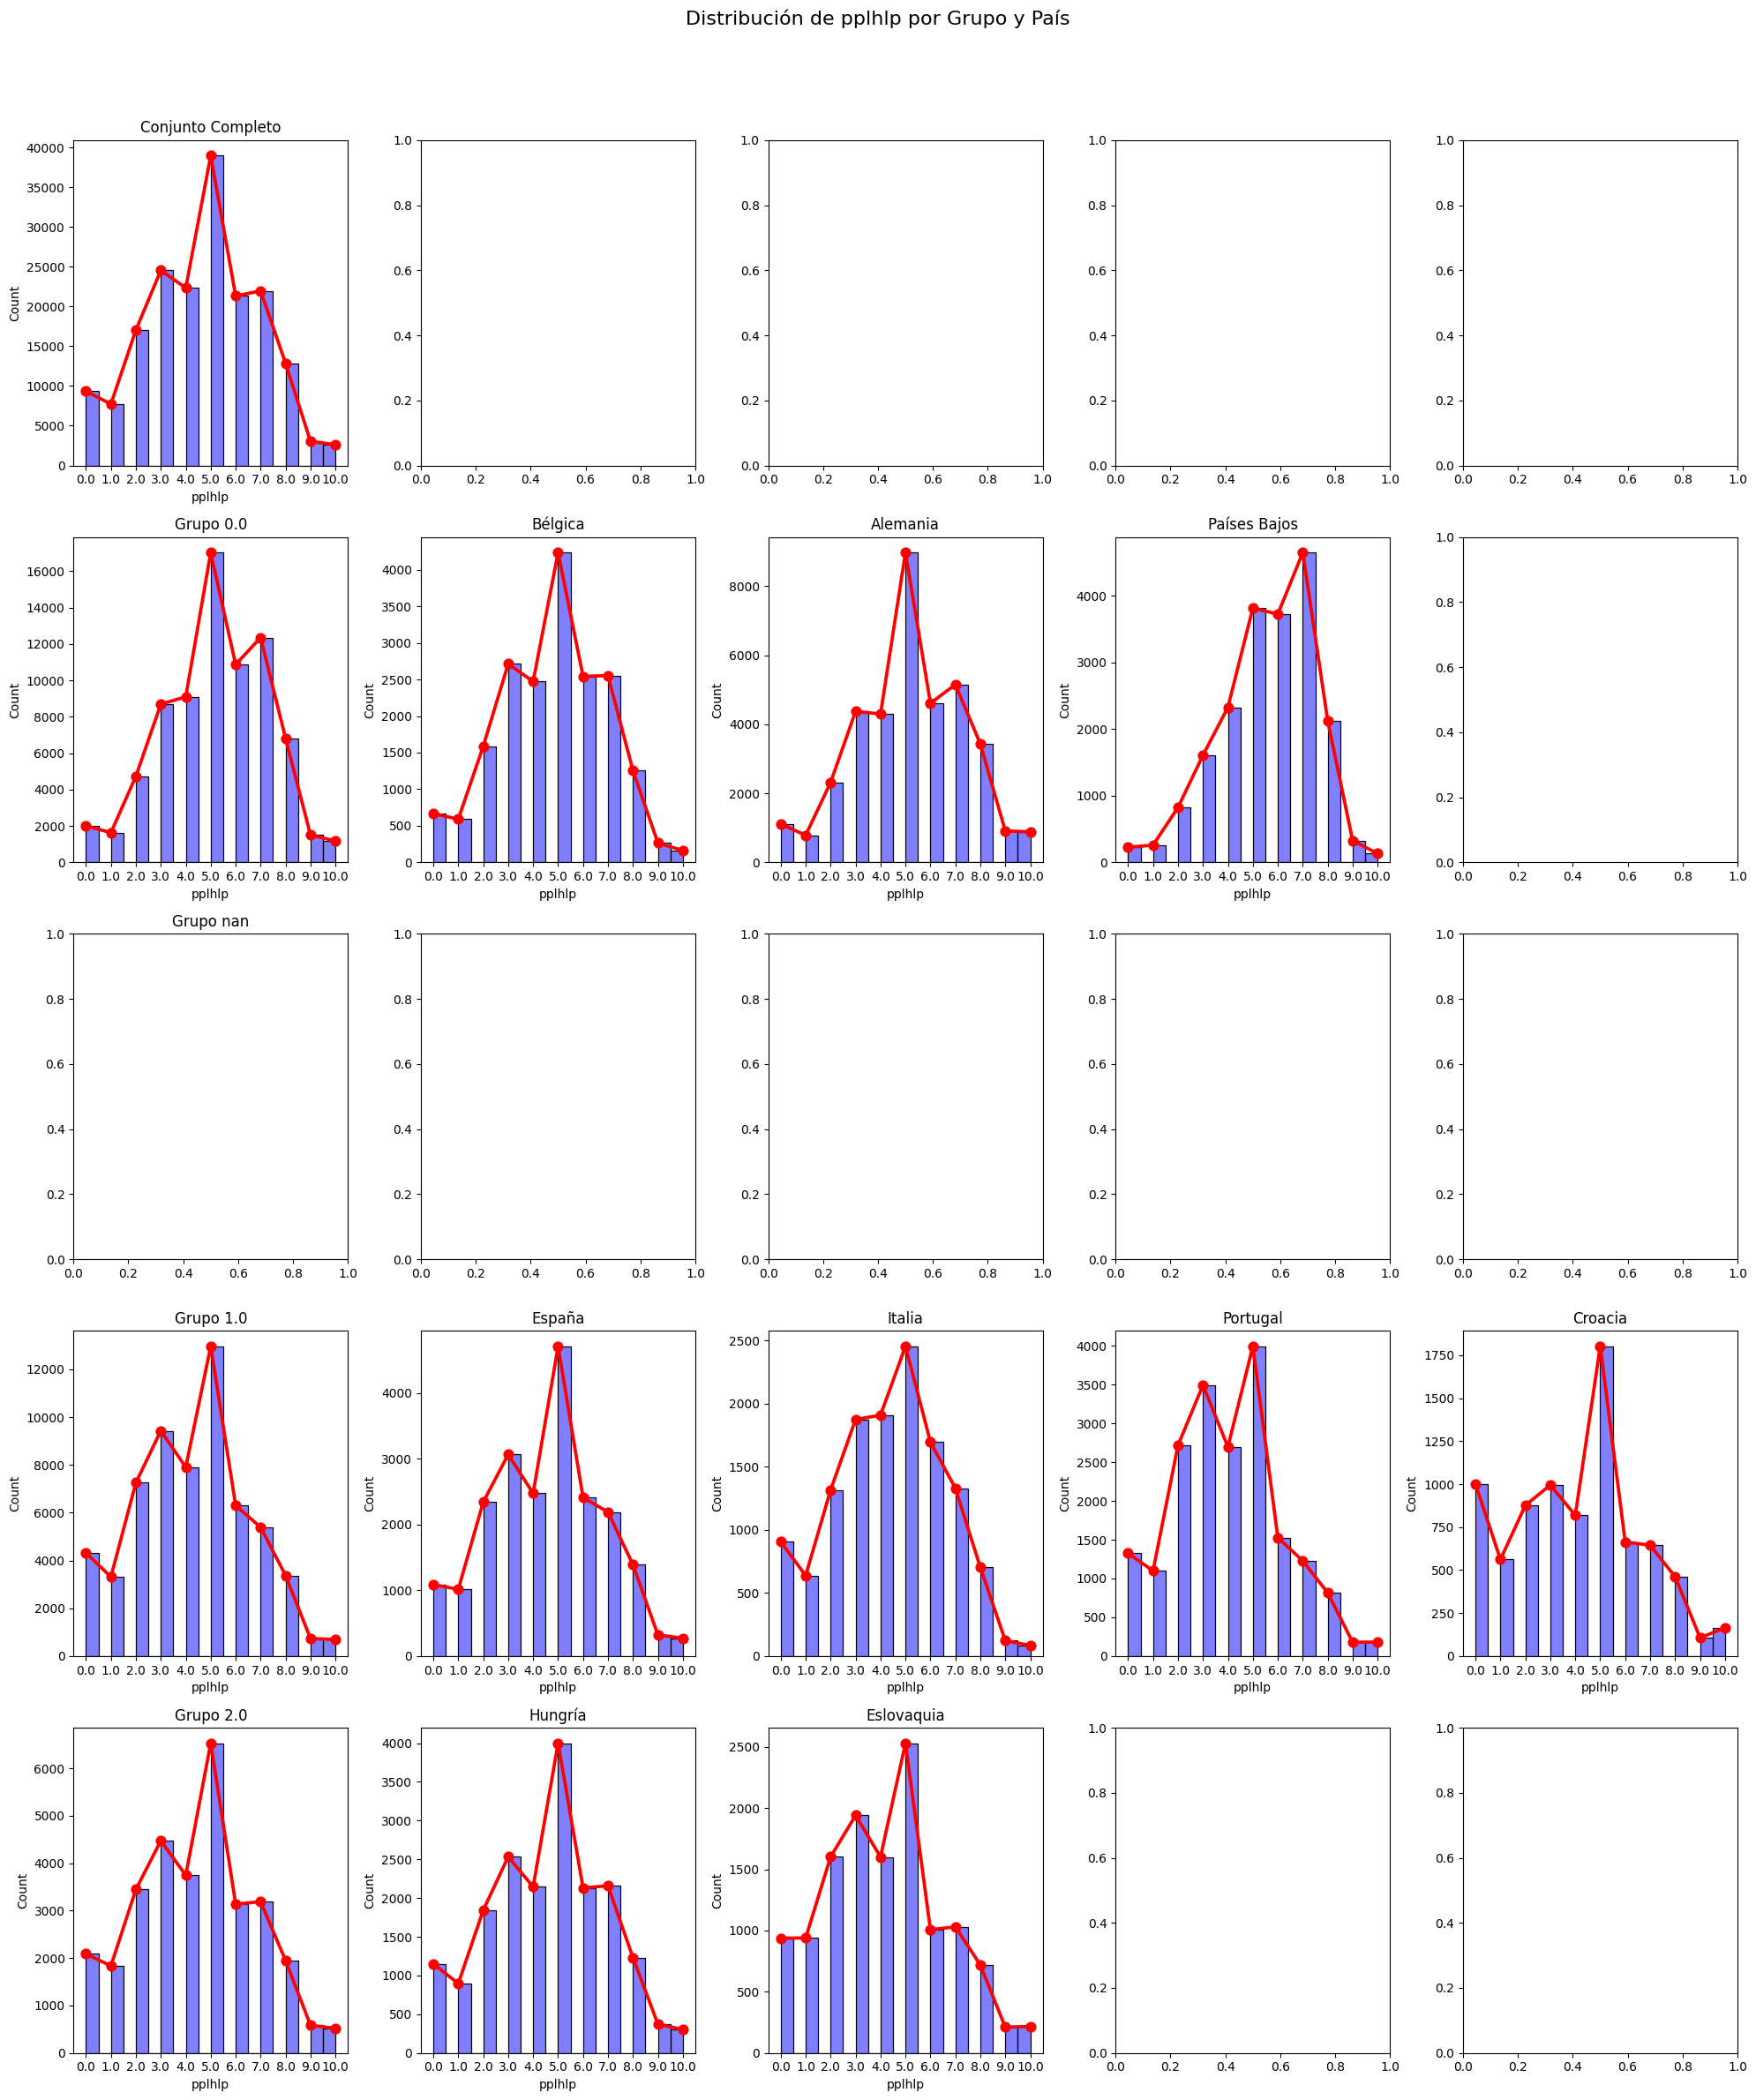

Estadísticas para pplhlp - Conjunto Completo:
count    181757.000000
mean          4.608521
std           2.276653
min           0.000000
25%           3.000000
50%           5.000000
75%           6.000000
max          10.000000
Name: pplhlp, dtype: float64
Moda: 5.0, Frecuencia: 38979
Varianza: 5.1831506099443265


Estadísticas para pplhlp - Grupo 0.0:
count    75914.000000
mean         5.140830
std          2.104809
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: pplhlp, dtype: float64
Moda: 5.0, Frecuencia: 17031
Varianza: 4.430221201253298


Estadísticas para pplhlp - País Bélgica (Grupo 0.0):
count    19045.000000
mean         4.733631
std          2.109227
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: pplhlp, dtype: float64
Moda: 5.0, Frecuencia: 4236
Varianza: 4.448840024419551


Estadísticas para pplhlp - País Alemania (Grupo 0.0):
count    

In [27]:
#Para la variable 'pplhlp'
GroupDist(dfeu, 'pplhlp')
statsgroup(dfeu, 'pplhlp')

Para la variable 'pplhlp':
(3-'pplhlp': Escala 0 a 10. 0 si crees que la gente solo miran por sus intereses, a 10 si crees que la gente mira por el bien comun.)

Variable discontinua que  funcion normal simetrica(gaussiana), si que es cierto que conforme, el grupo de paises es mas pobre
Tiene a bimodalizarse.
Se observa una ligera asimetria hacia un valor de rango positivo en el caso de las muestras de Paises Bajos.
Quiza su escasa poblacion o por cuestiones culturales, la gente tiende a pensar que la gente mira por el bien comun.
La variable con el conjunto total de muestras tiende a asemejarse a la distribucion Alemana, a parte de porque es el conjunto
con mas muestras tambien es porque casi todos los paises tienen distribuciones parejas.
El criterio de agrupacion sigue cumpliendose con apenas diferencias en las distribuciones del grupo y sus paises.

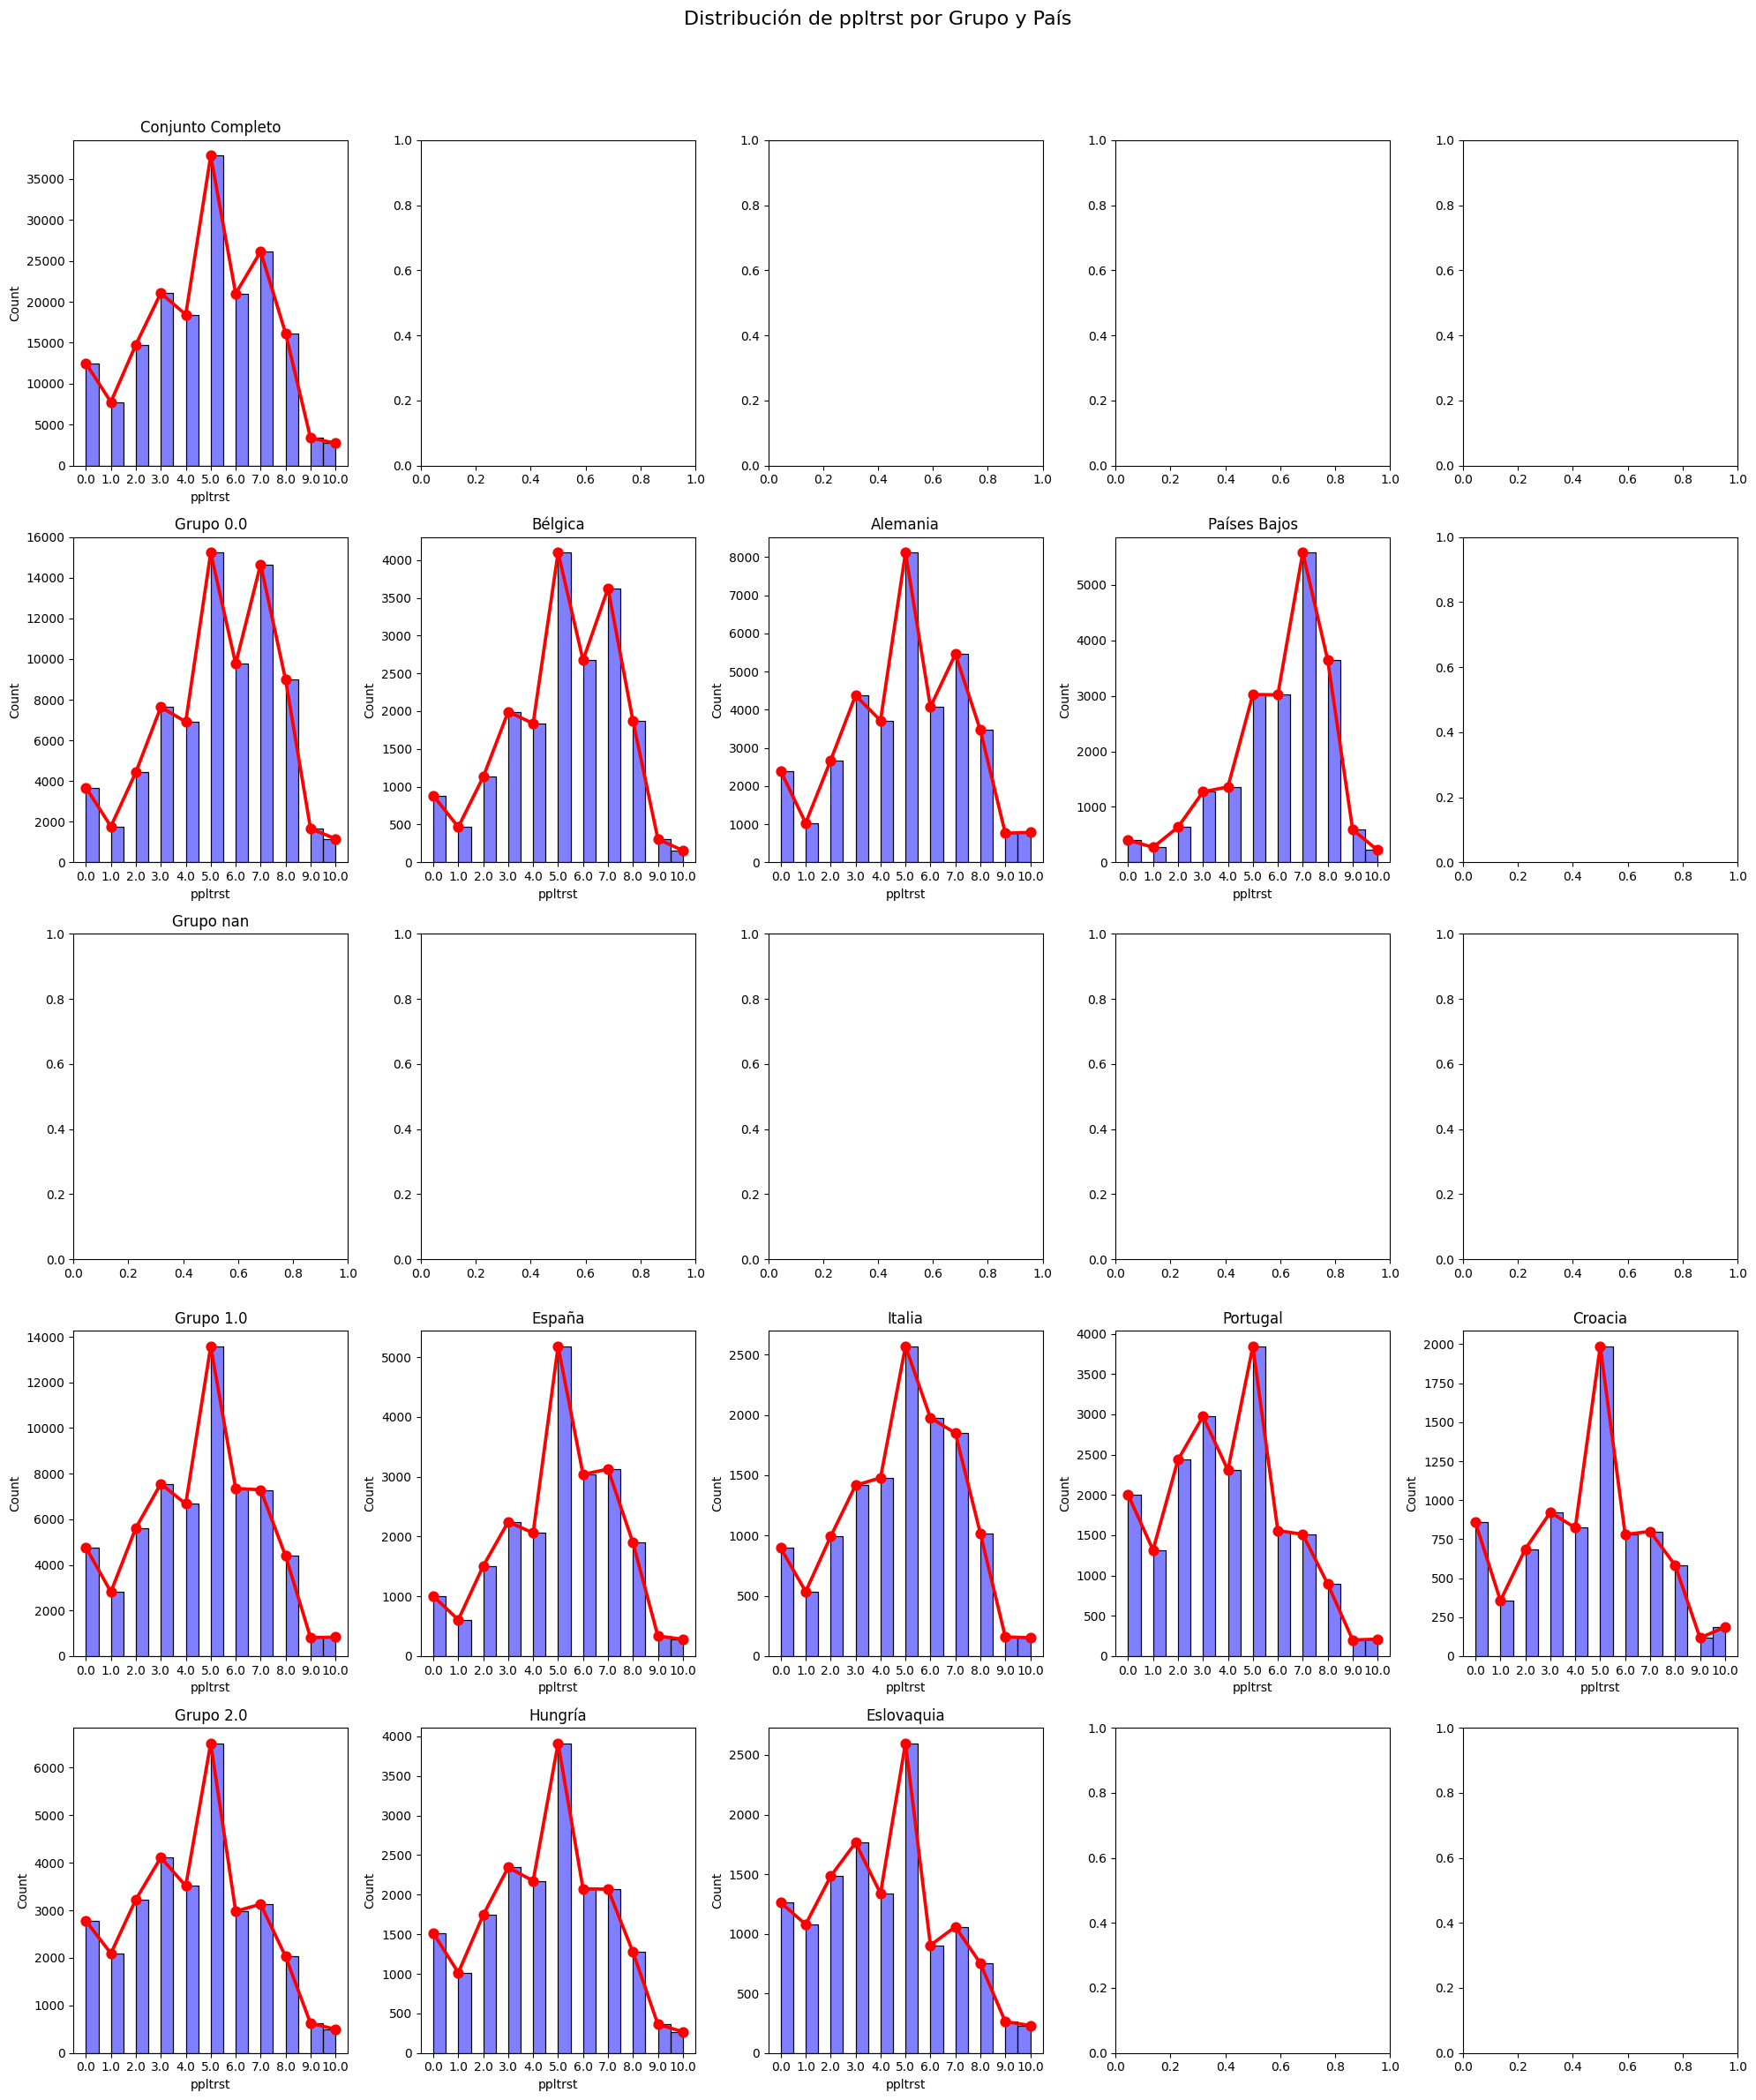

In [28]:
GroupDist(dfeu, 'ppltrst')

In [29]:
statsgroup(dfeu, 'ppltrst')

Estadísticas para ppltrst - Conjunto Completo:
count    181756.000000
mean          4.728031
std           2.404708
min           0.000000
25%           3.000000
50%           5.000000
75%           7.000000
max          10.000000
Name: ppltrst, dtype: float64
Moda: 5.0, Frecuencia: 37863
Varianza: 5.7826196128276175


Estadísticas para ppltrst - Grupo 0.0:
count    75914.000000
mean         5.231249
std          2.291035
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: ppltrst, dtype: float64
Moda: 5.0, Frecuencia: 15243
Varianza: 5.248843179237525


Estadísticas para ppltrst - País Bélgica (Grupo 0.0):
count    19045.000000
mean         5.107955
std          2.199989
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: ppltrst, dtype: float64
Moda: 5.0, Frecuencia: 4099
Varianza: 4.839951945030752


Estadísticas para ppltrst - País Alemania (Grupo 0.0):
co

4-'ppltrst': Escala de 0 a 10. 0 Si crees que no puedes confiar en nadie, a 10 si crees que se puede confiar.
Variable discontinua que describe a primera vista una funcion normal simetrica bimodal, escepto en el grupo dos donde casi se asemeja
a su media aritmetica.
En el primer grupo tiende a bimodalizarse a partir de rangos mayores a la media aritmetica por lo que sugiere que conforme, las condiciones economicas son mejores, la gente suele confiar mas.
En el segundo grupo se aprecian discrepancias entre las muestras de los distintos paises, aun asi se asemejan al grafico de muestras
de su grupo.
En el  tercer grupo se puede apreciar incluso una funcion normal simetrica trimodal, con ambos dos subconjuntos alrededor del valor, tanto por arriba como por abajo de la media aritmetica de la variable.
Bastante bien distribuido, en todo el rango de la variable.
En el conjunto global de datos de esta variable, casi se describe una distribucion simetrica trimodal.
Por lo general las distribuciones entre paises y sus grupos se asemejan bastante.


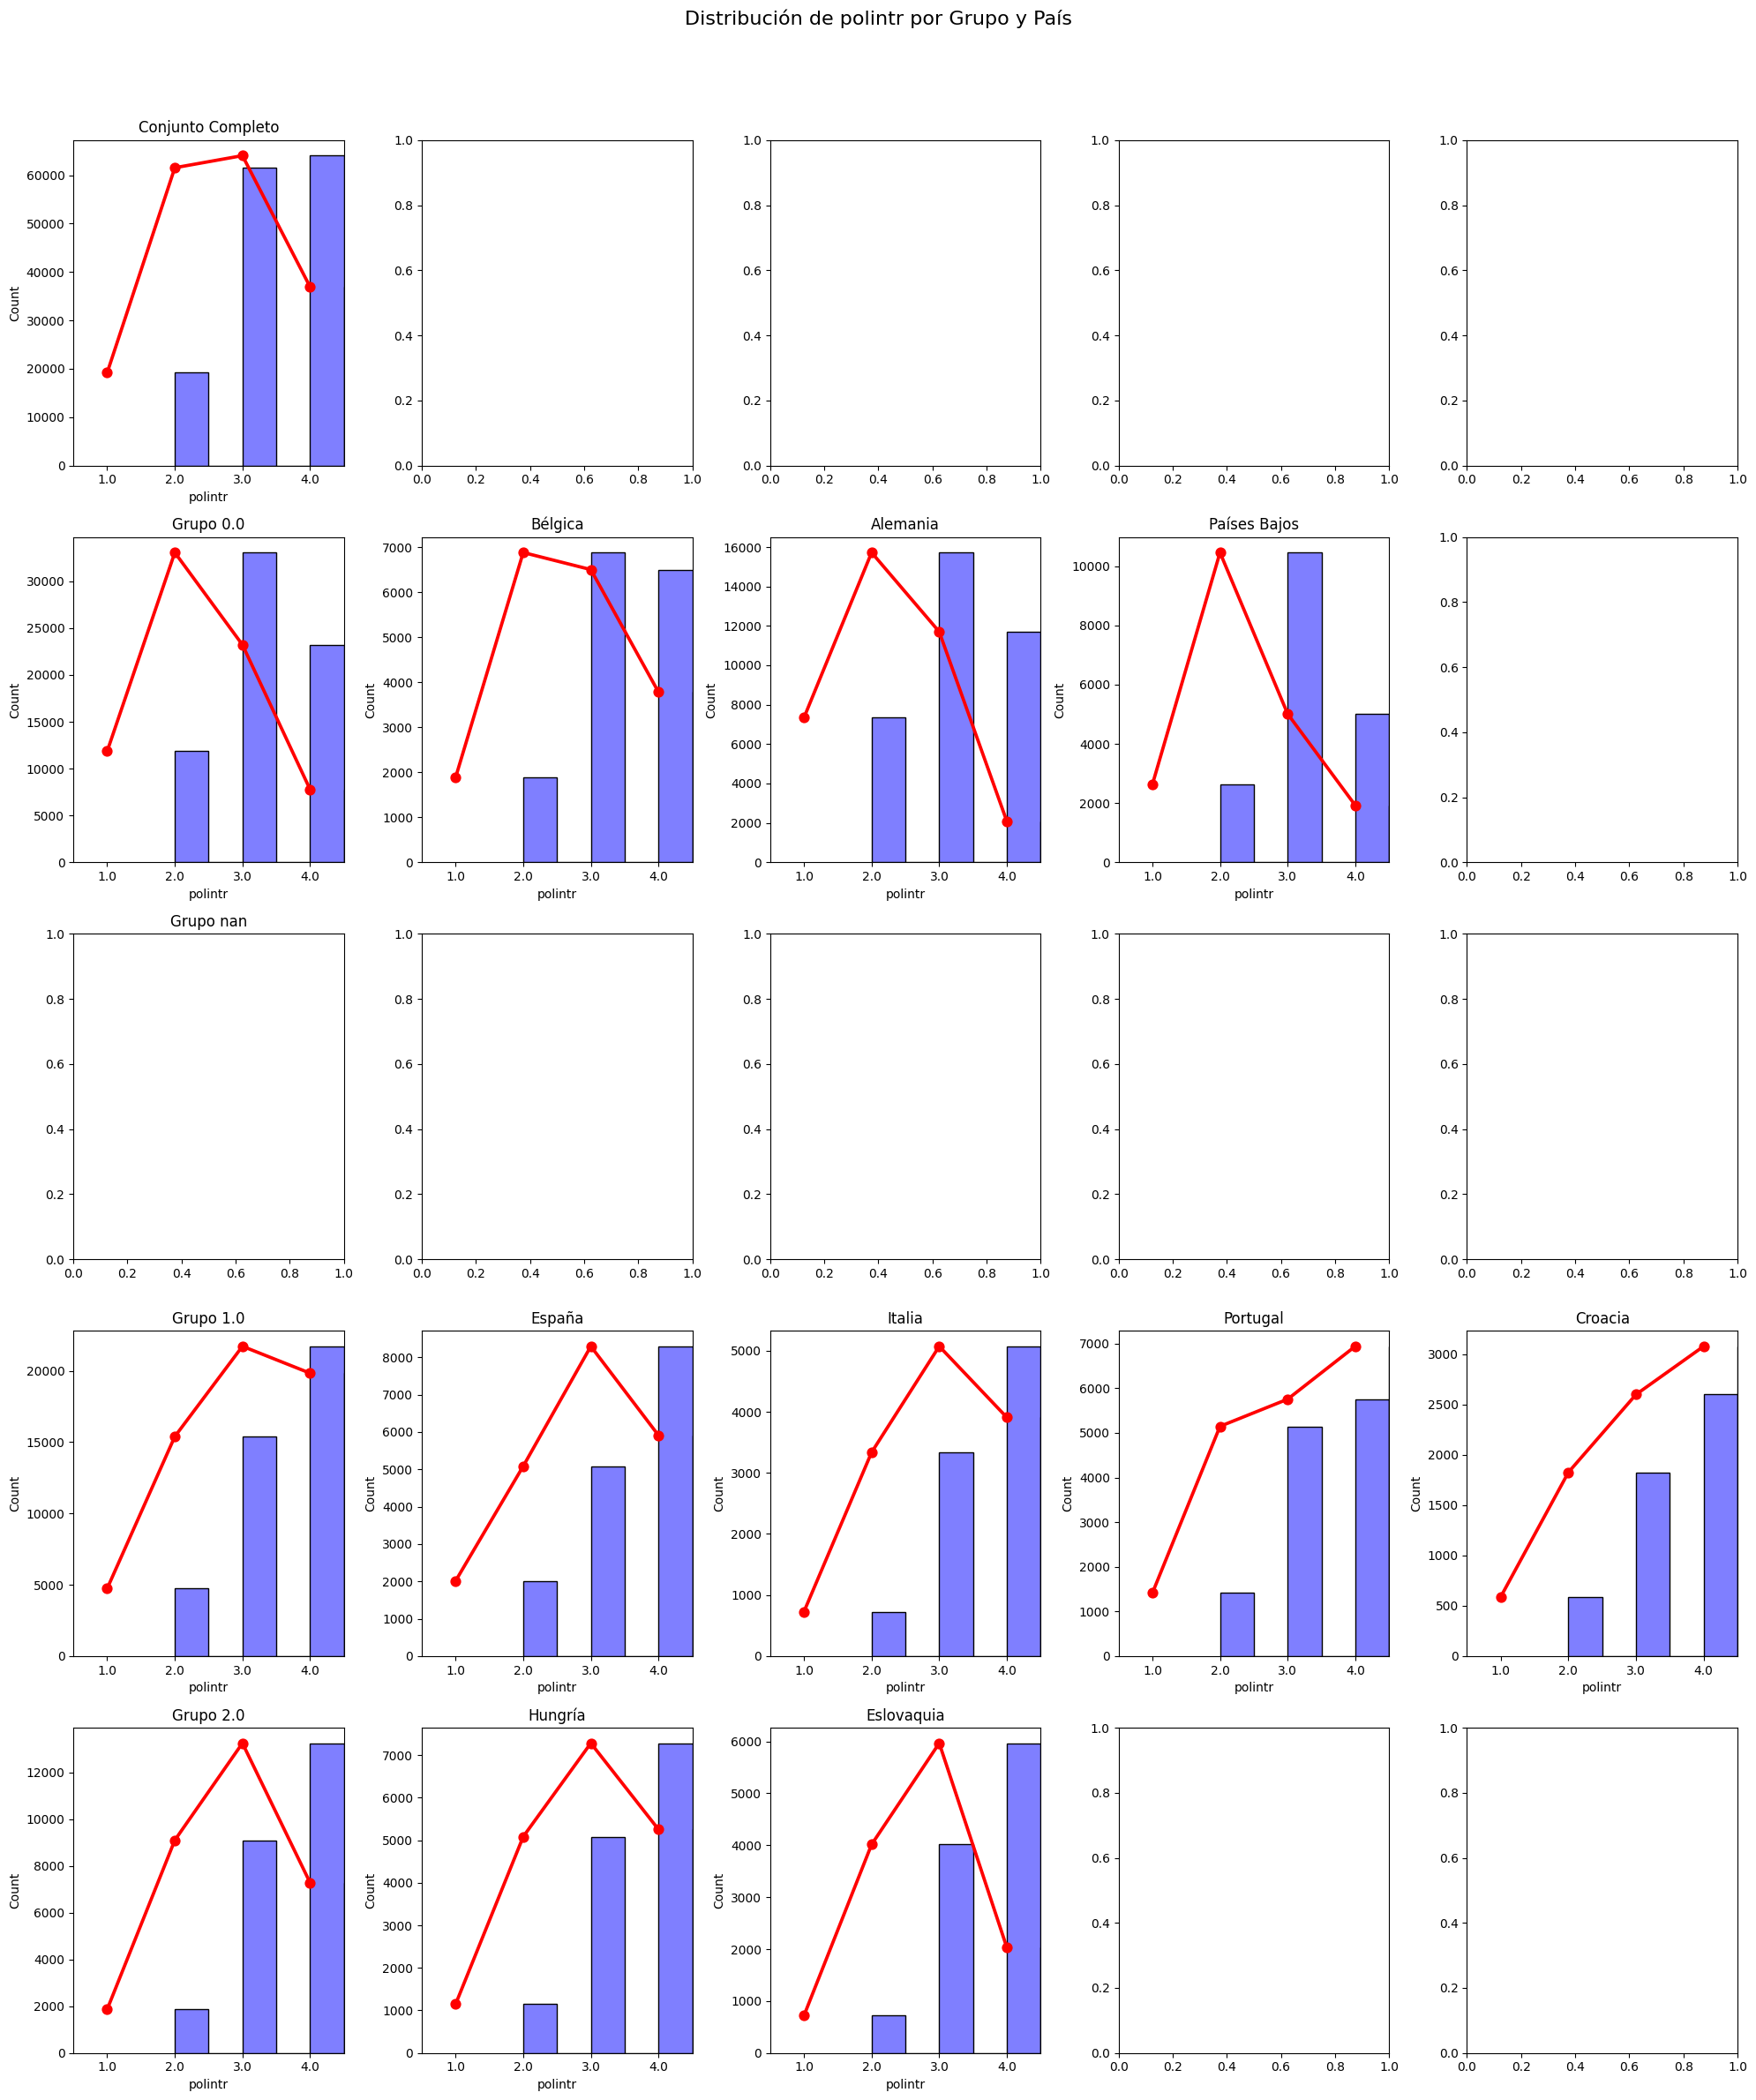

In [30]:
#Variable 'polintr'
GroupDist(dfeu, 'polintr')

In [31]:
statsgroup(dfeu, 'polintr')

Estadísticas para polintr - Conjunto Completo:
count    181755.000000
mean          2.653336
std           0.918698
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max           4.000000
Name: polintr, dtype: float64
Moda: 3.0, Frecuencia: 64069
Varianza: 0.8440054432499586


Estadísticas para polintr - Grupo 0.0:
count    75914.000000
mean         2.354664
std          0.863880
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: polintr, dtype: float64
Moda: 2.0, Frecuencia: 33061
Varianza: 0.7462886897439018


Estadísticas para polintr - País Bélgica (Grupo 0.0):
count    19045.000000
mean         2.639380
std          0.908641
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max          4.000000
Name: polintr, dtype: float64
Moda: 2.0, Frecuencia: 6879
Varianza: 0.8256282655374252


Estadísticas para polintr - País Alemania (Grupo 0.0):


5-'polintr': Escala de 1 a 4 de intensidad. 1 muy interesado en politica, a 4 estando nada interesado.
Variable discontinua con 5 posibles valores, su distribucion sigue una funcion normal con un detalle interesante a comentar.
Conforme vamos mirando los graficos por grupos de paises podemos observar tanto en las graficas como en los datos de moda y media aritmetica, conforme los grupos son de paises mas pobres , el interes por politica se va perdiendo.
Es decir la media aritmetica cercana a 2 del grupo 0(rico), se va desplazando hasta casi alcanzar el 3 en el grupo 2.
Por el desbalance de clases(hay muchas mas muestras del grupo 0 al resto) agrupando por grupos de paises,
La distribucion general se centra en el valor medio aritmetico de la variable discontinua.


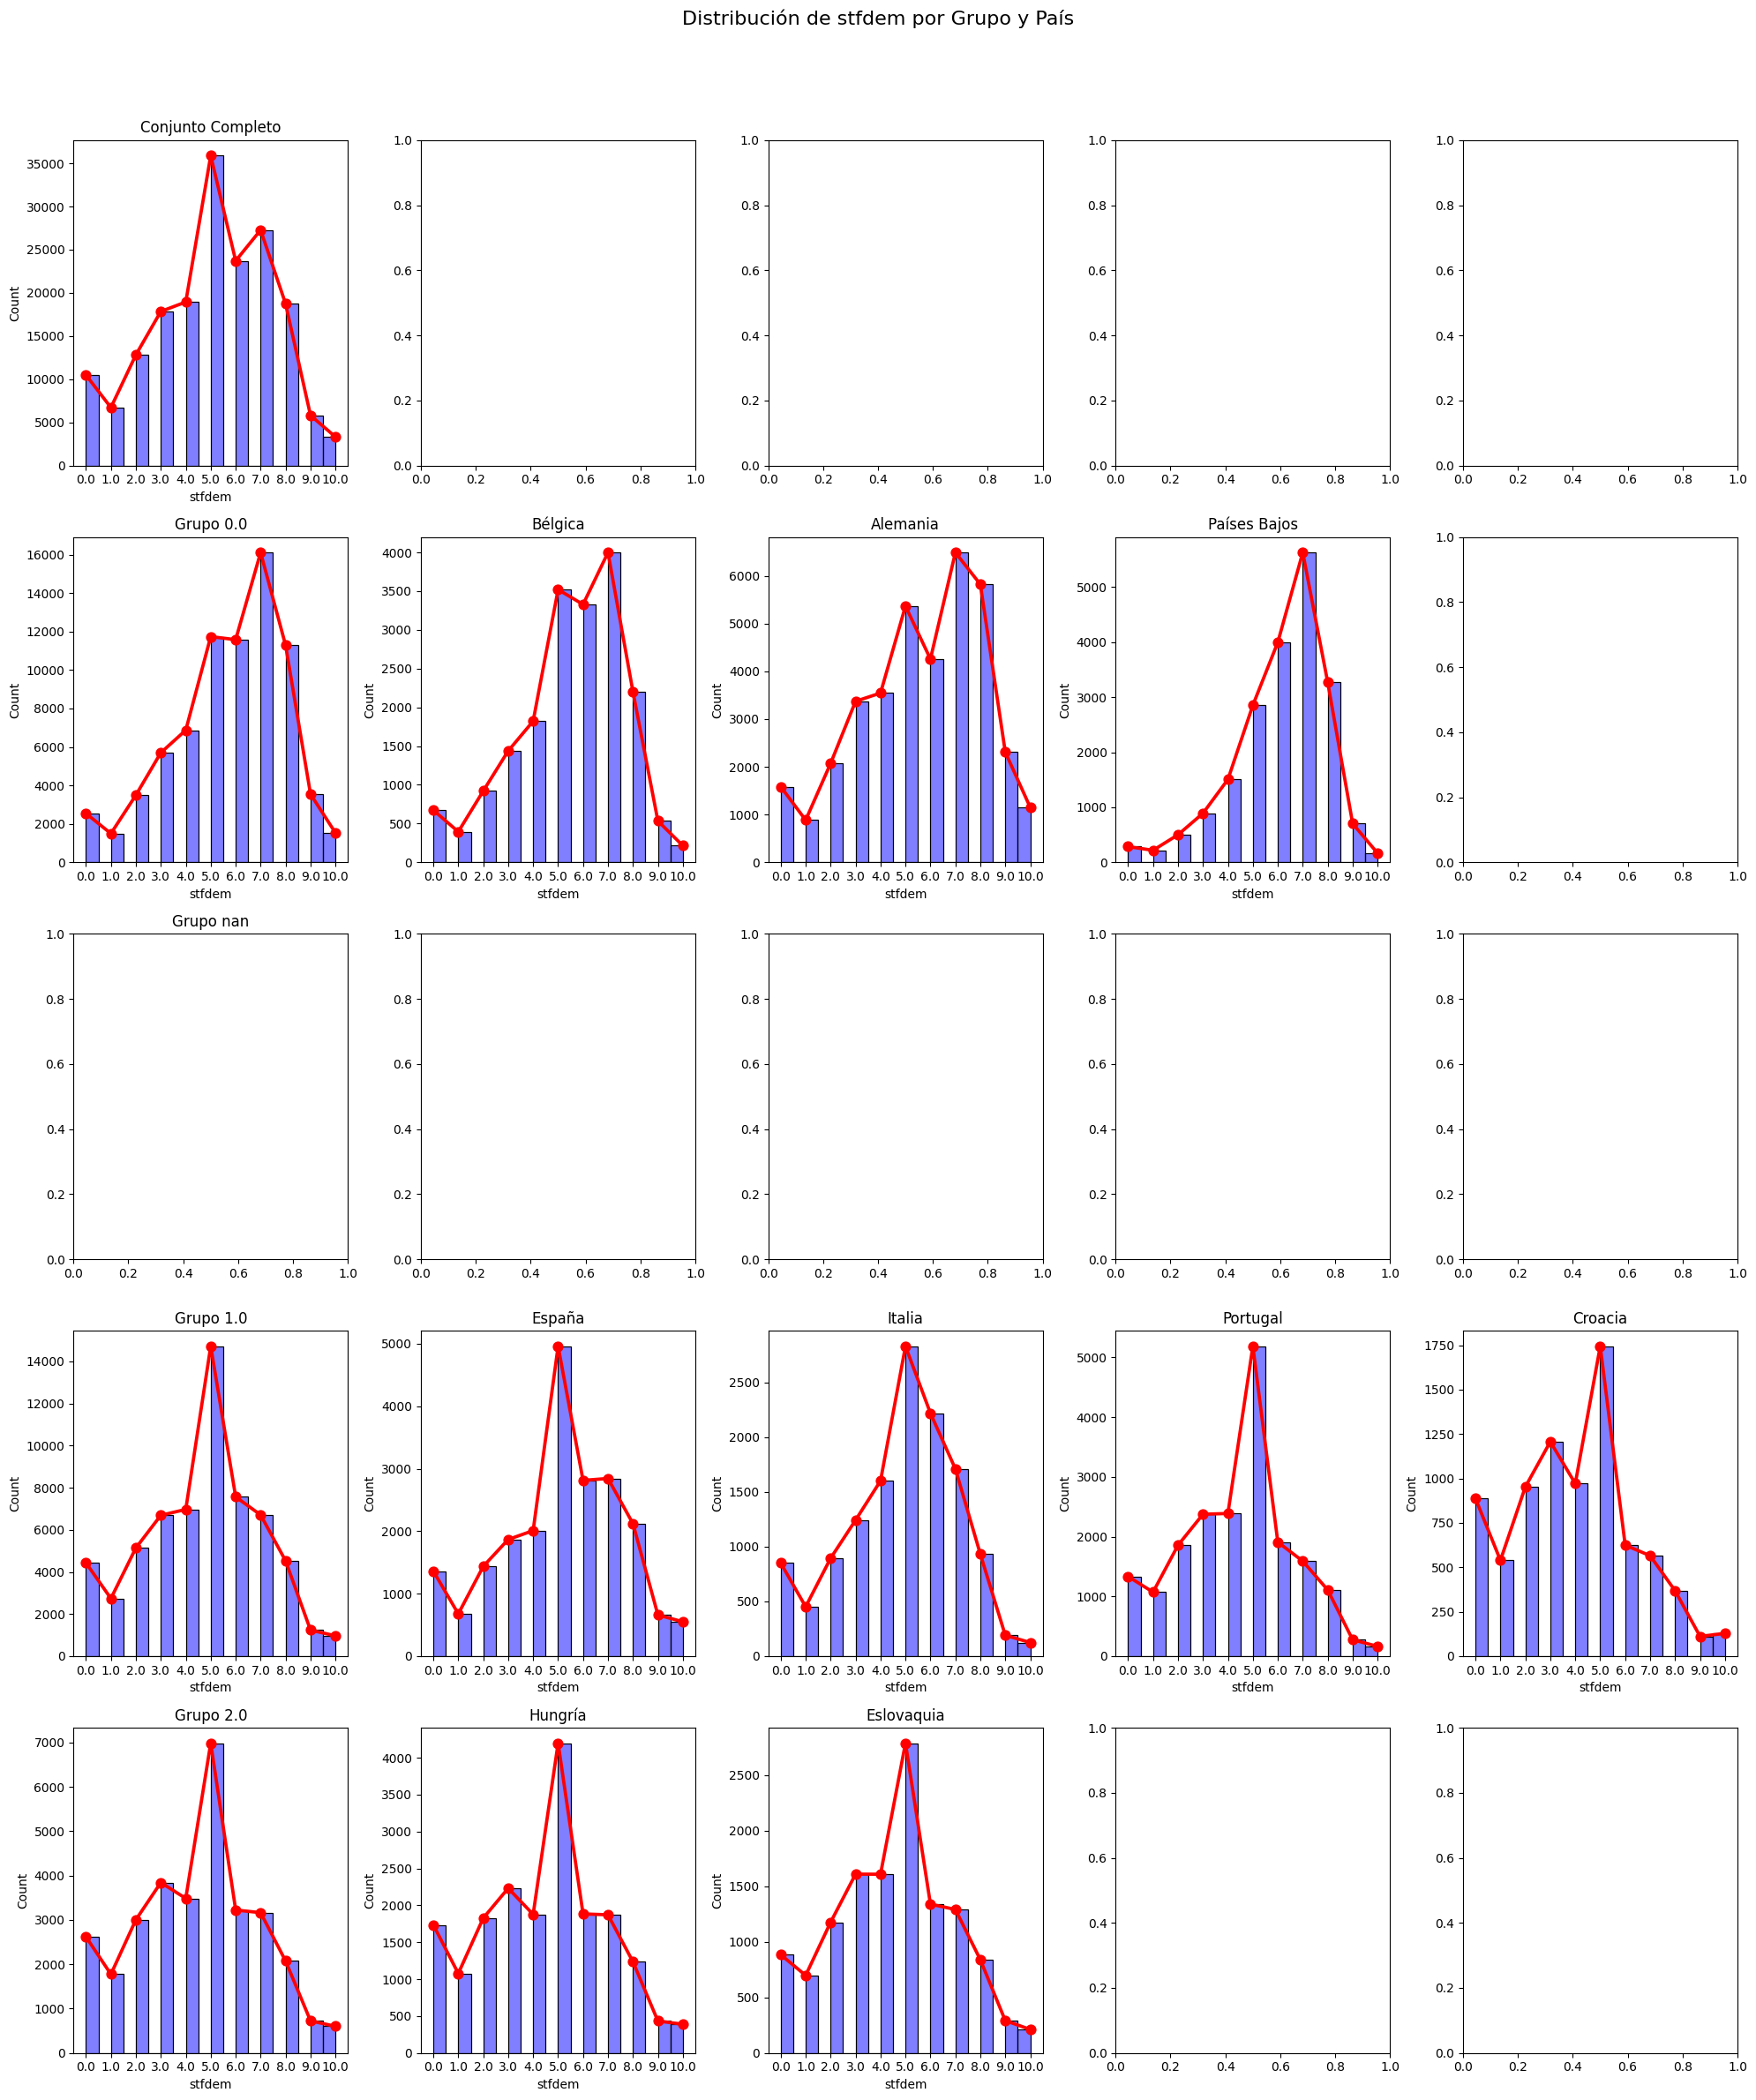

In [32]:
#Variable 'stfdem'
GroupDist(dfeu, 'stfdem')

In [33]:
statsgroup(dfeu, 'stfdem')

Estadísticas para stfdem - Conjunto Completo:
count    181493.000000
mean          5.010562
std           2.407284
min           0.000000
25%           3.000000
50%           5.000000
75%           7.000000
max          10.000000
Name: stfdem, dtype: float64
Moda: 5.0, Frecuencia: 35892
Varianza: 5.795014391250122


Estadísticas para stfdem - Grupo 0.0:
count    75914.000000
mean         5.685657
std          2.253938
min          0.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: stfdem, dtype: float64
Moda: 7.0, Frecuencia: 16114
Varianza: 5.080234529480414


Estadísticas para stfdem - País Bélgica (Grupo 0.0):
count    19045.000000
mean         5.458493
std          2.150263
min          0.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: stfdem, dtype: float64
Moda: 7.0, Frecuencia: 3998
Varianza: 4.623631524381861


Estadísticas para stfdem - País Alemania (Grupo 0.0):
count    3

6-'stfdem': Escala de 0 a 10. 0 siendo muy insatisfecho en como funciona la democracia(ley electoral) en tu pais, a 10 estando muy satisfecho.
Variable que en el conjunto global de los datos describe claramente una funcion simetrica bimodal, algo desplazada positivamente respecto a la media aritmetica de la variable.
Las muestras del grupo 1 tienden a tener mas densidad de la media aritmetica a valores mas grandes a este.
Conforme bajamos al conjunto de datos del grupo 1 y 2 de paises, las muestras tienden a modalizar en la media aritmetica por lo que sugiere que la instatisfaccion aumenta en funcion del empeoramiento economico, incluso en el grupo tres se aprecia claramente
unua funcion normal simetrica trimodal, con dos grandes gruesos de muestras alrededor de la media aritmetica.
Los conjuntos de muestras por pais respetan bastante y se asemejan bastante al grupo de paises al que pertenecen.

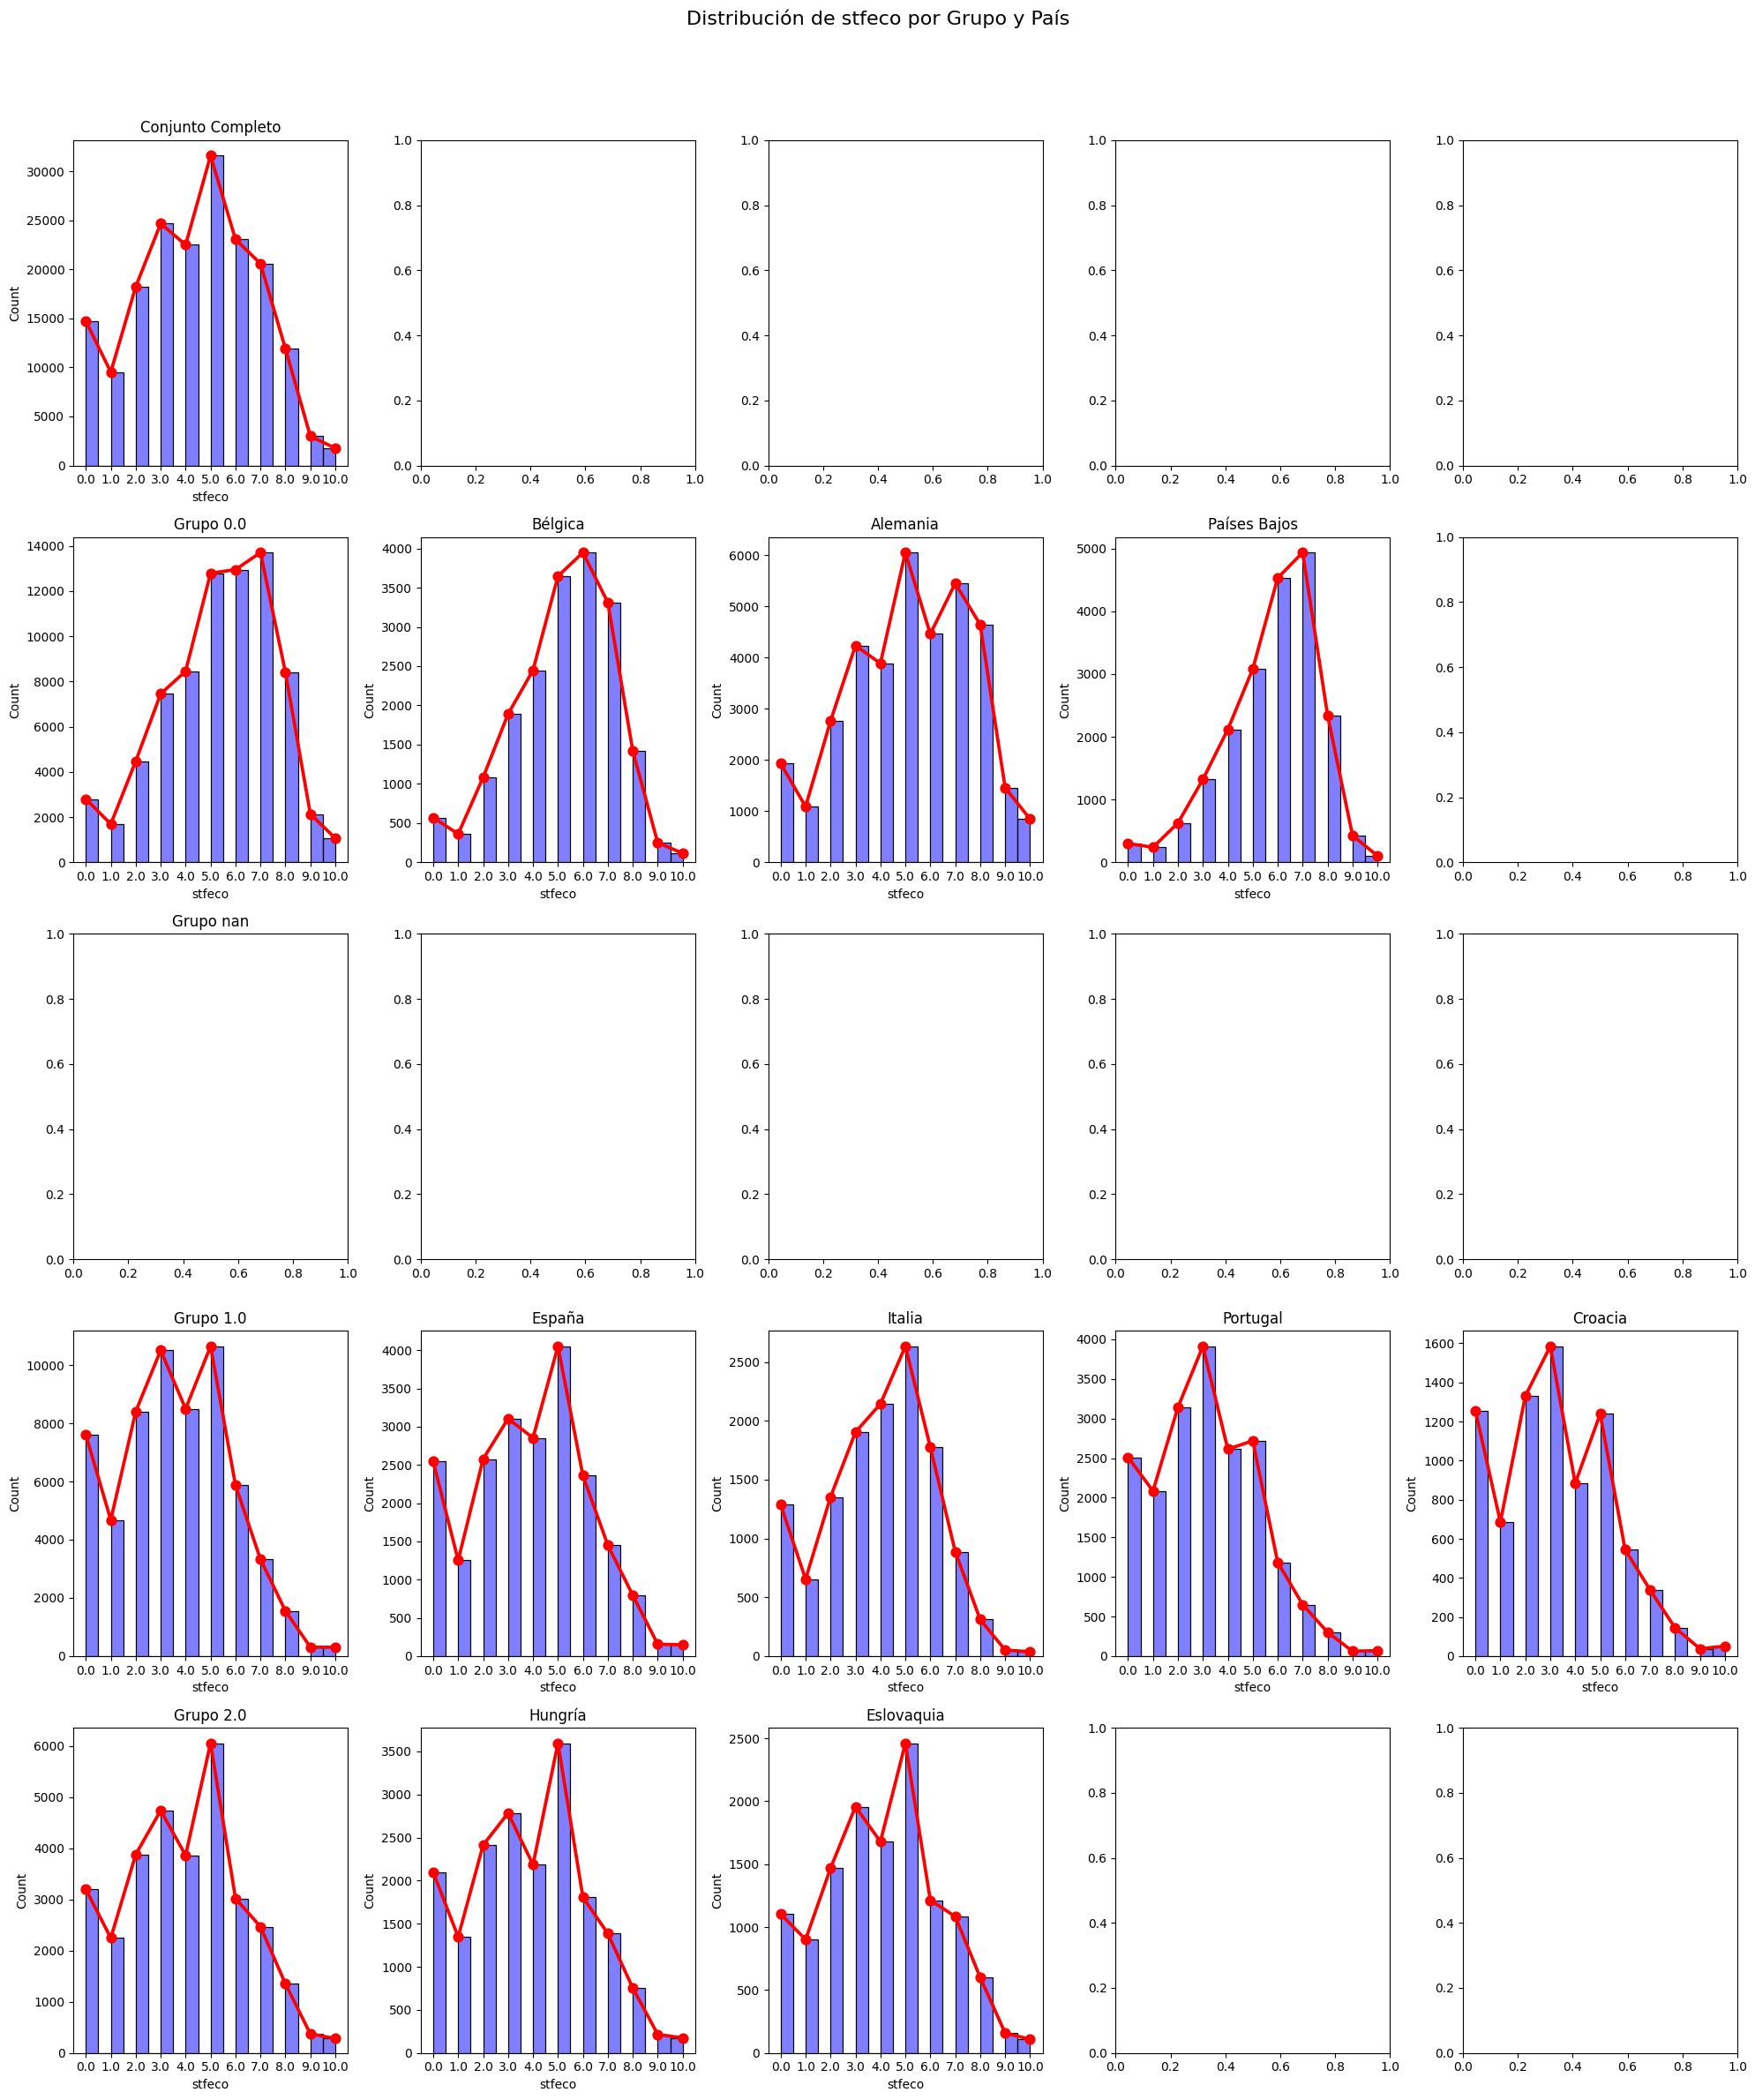

In [34]:
#Variable 'stfeco'
GroupDist(dfeu, 'stfeco')

In [35]:
statsgroup(dfeu, 'stfeco')

Estadísticas para stfeco - Conjunto Completo:
count    181470.000000
mean          4.353133
std           2.386447
min           0.000000
25%           3.000000
50%           5.000000
75%           6.000000
max          10.000000
Name: stfeco, dtype: float64
Moda: 5.0, Frecuencia: 31585
Varianza: 5.695128060616807


Estadísticas para stfeco - Grupo 0.0:
count    75914.000000
mean         5.288458
std          2.218438
min          0.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: stfeco, dtype: float64
Moda: 7.0, Frecuencia: 13700
Varianza: 4.92146729667562


Estadísticas para stfeco - País Bélgica (Grupo 0.0):
count    19045.000000
mean         5.138199
std          2.001814
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: stfeco, dtype: float64
Moda: 6.0, Frecuencia: 3948
Varianza: 4.007260041261345


Estadísticas para stfeco - País Alemania (Grupo 0.0):
count    36

7-'stfeco': Escala de 0 a 10. 0 siendo muy insatisfecho en el estado de la economia de tu pais, a 10 estando muy satisfecho.
MUY IMPORTANTE, es en esta variable donde se demuestra mi hipotesis de que el nivel economico afecta a la distribucion de las muestras en muchas de las variables del estudio.
La variable discontinua a computo general, describe una funcion/distribucion normal simetrica trimodal, si que es cierto que hay mas muestras en el valor de la media aritmetica y el valor central del rango de la variable.
No se aprecia tanto debido al desbalanceo de muestras del Grupo 0(Paises ricos tienen 2 veces mas muestras que el grupo1 y tres mas que el grupo 2) y ademas este grupo si que estan satisfechos con la situacion economica de su pais, se aprecia en la distribucion asimetrica desplazada positivamente de la media aritmetica del rango de la variable.
Pero conforme bajamos al GRupo1(Media UE) y al Grupo 2(Paises mas pobres de la UE) se aprecia como la distribucion simetrica se bimodaliza y ademas se desplaza el eje del 50% de las muestras a un rango inferior del valor medio de la variable.

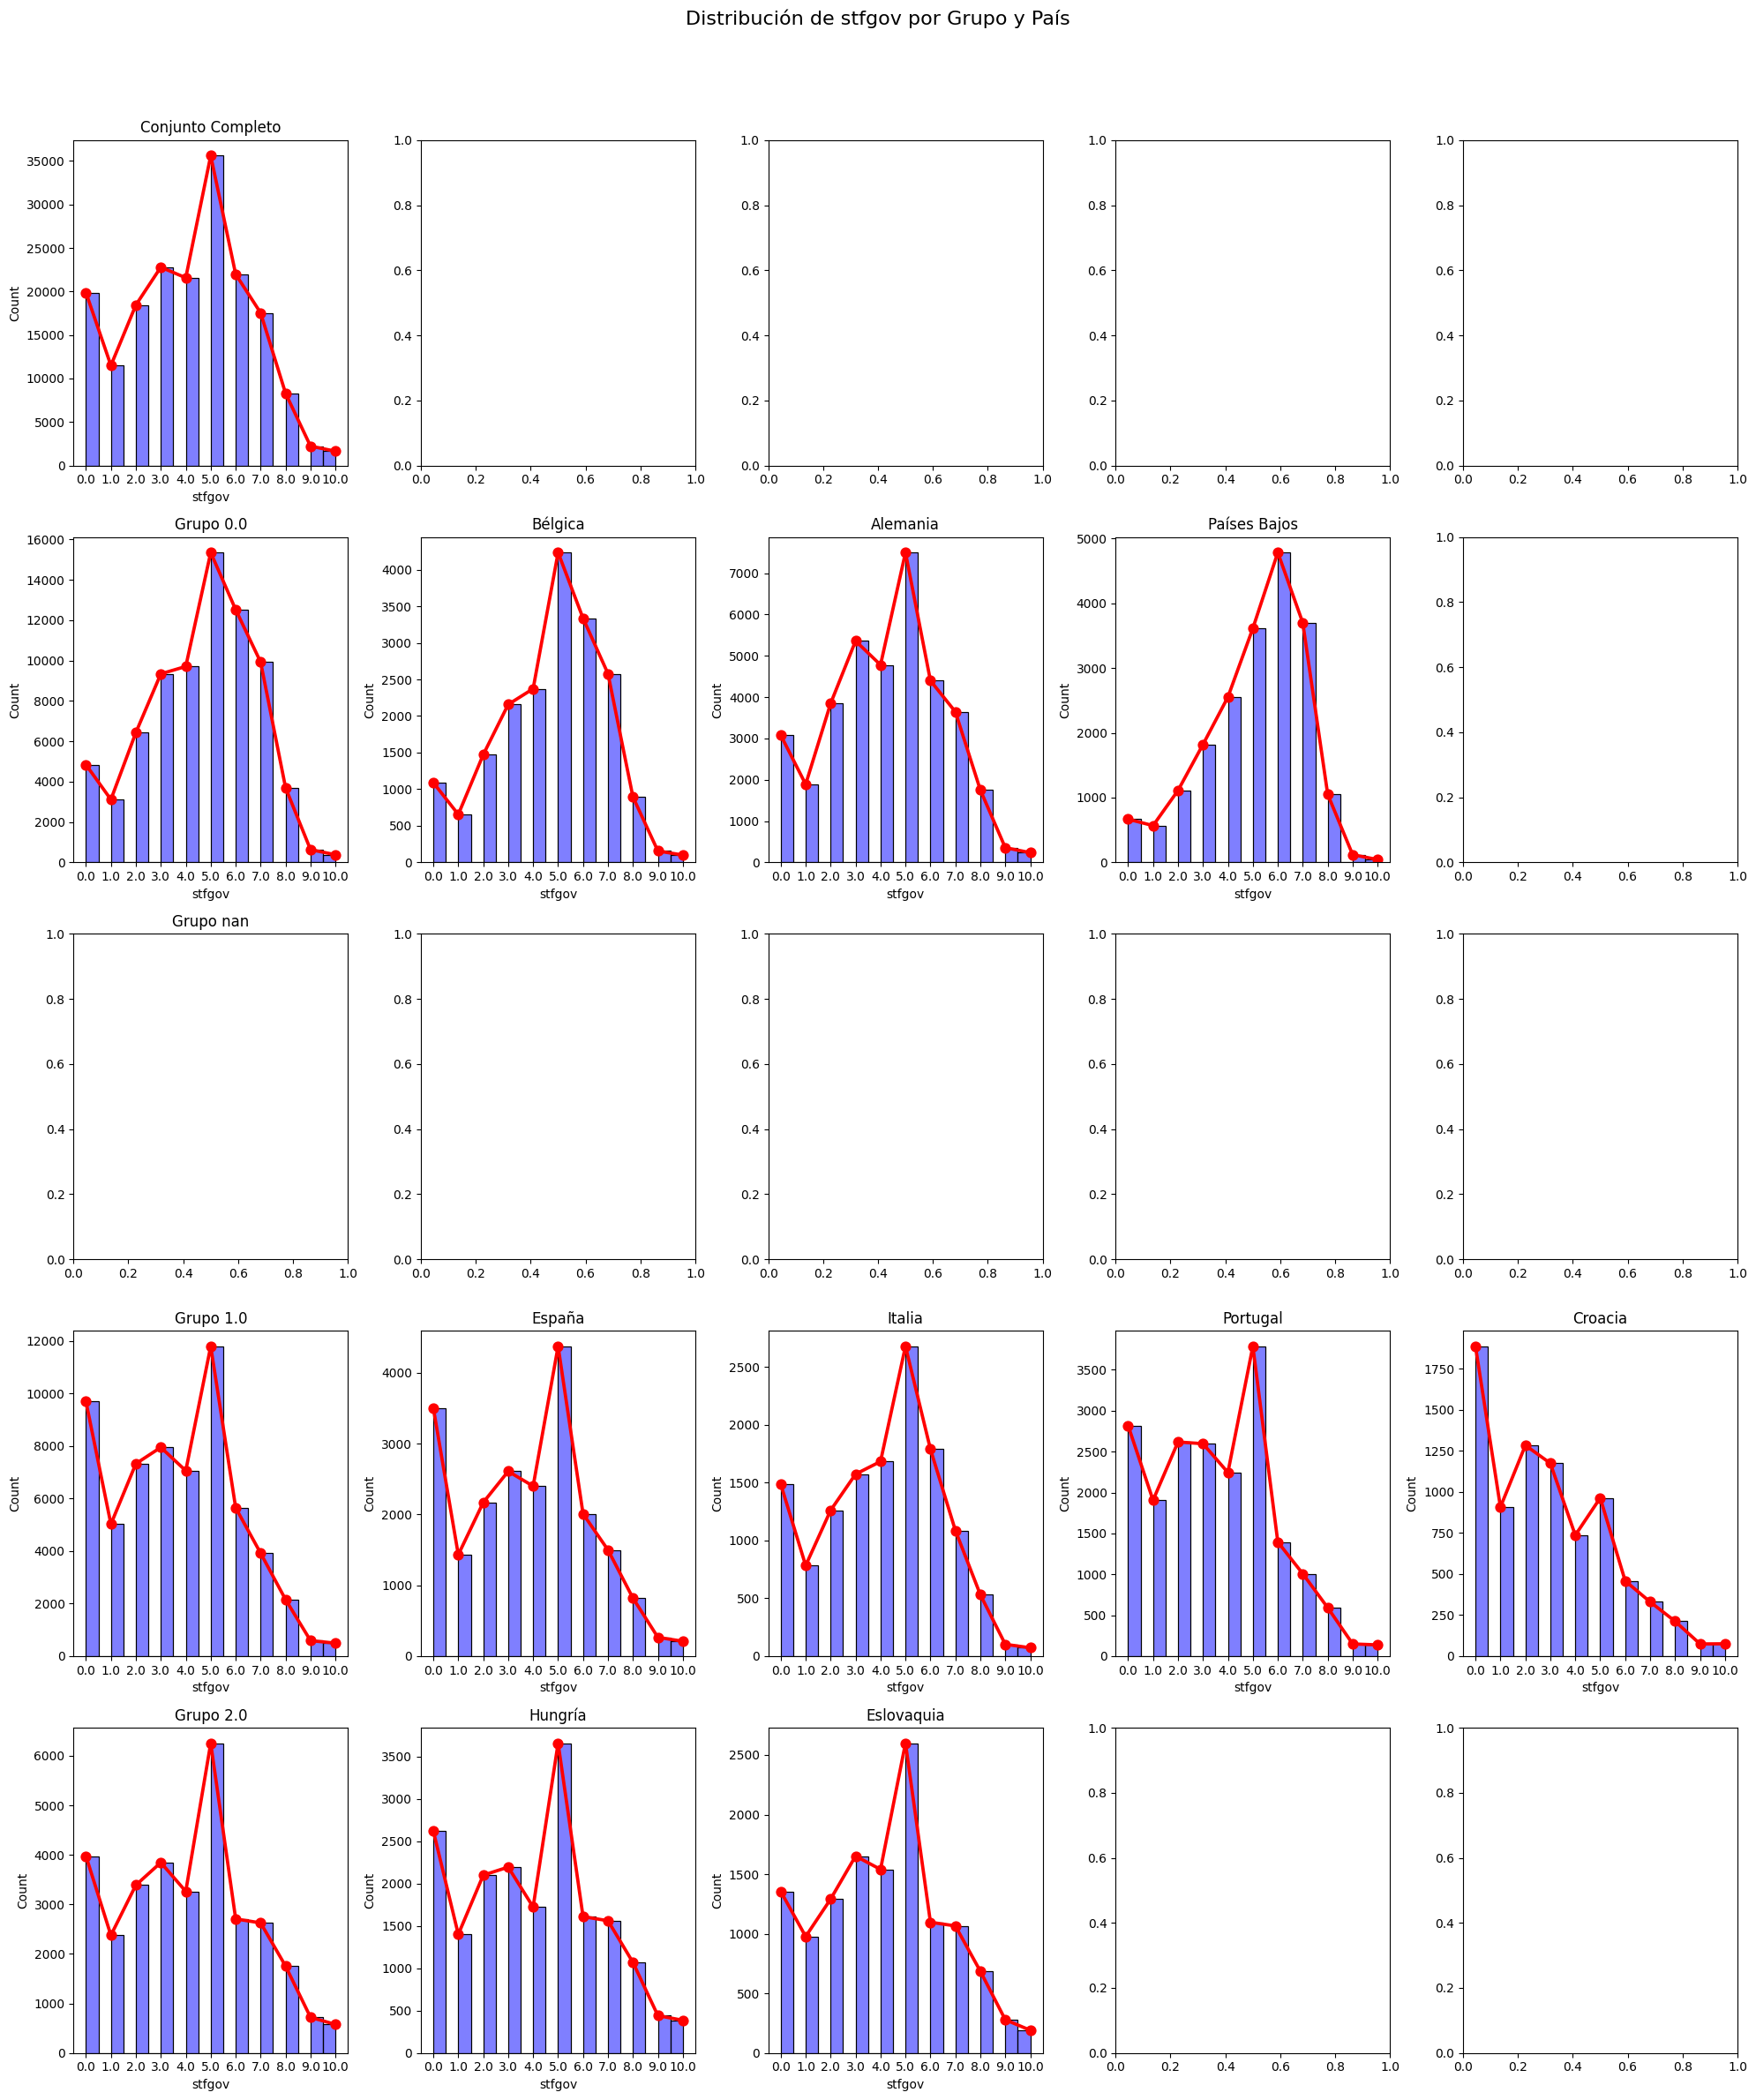

In [36]:
#Variable 'stfgov'
GroupDist(dfeu, 'stfgov')

In [37]:
statsgroup(dfeu, 'stfgov')

Estadísticas para stfgov - Conjunto Completo:
count    181433.000000
mean          4.069701
std           2.400434
min           0.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          10.000000
Name: stfgov, dtype: float64
Moda: 5.0, Frecuencia: 35610
Varianza: 5.762084778004381


Estadísticas para stfgov - Grupo 0.0:
count    75914.000000
mean         4.519930
std          2.186996
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: stfgov, dtype: float64
Moda: 5.0, Frecuencia: 15350
Varianza: 4.782953449774918


Estadísticas para stfgov - País Bélgica (Grupo 0.0):
count    19045.000000
mean         4.638855
std          2.126784
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: stfgov, dtype: float64
Moda: 5.0, Frecuencia: 4235
Varianza: 4.523211880196854


Estadísticas para stfgov - País Alemania (Grupo 0.0):
count    3

8-'stfgov': Escala de 0 a 10, 0 siendo muy insatisfecho con el desempeño del gobierno, a 10 estando satisfecho.
Variable discontinua que a conjunto global de muestras describe una funcion/distribucion normal simetrica.
Se aprecia que en el Grupo1(Media UE), y Grupo 2(Paises pobres) la distribucion se bimodaliza en los dos primeras secciones cuartilicas, restando muestras a las clases que sobrepasan el valor medio del rango de la variable.
Por lo General Cada subconjunto de paises se asemeja a las muestras de cada pais del grupo.


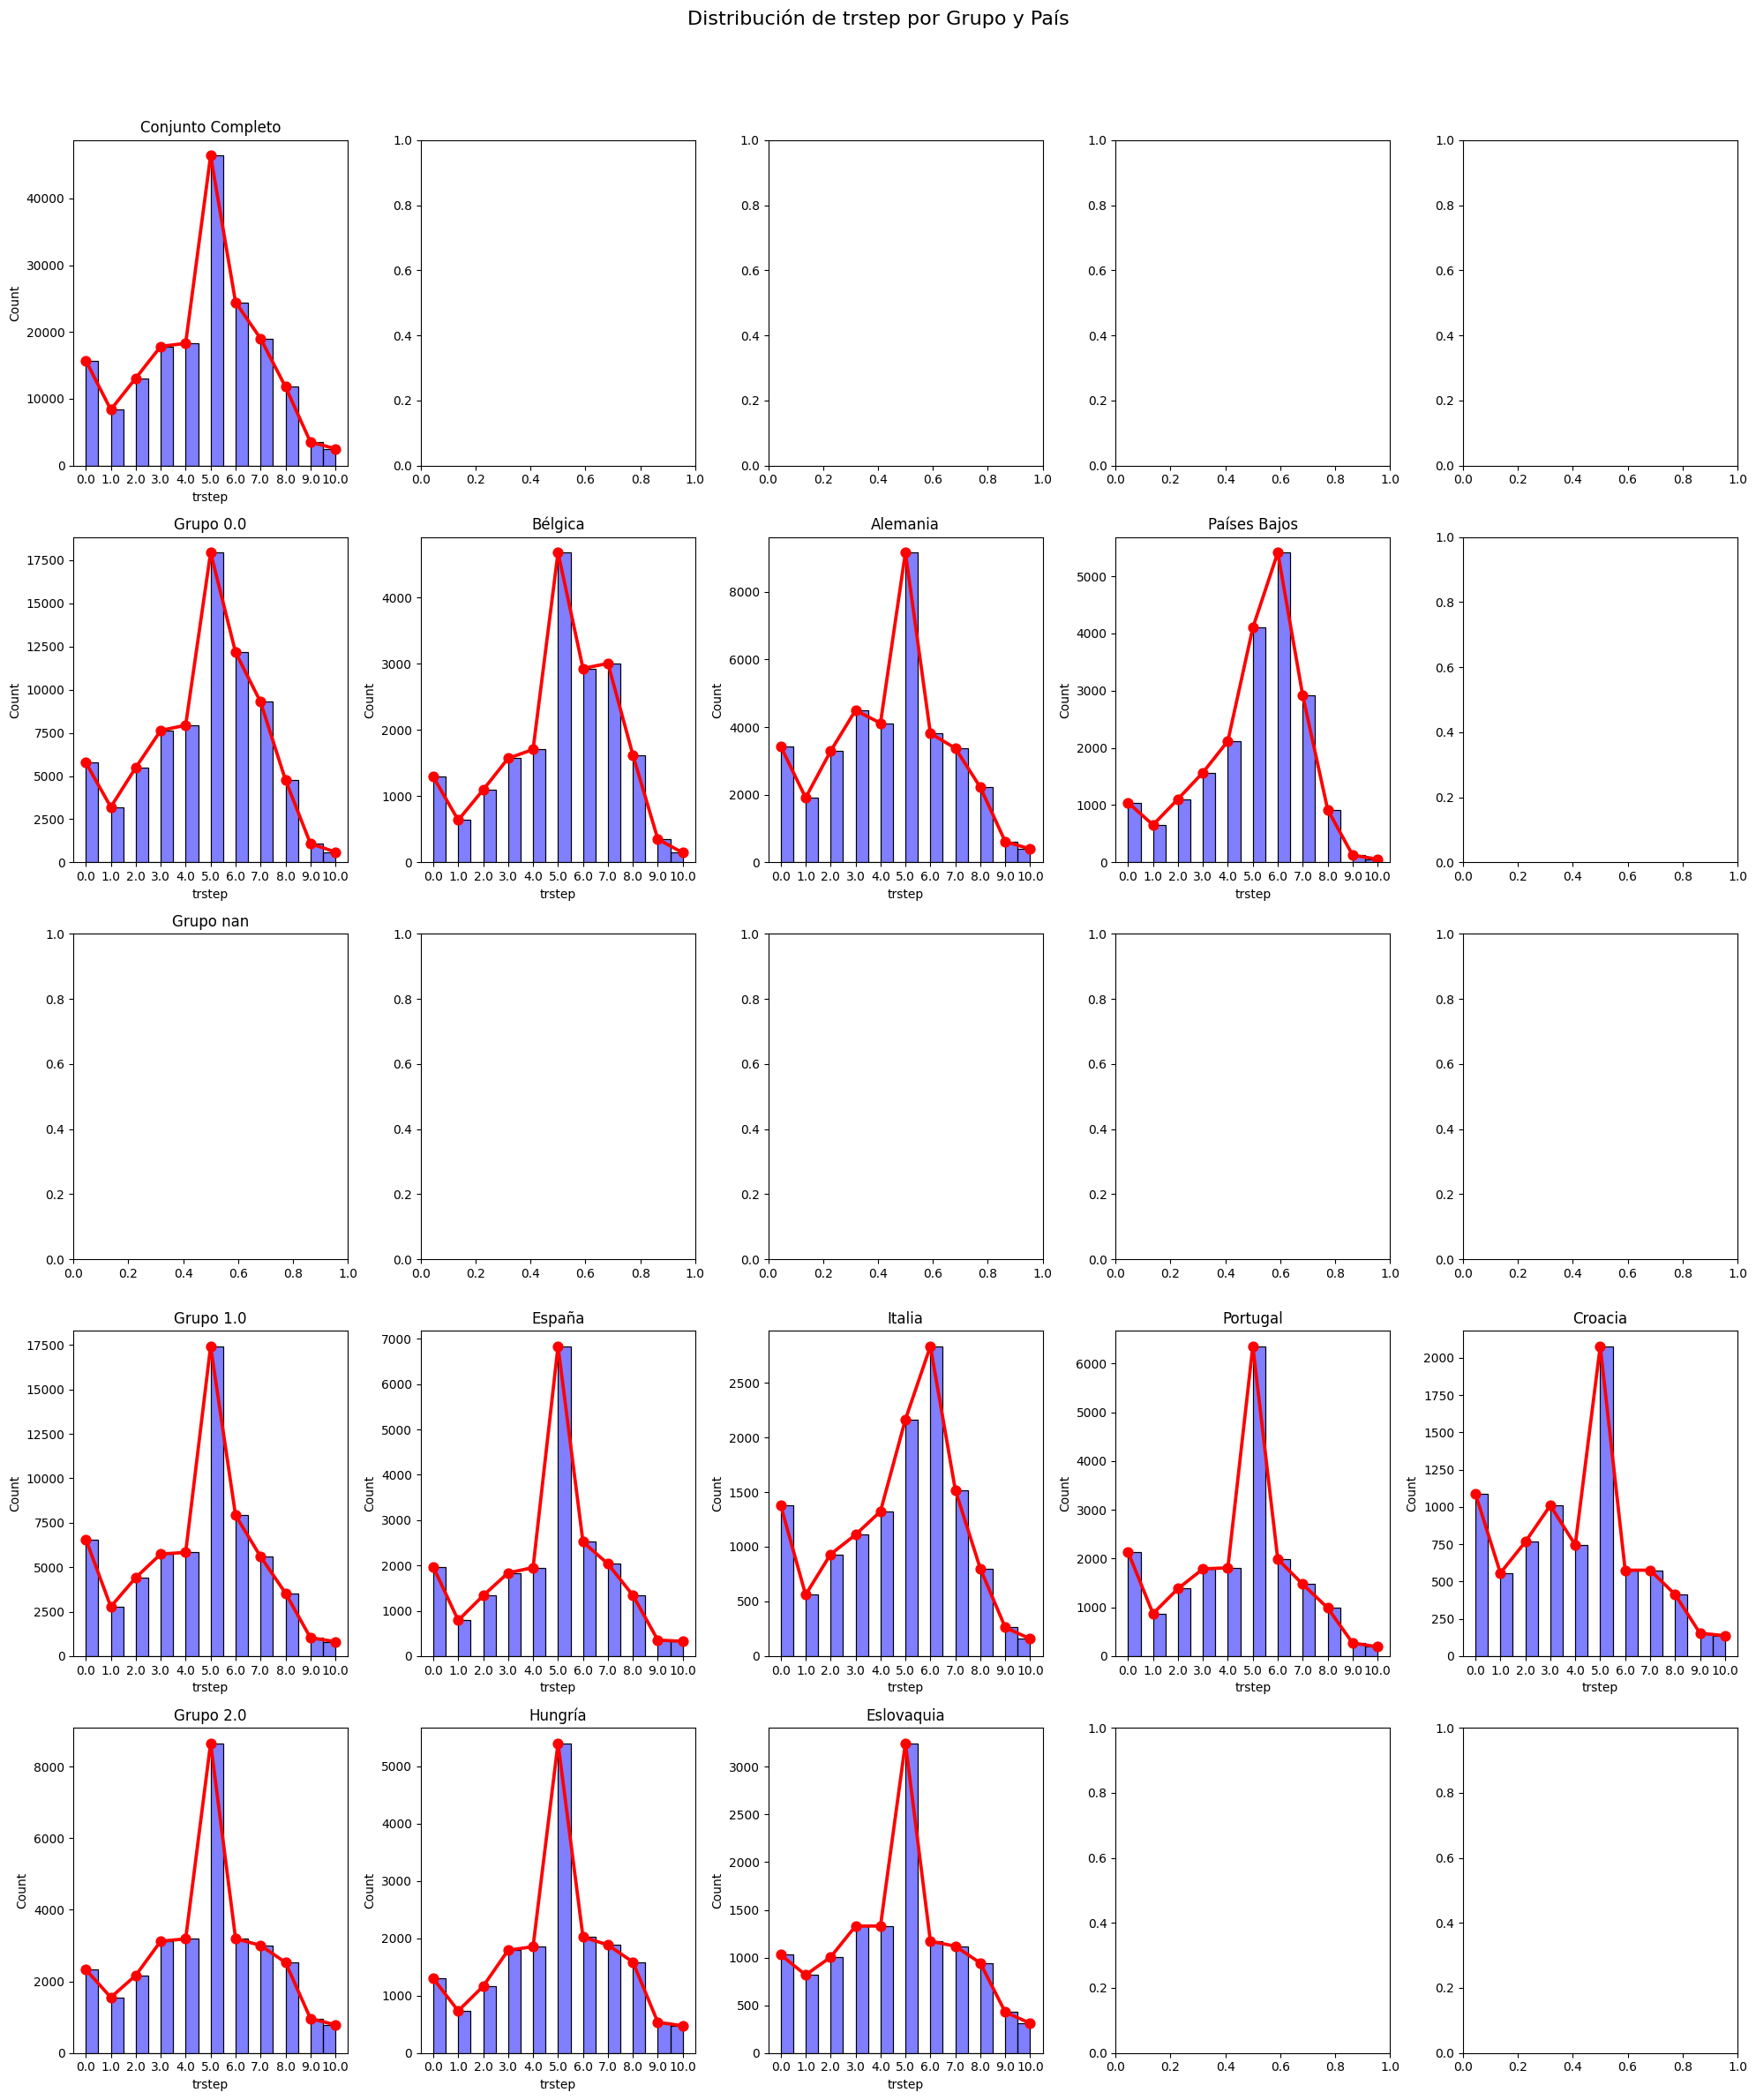

In [38]:
#Variable 'trstep'
GroupDist(dfeu, 'trstep')

In [39]:
statsgroup(dfeu, 'trstep')

Estadísticas para trstep - Conjunto Completo:
count    180963.000000
mean          4.554135
std           2.377974
min           0.000000
25%           3.000000
50%           5.000000
75%           6.000000
max          10.000000
Name: trstep, dtype: float64
Moda: 5.0, Frecuencia: 46411
Varianza: 5.6547585282632


Estadísticas para trstep - Grupo 0.0:
count    75914.000000
mean         4.618384
std          2.287126
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: trstep, dtype: float64
Moda: 5.0, Frecuencia: 17949
Varianza: 5.2309430972865085


Estadísticas para trstep - País Bélgica (Grupo 0.0):
count    19045.000000
mean         4.936309
std          2.281329
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: trstep, dtype: float64
Moda: 5.0, Frecuencia: 4683
Varianza: 5.204460328953706


Estadísticas para trstep - País Alemania (Grupo 0.0):
count    36

9-'trstep': Escala de 0 a 10, grado de confianza con el parlamento Europeo, 0 siendo inexistente.

Variable discontinua que dibuja una funcion/distribucion normal simetrica, donde la mayor cantidad de muestras se agrupan en el valor medio del rango de la variable.
Por lo general todas las distribuciones de paises y subgrupos tienen un formato muy similar con la variable con el conjunto total de muestras.
Si que es verdad que aumentan levemente las muestras en porcentaje alrededor del valor medio del rango de la variable  conforme los paises son mas pobres pero por lo demas, apenas varia.

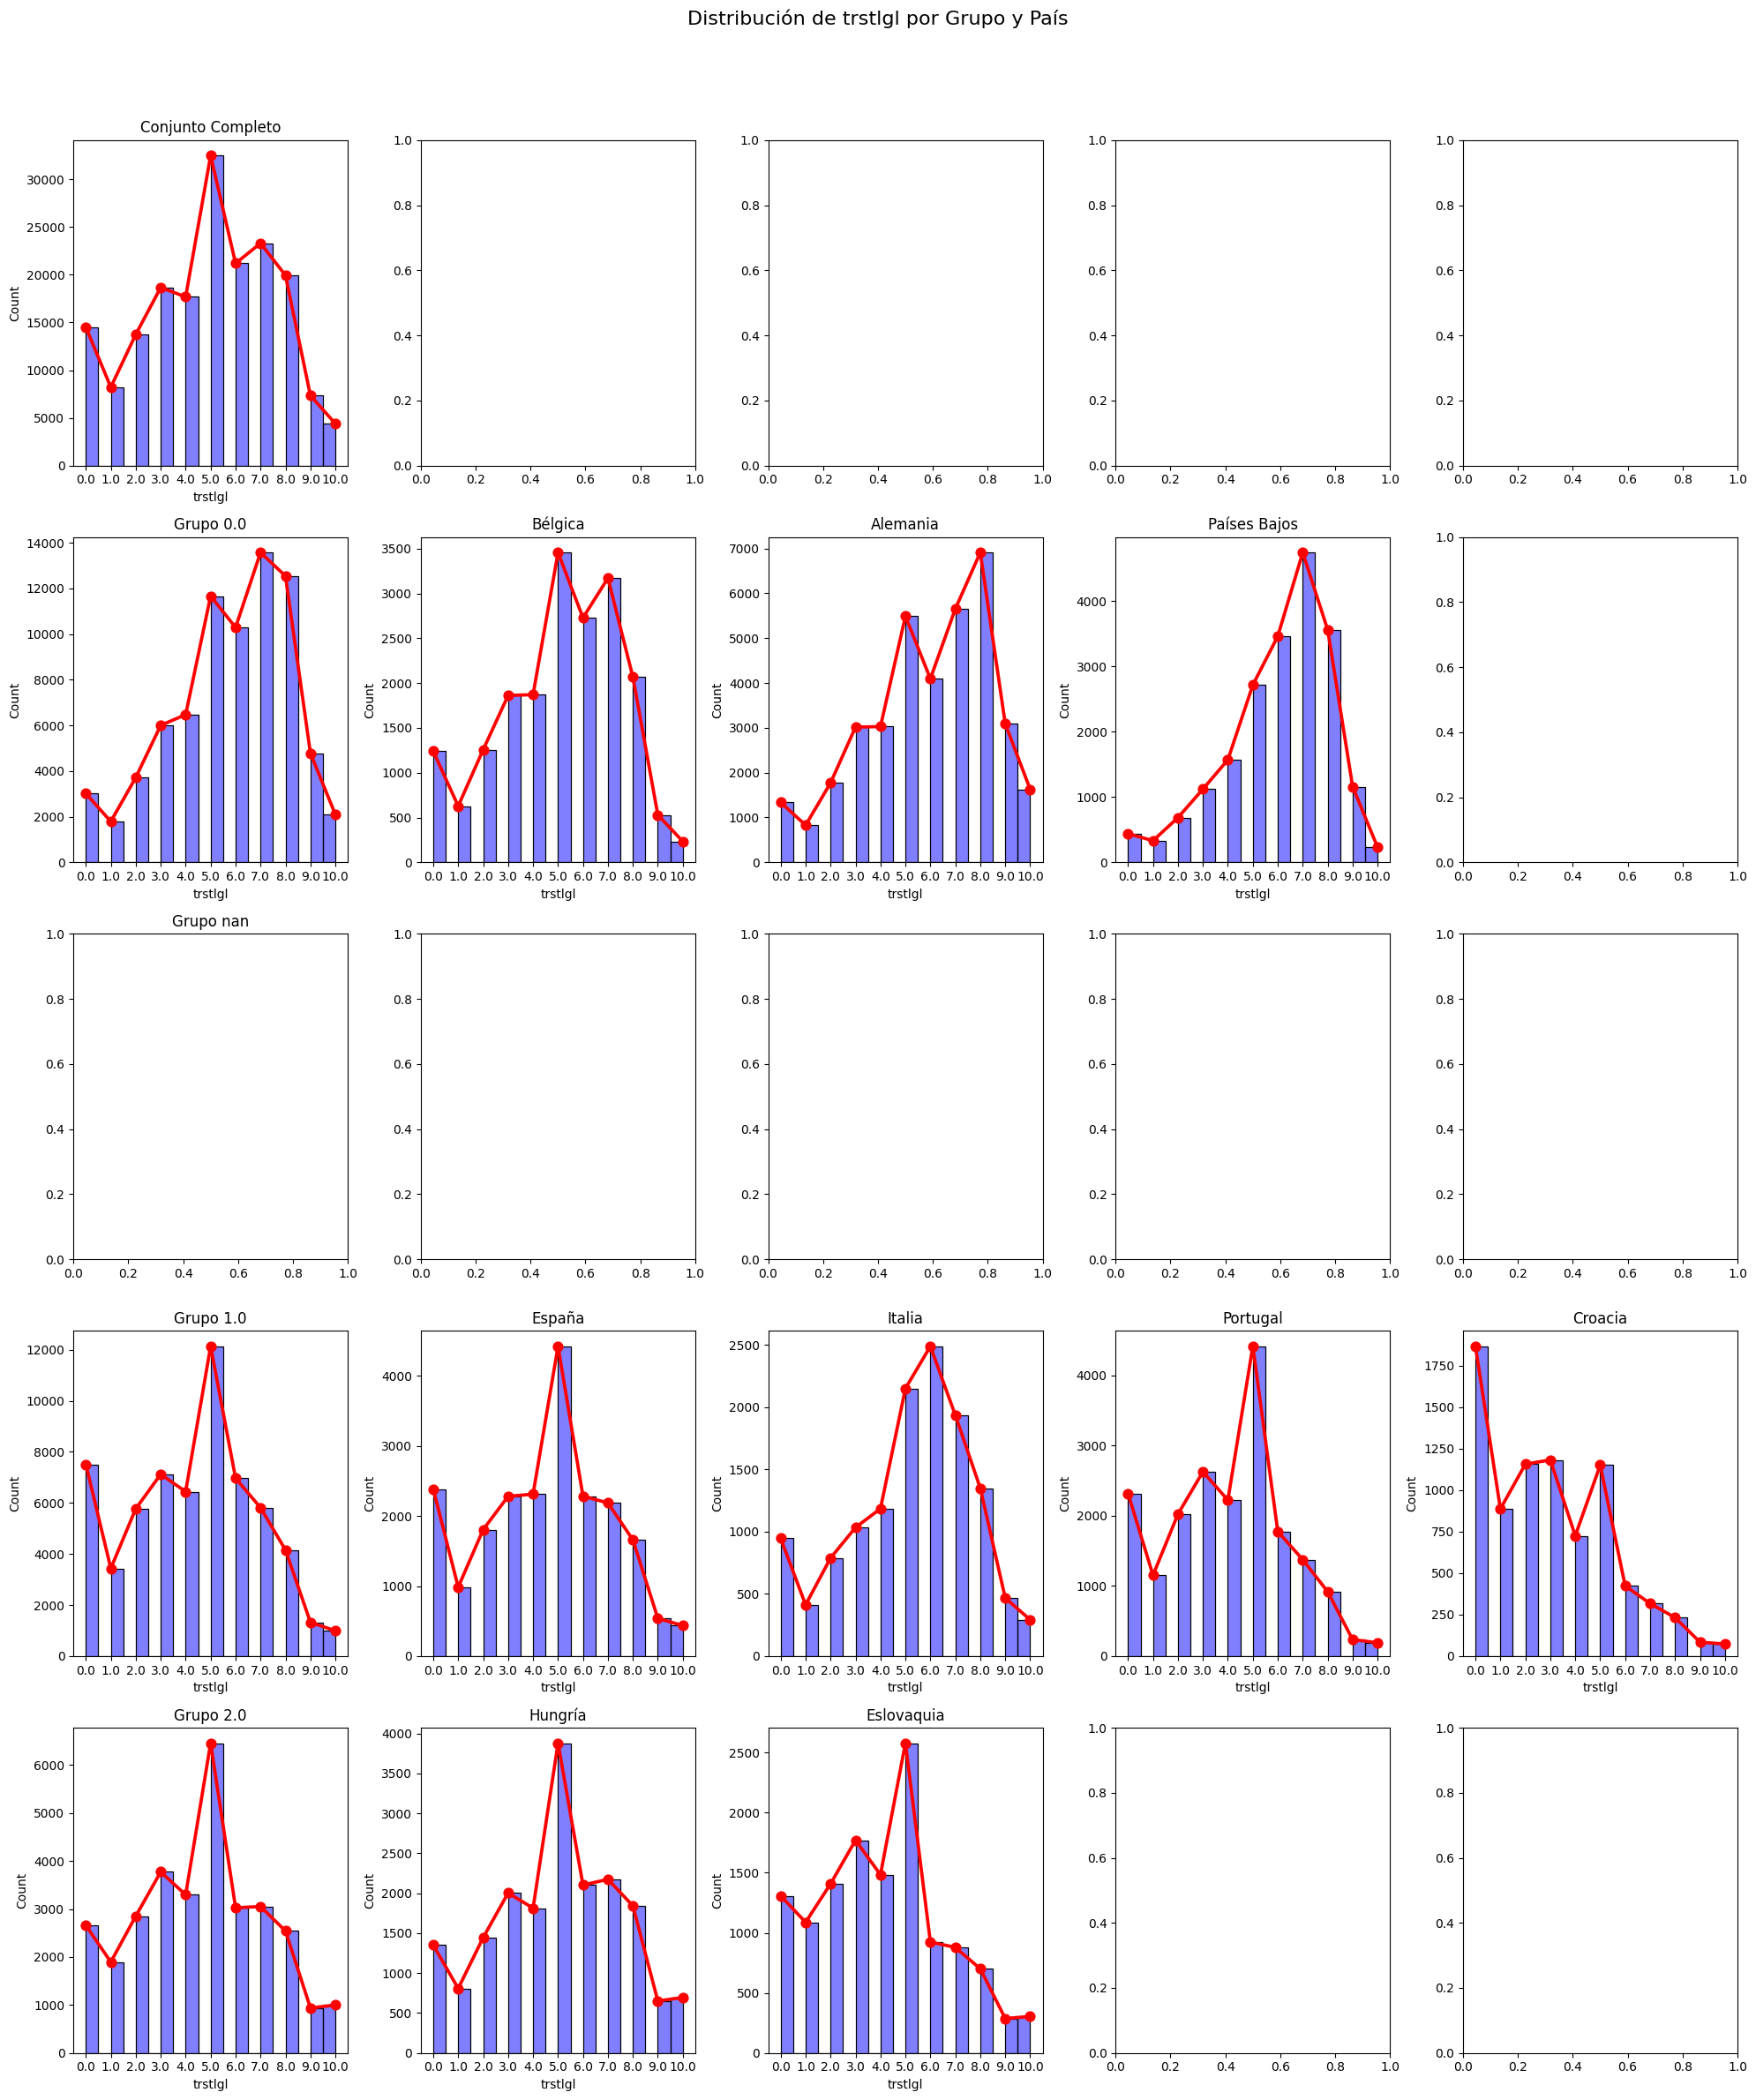

In [40]:
#Variable 'trstlgl'
GroupDist(dfeu, 'trstlgl')

In [41]:
statsgroup(dfeu, 'trstlgl')

Estadísticas para trstlgl - Conjunto Completo:
count    181503.000000
mean          4.875016
std           2.601038
min           0.000000
25%           3.000000
50%           5.000000
75%           7.000000
max          10.000000
Name: trstlgl, dtype: float64
Moda: 5.0, Frecuencia: 32506
Varianza: 6.765400570403962


Estadísticas para trstlgl - Grupo 0.0:
count    75914.000000
mean         5.695260
std          2.400278
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         10.000000
Name: trstlgl, dtype: float64
Moda: 7.0, Frecuencia: 13569
Varianza: 5.761334089041042


Estadísticas para trstlgl - País Bélgica (Grupo 0.0):
count    19045.000000
mean         5.025624
std          2.403149
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: trstlgl, dtype: float64
Moda: 5.0, Frecuencia: 3457
Varianza: 5.775125799236588


Estadísticas para trstlgl - País Alemania (Grupo 0.0):
cou

10-'trstlgl': Escala de 0 a 10, grado de confianza con el sistema legal-judicial, 0 siendo inexistente.
Variable discontinua que describe con todas las muestras una distribución normal trimodal, predominando en el % de muestras todas aquellas cercanas al valor medio del rango de la variable.
Hay que hacer especial mencion al conjunto de muestras del pais Croaci que por cuestiones históricas y culturales
Hay mucho porcentaje de muestras ubicados en el valor 0 del rango de la variable, provocando una asimetrica negativa respecto a la media del valor de la variable.
La tendencia de la distribucion es trimodalizarse con simetria conforme los grupos de paises son economicamente mas pobres.
En el grupo 0(ricos), el mayor porcentaje de muestras esta desplazado a la derecha respecto al valor medio del rango de la variable.


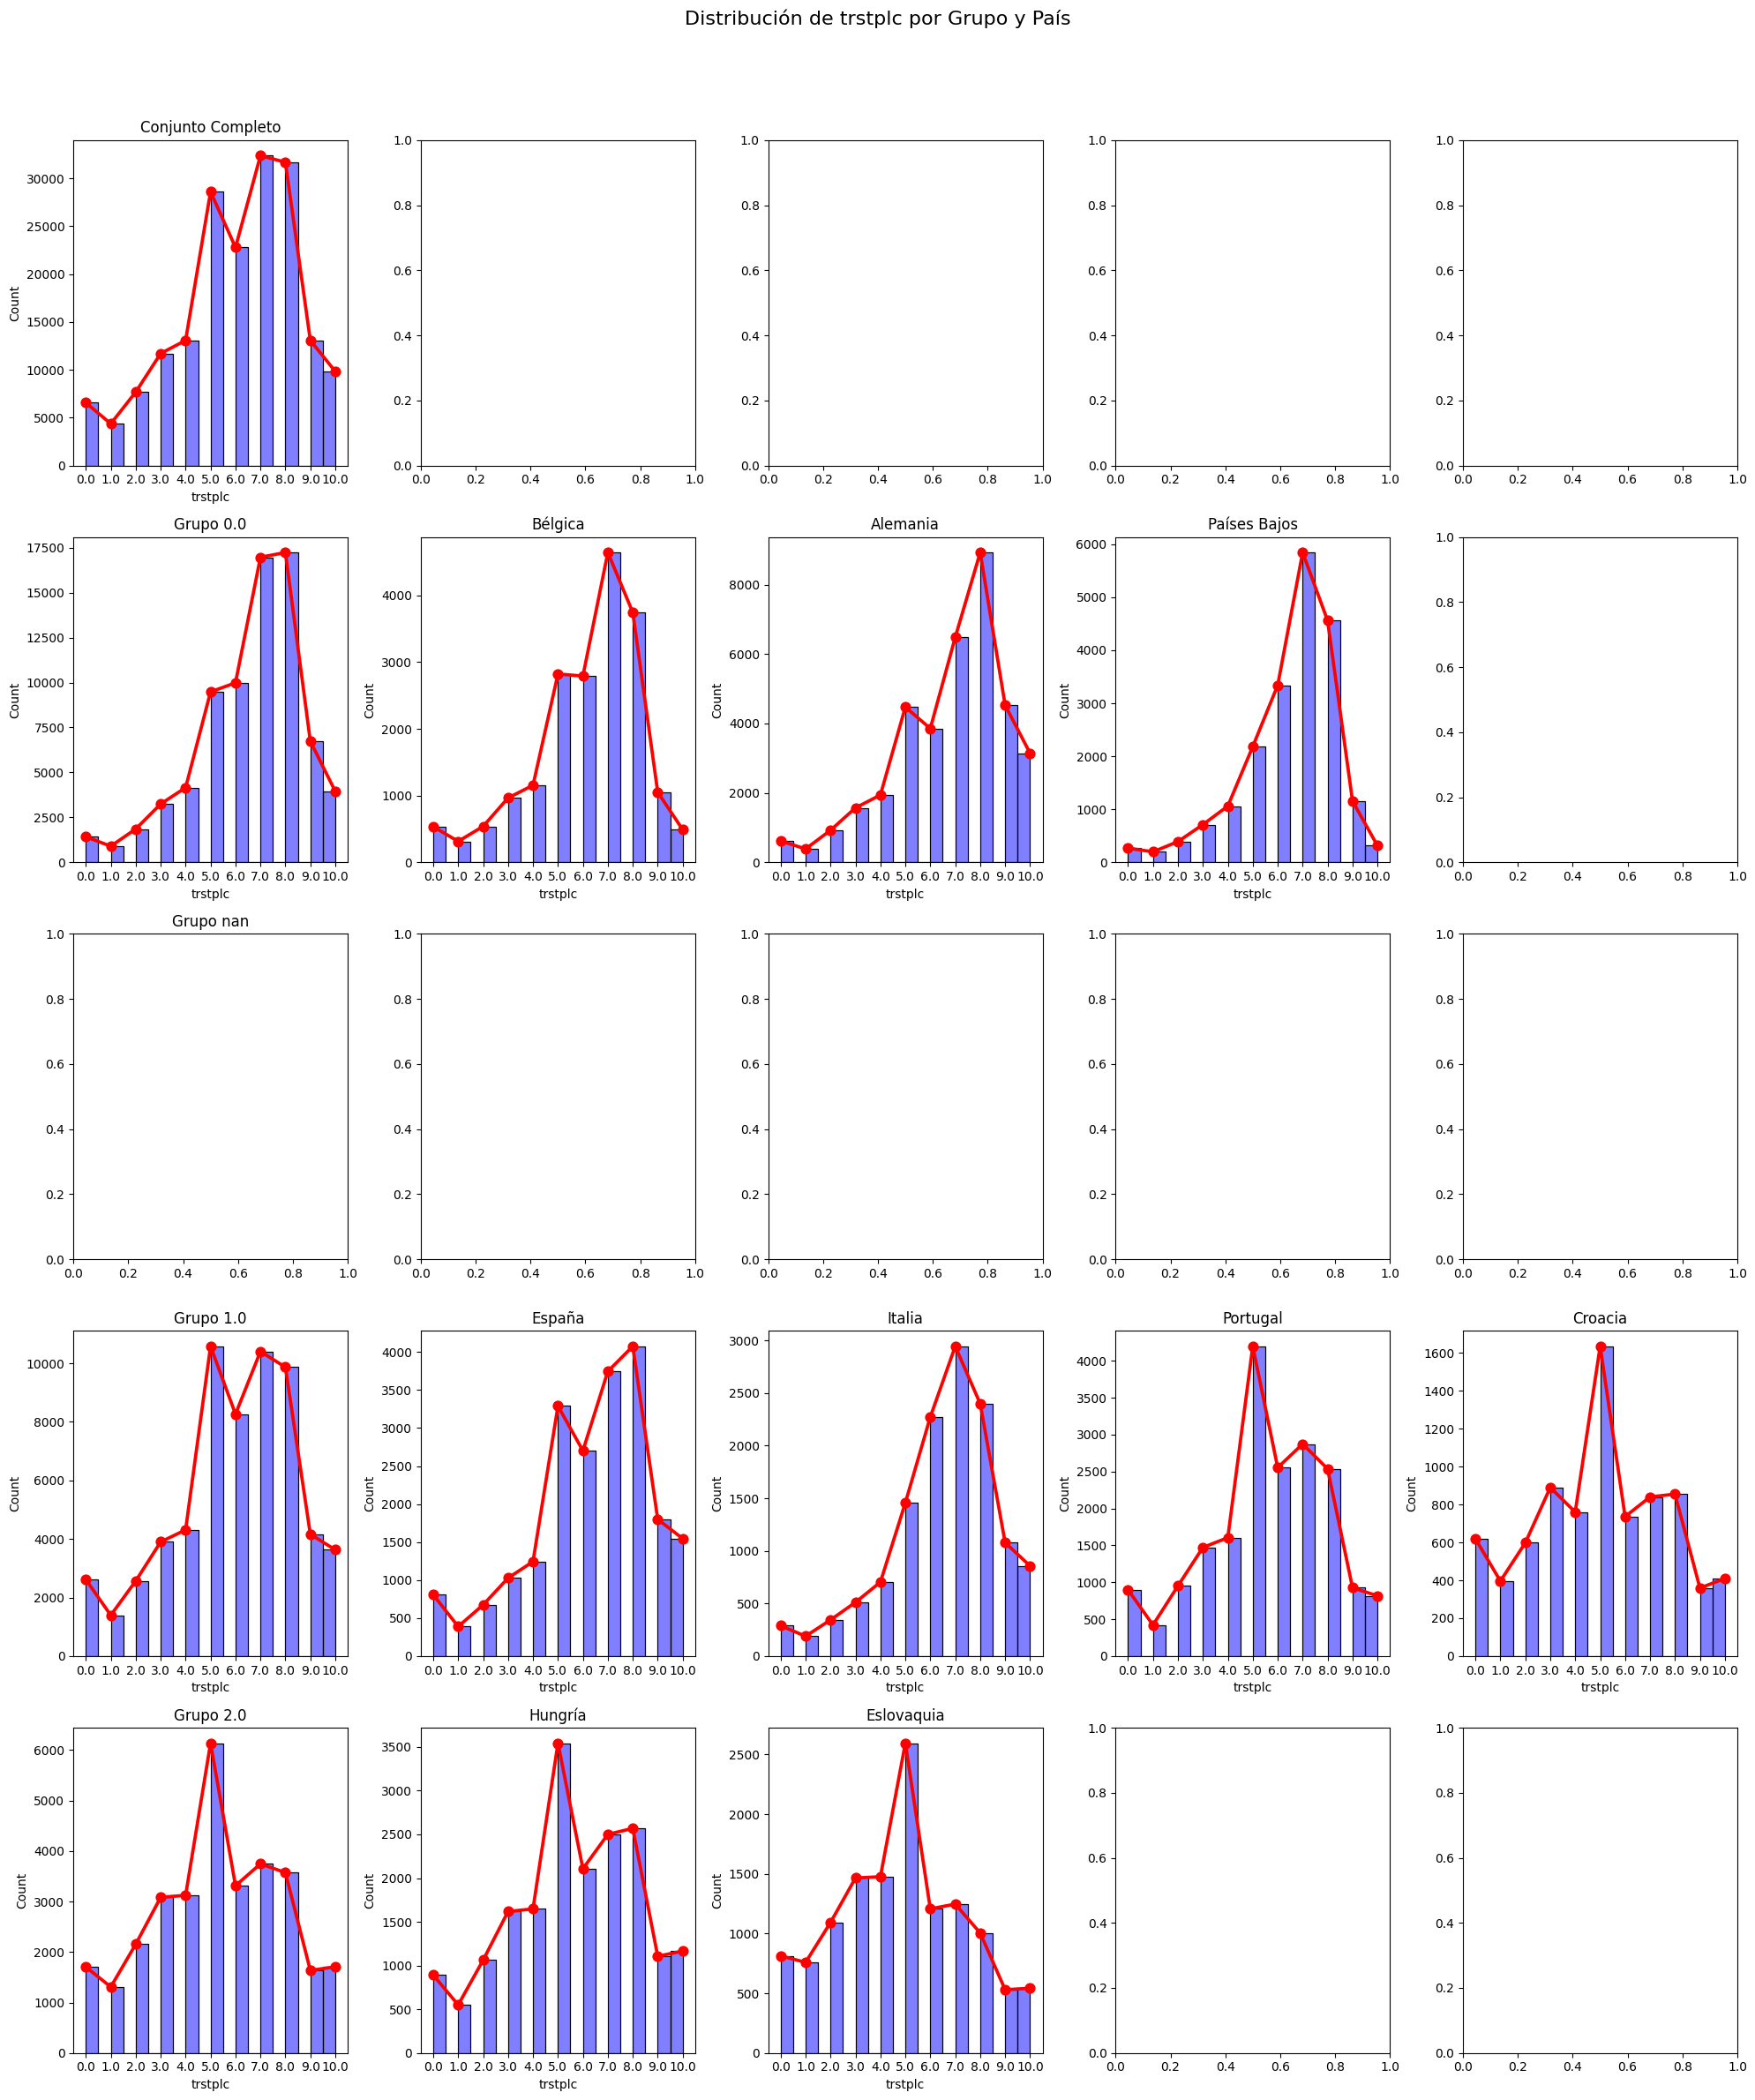

In [42]:
#Var 'trstplc'
GroupDist(dfeu, 'trstplc')

In [43]:
statsgroup(dfeu, 'trstplc')

Estadísticas para trstplc - Conjunto Completo:
count    181638.000000
mean          5.959133
std           2.446685
min           0.000000
25%           5.000000
50%           6.000000
75%           8.000000
max          10.000000
Name: trstplc, dtype: float64
Moda: 7.0, Frecuencia: 32364
Varianza: 5.98626735888044


Estadísticas para trstplc - Grupo 0.0:
count    75914.000000
mean         6.519654
std          2.140172
min          0.000000
25%          5.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: trstplc, dtype: float64
Moda: 8.0, Frecuencia: 17229
Varianza: 4.580337708987366


Estadísticas para trstplc - País Bélgica (Grupo 0.0):
count    19045.000000
mean         6.119769
std          2.155719
min          0.000000
25%          5.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: trstplc, dtype: float64
Moda: 7.0, Frecuencia: 4641
Varianza: 4.647122819967455


Estadísticas para trstplc - País Alemania (Grupo 0.0):
coun

12-'trstplt': Escala de 0 a 10, grado de confianza con las personas polítcas, 0 siendo inexistente.
Variable discontinua que con su conjunto global de muestras describe describe una funcion/distribucion asimetrica bimodal positiva
(su mayor grueso de muestras esta desplazado positivamente respecto al valor medio del rango de la variable) Cada subconjunto de muestras imprime una distribucion distinta si vamos en sentido descendente del grupo de paises, la distribucion simetrizarse desplazandose el mayor grueso de muestras al valor medio del rango de la variable tambien se aprecia la bimodalizacion de las muestras. Debido al desbalance de meustras respecto el grupo 0 a los otros dos grupos , la distribucion general permanece algo desplazada a la derecha respecto aun eje de simetria del rango de la variable.

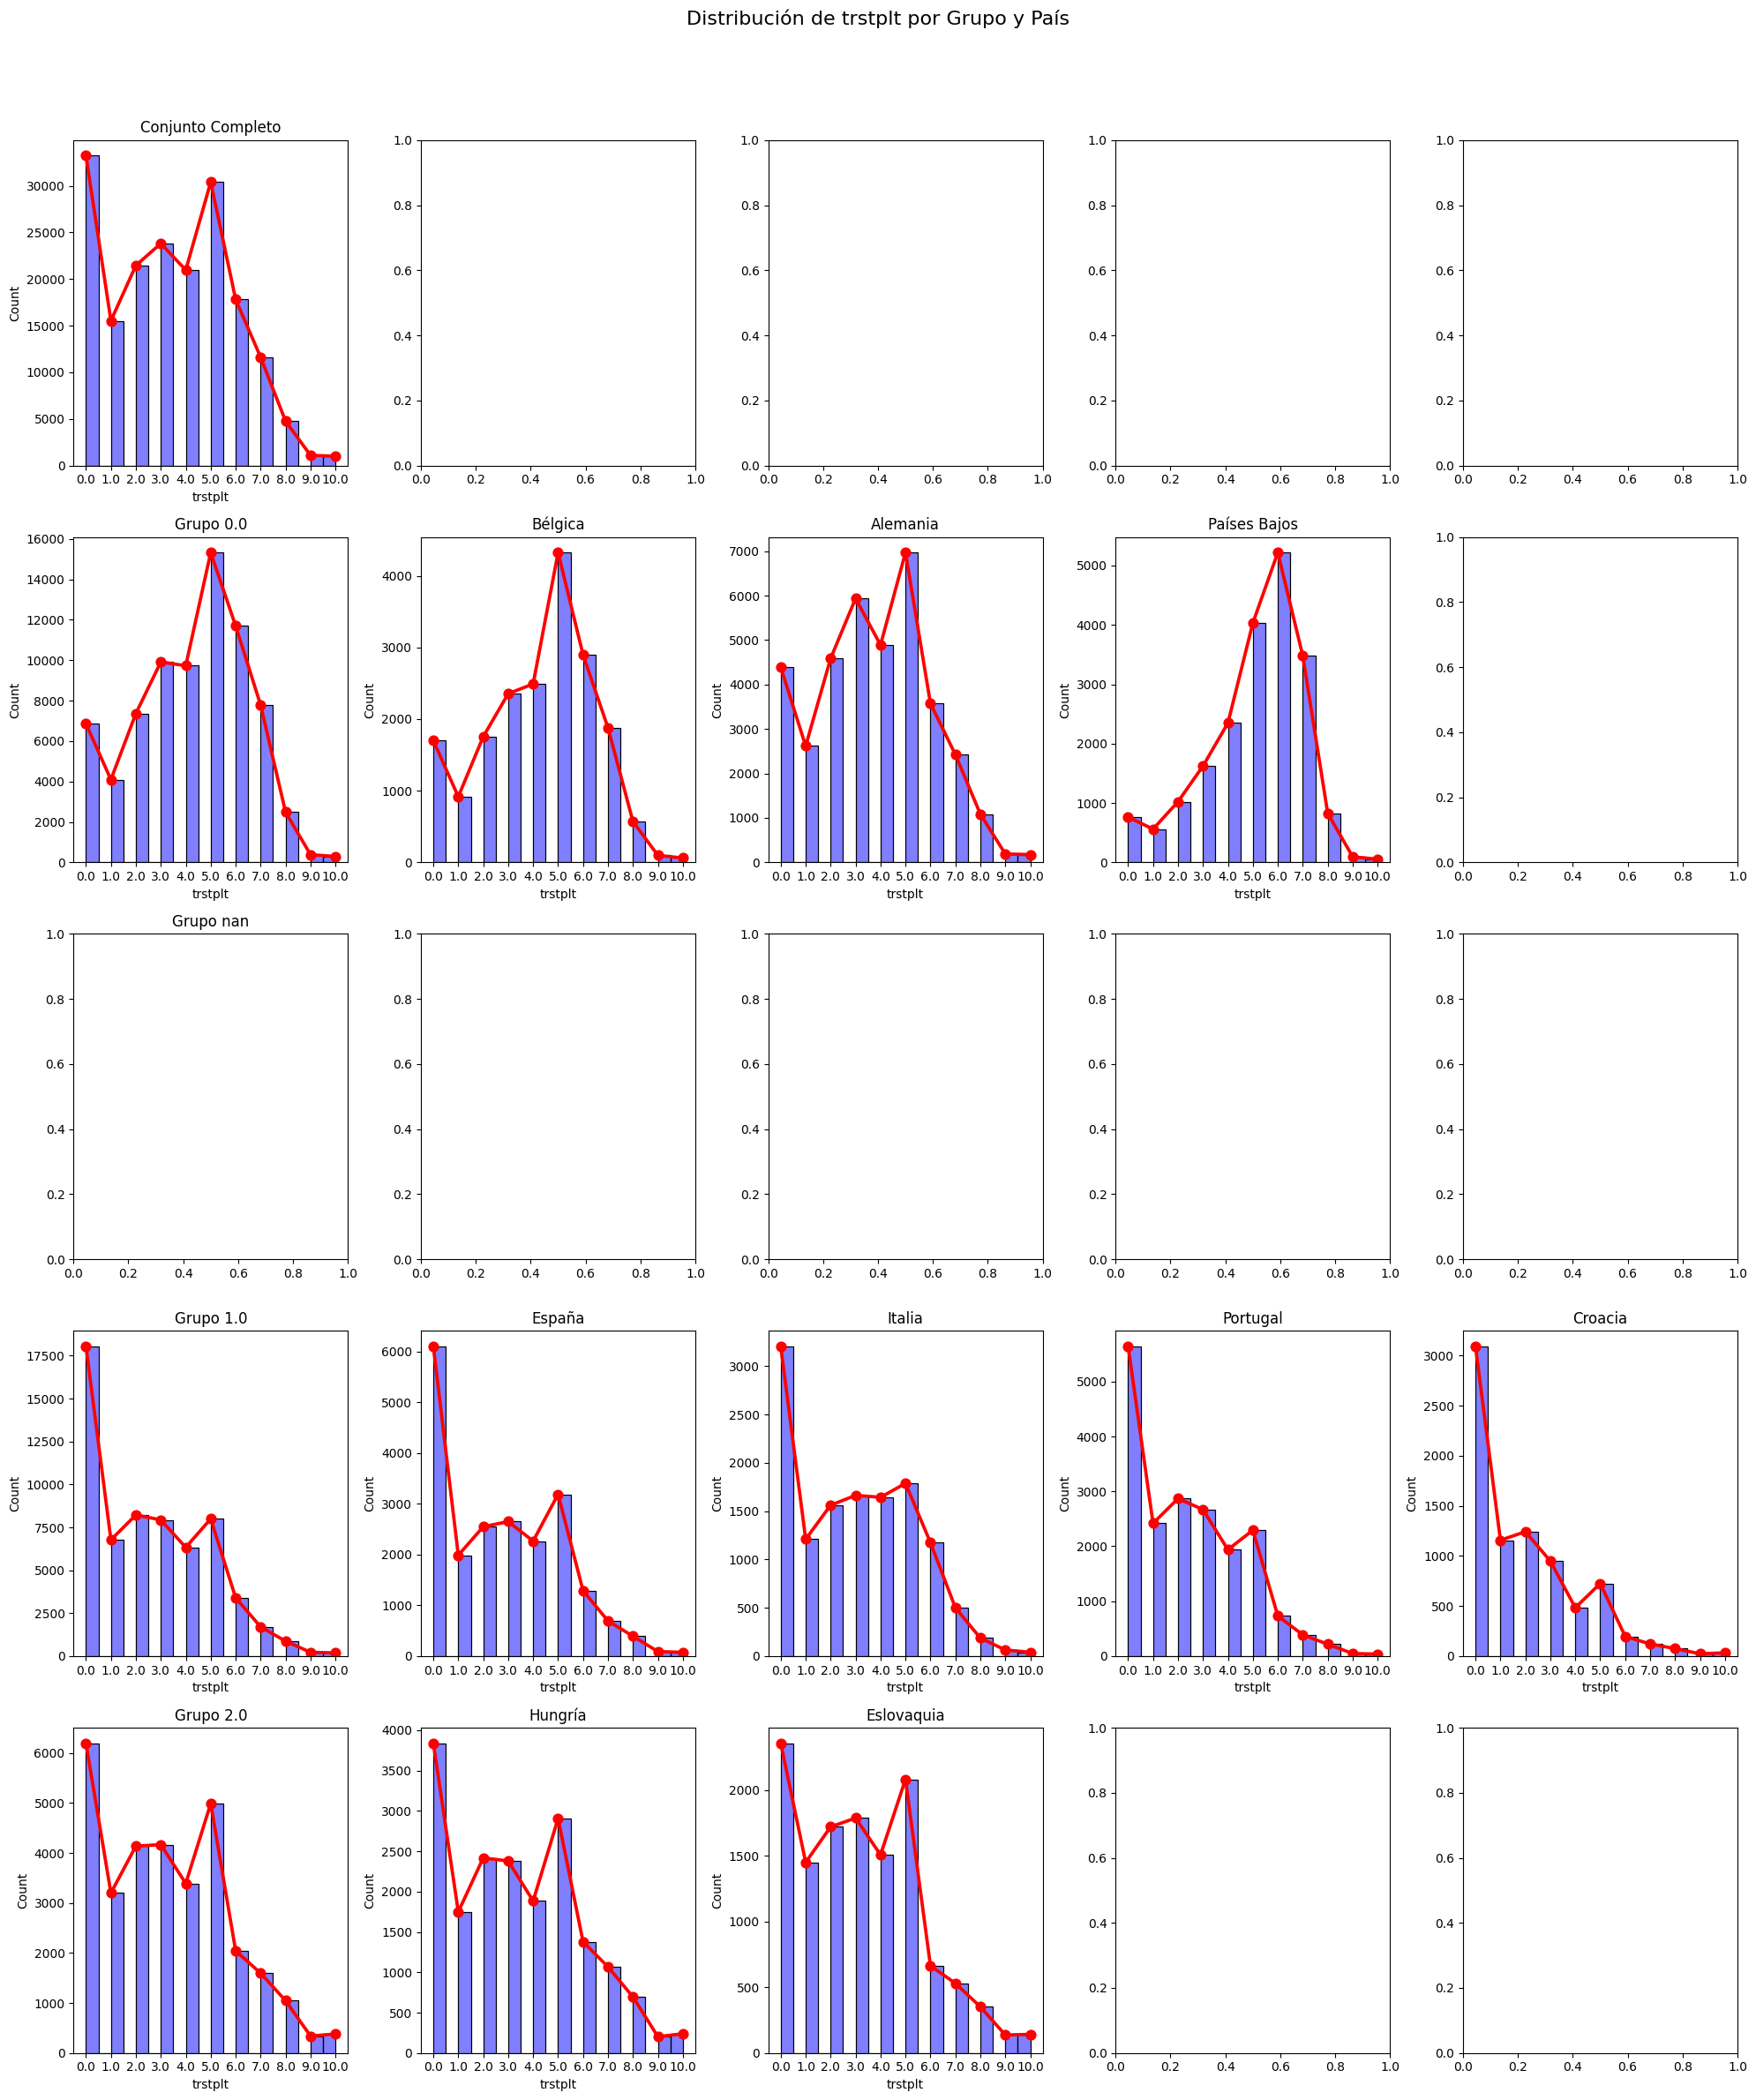

In [44]:
#Variable 'trstplt'
GroupDist(dfeu, 'trstplt')

In [45]:
statsgroup(dfeu, 'trstplt')

Estadísticas para trstplt - Conjunto Completo:
count    181598.000000
mean          3.367185
std           2.408373
min           0.000000
25%           1.000000
50%           3.000000
75%           5.000000
max          10.000000
Name: trstplt, dtype: float64
Moda: 0.0, Frecuencia: 33228
Varianza: 5.80026171594019


Estadísticas para trstplt - Grupo 0.0:
count    75914.000000
mean         4.148787
std          2.225769
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: trstplt, dtype: float64
Moda: 5.0, Frecuencia: 15328
Varianza: 4.954045463397611


Estadísticas para trstplt - País Bélgica (Grupo 0.0):
count    19045.000000
mean         4.182410
std          2.182884
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: trstplt, dtype: float64
Moda: 5.0, Frecuencia: 4325
Varianza: 4.7649814837883


Estadísticas para trstplt - País Alemania (Grupo 0.0):
count 

12-'trstplt': Escala de 0 a 10, grado de confianza con las personas polítcas, 0 siendo inexistente.

Variable discontinua que en conjunto global describe una funcion asimetrica bimodal, donde el gran grueso de las muestras estan en el primer y segundo cuartílico.
Se aprecia claramente que los grupos 1 y 2 de paises son los que afectan en la distribucion, acercando el conjunto global de las muestras al valor mas cercano a 0 del rango de la variable.
El primer grupo en cambio, sin entrar en criterios de significado dibujan una funcion simetrica respecto al rango del valor de la variable.

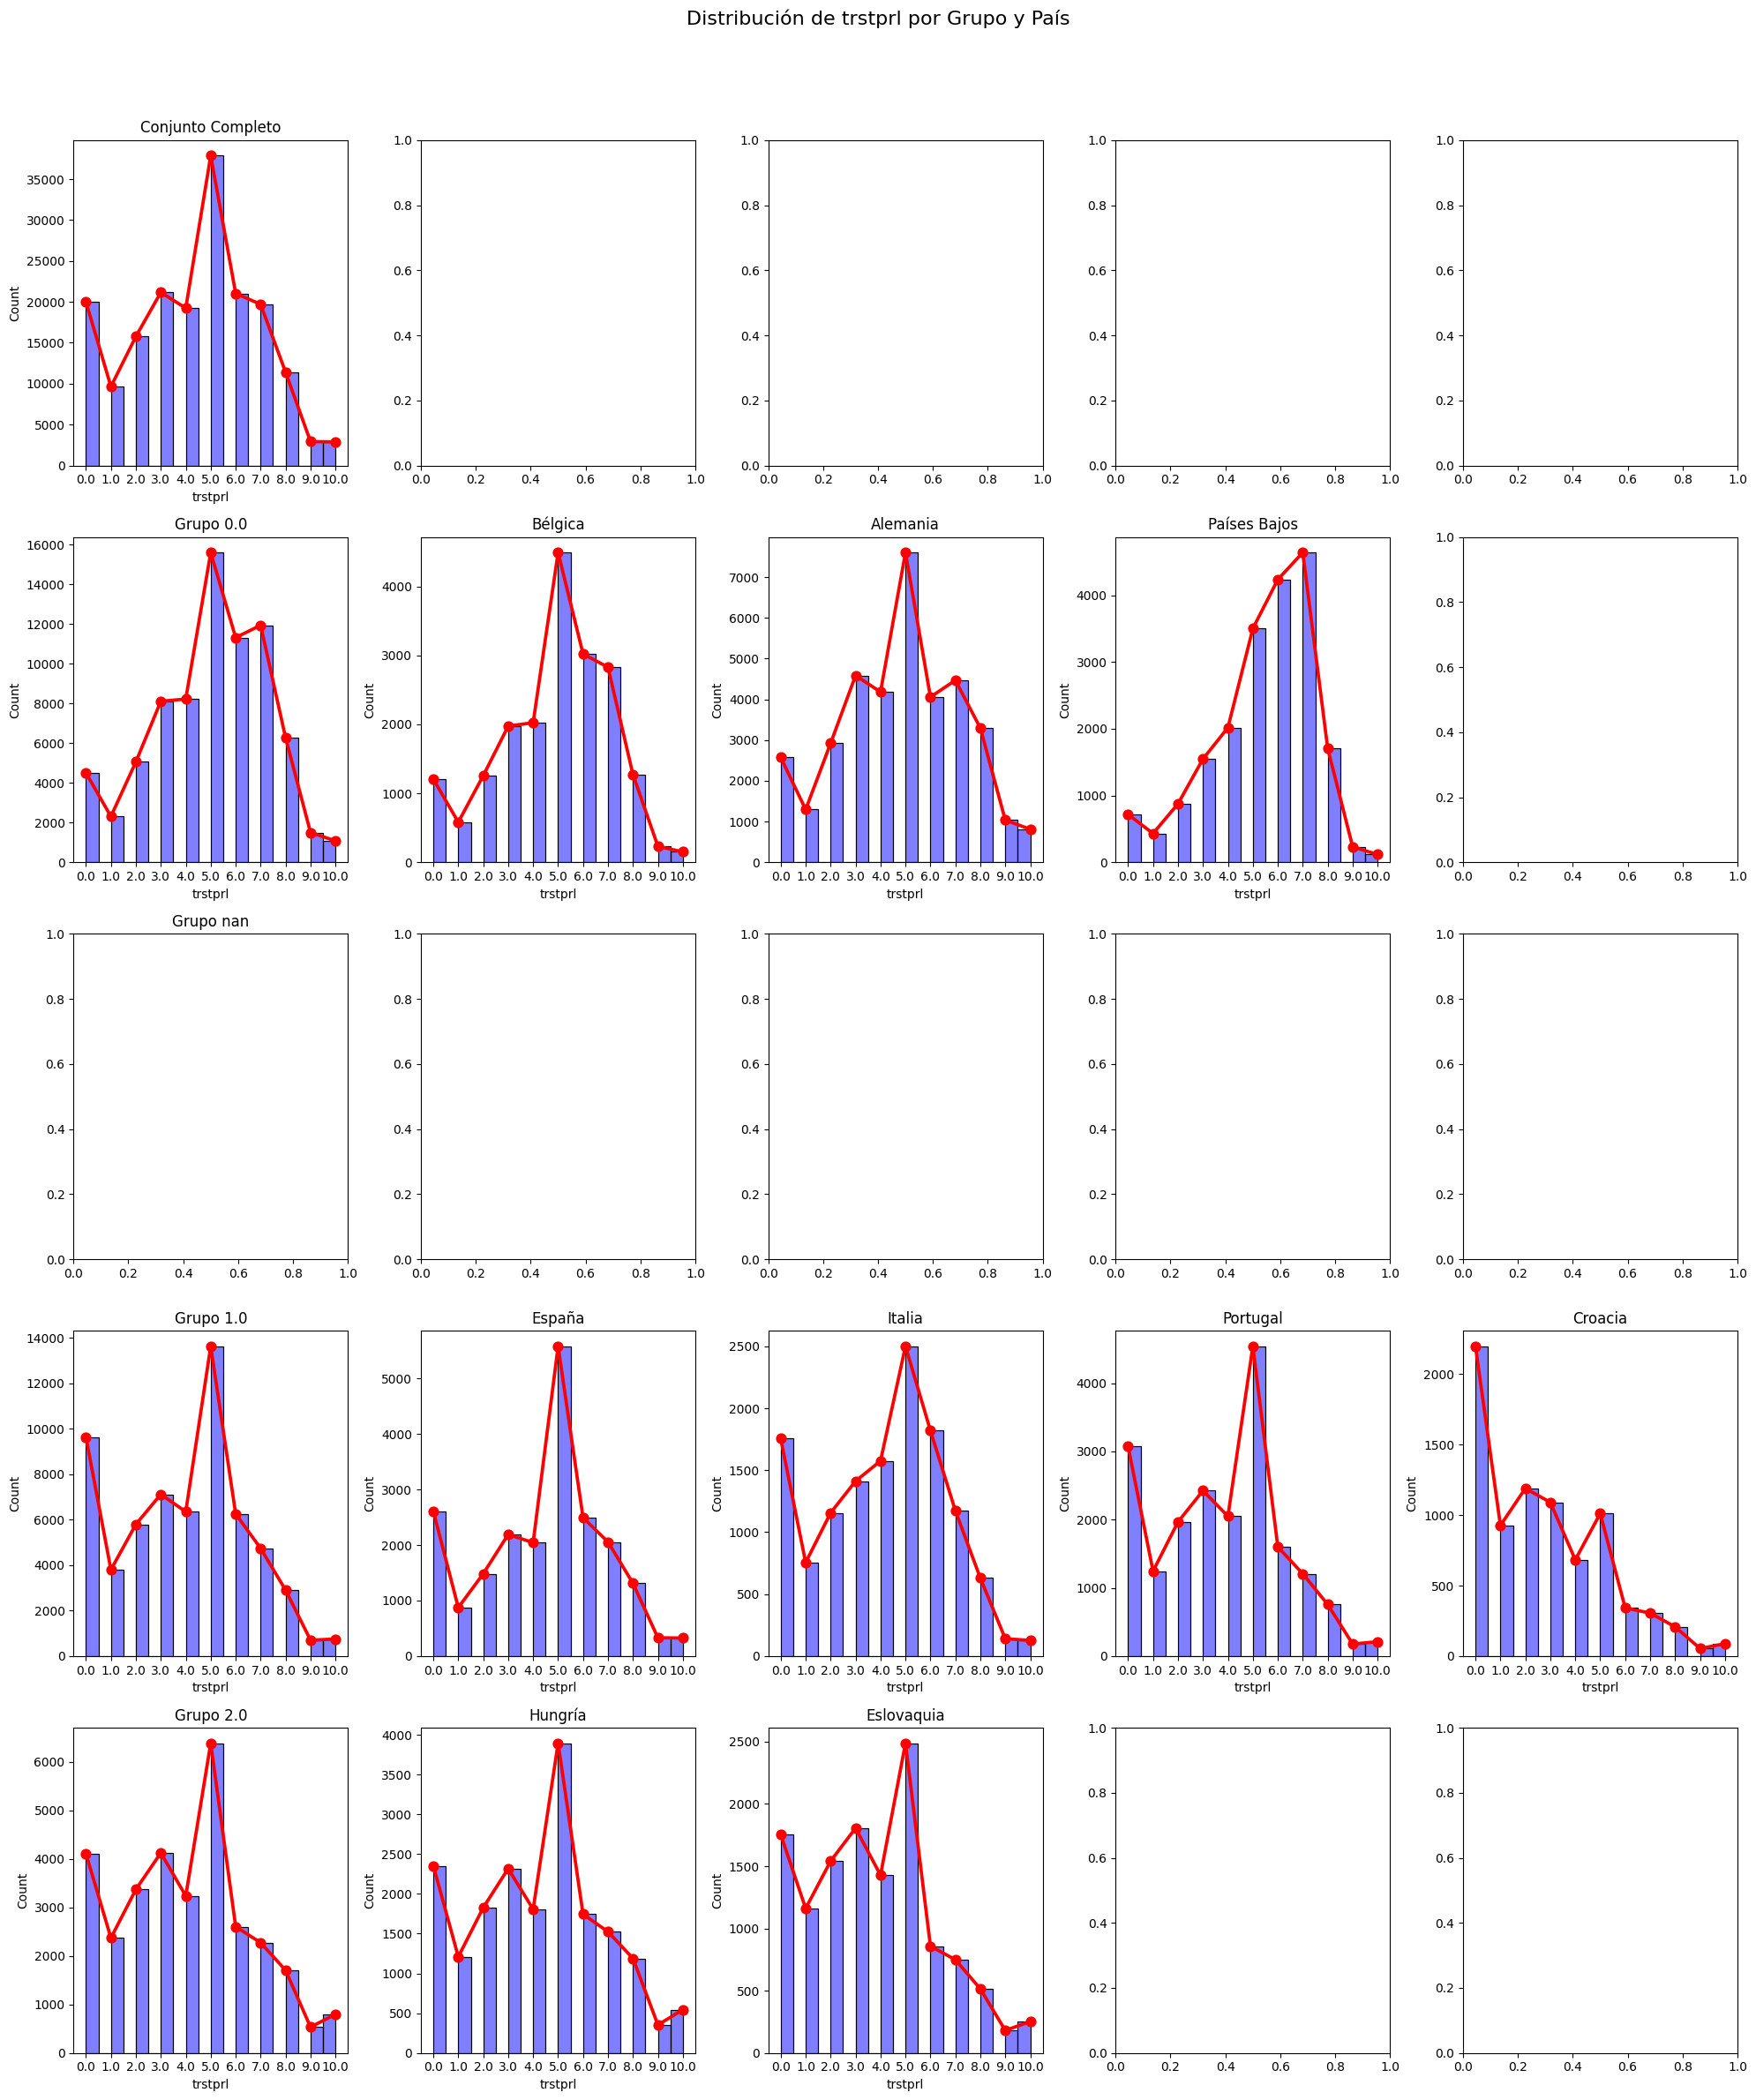

In [46]:
GroupDist(dfeu,'trstprl')

In [47]:
statsgroup(dfeu, 'trstprl')

Estadísticas para trstprl - Conjunto Completo:
count    181606.000000
mean          4.302496
std           2.497506
min           0.000000
25%           3.000000
50%           5.000000
75%           6.000000
max          10.000000
Name: trstprl, dtype: float64
Moda: 5.0, Frecuencia: 37875
Varianza: 6.237534258604348


Estadísticas para trstprl - Grupo 0.0:
count    75914.000000
mean         4.921819
std          2.300685
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: trstprl, dtype: float64
Moda: 5.0, Frecuencia: 15600
Varianza: 5.293151348263257


Estadísticas para trstprl - País Bélgica (Grupo 0.0):
count    19045.000000
mean         4.794014
std          2.212495
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: trstprl, dtype: float64
Moda: 5.0, Frecuencia: 4492
Varianza: 4.895133250166573


Estadísticas para trstprl - País Alemania (Grupo 0.0):
cou

13-'trstprl': Escala de 0 a 10, grado de confianza con el parlamento nacional, 0 siendo inexistente.

Variable discontinua muy similar a la anterior. No ofrece mucha significancia al dataset.

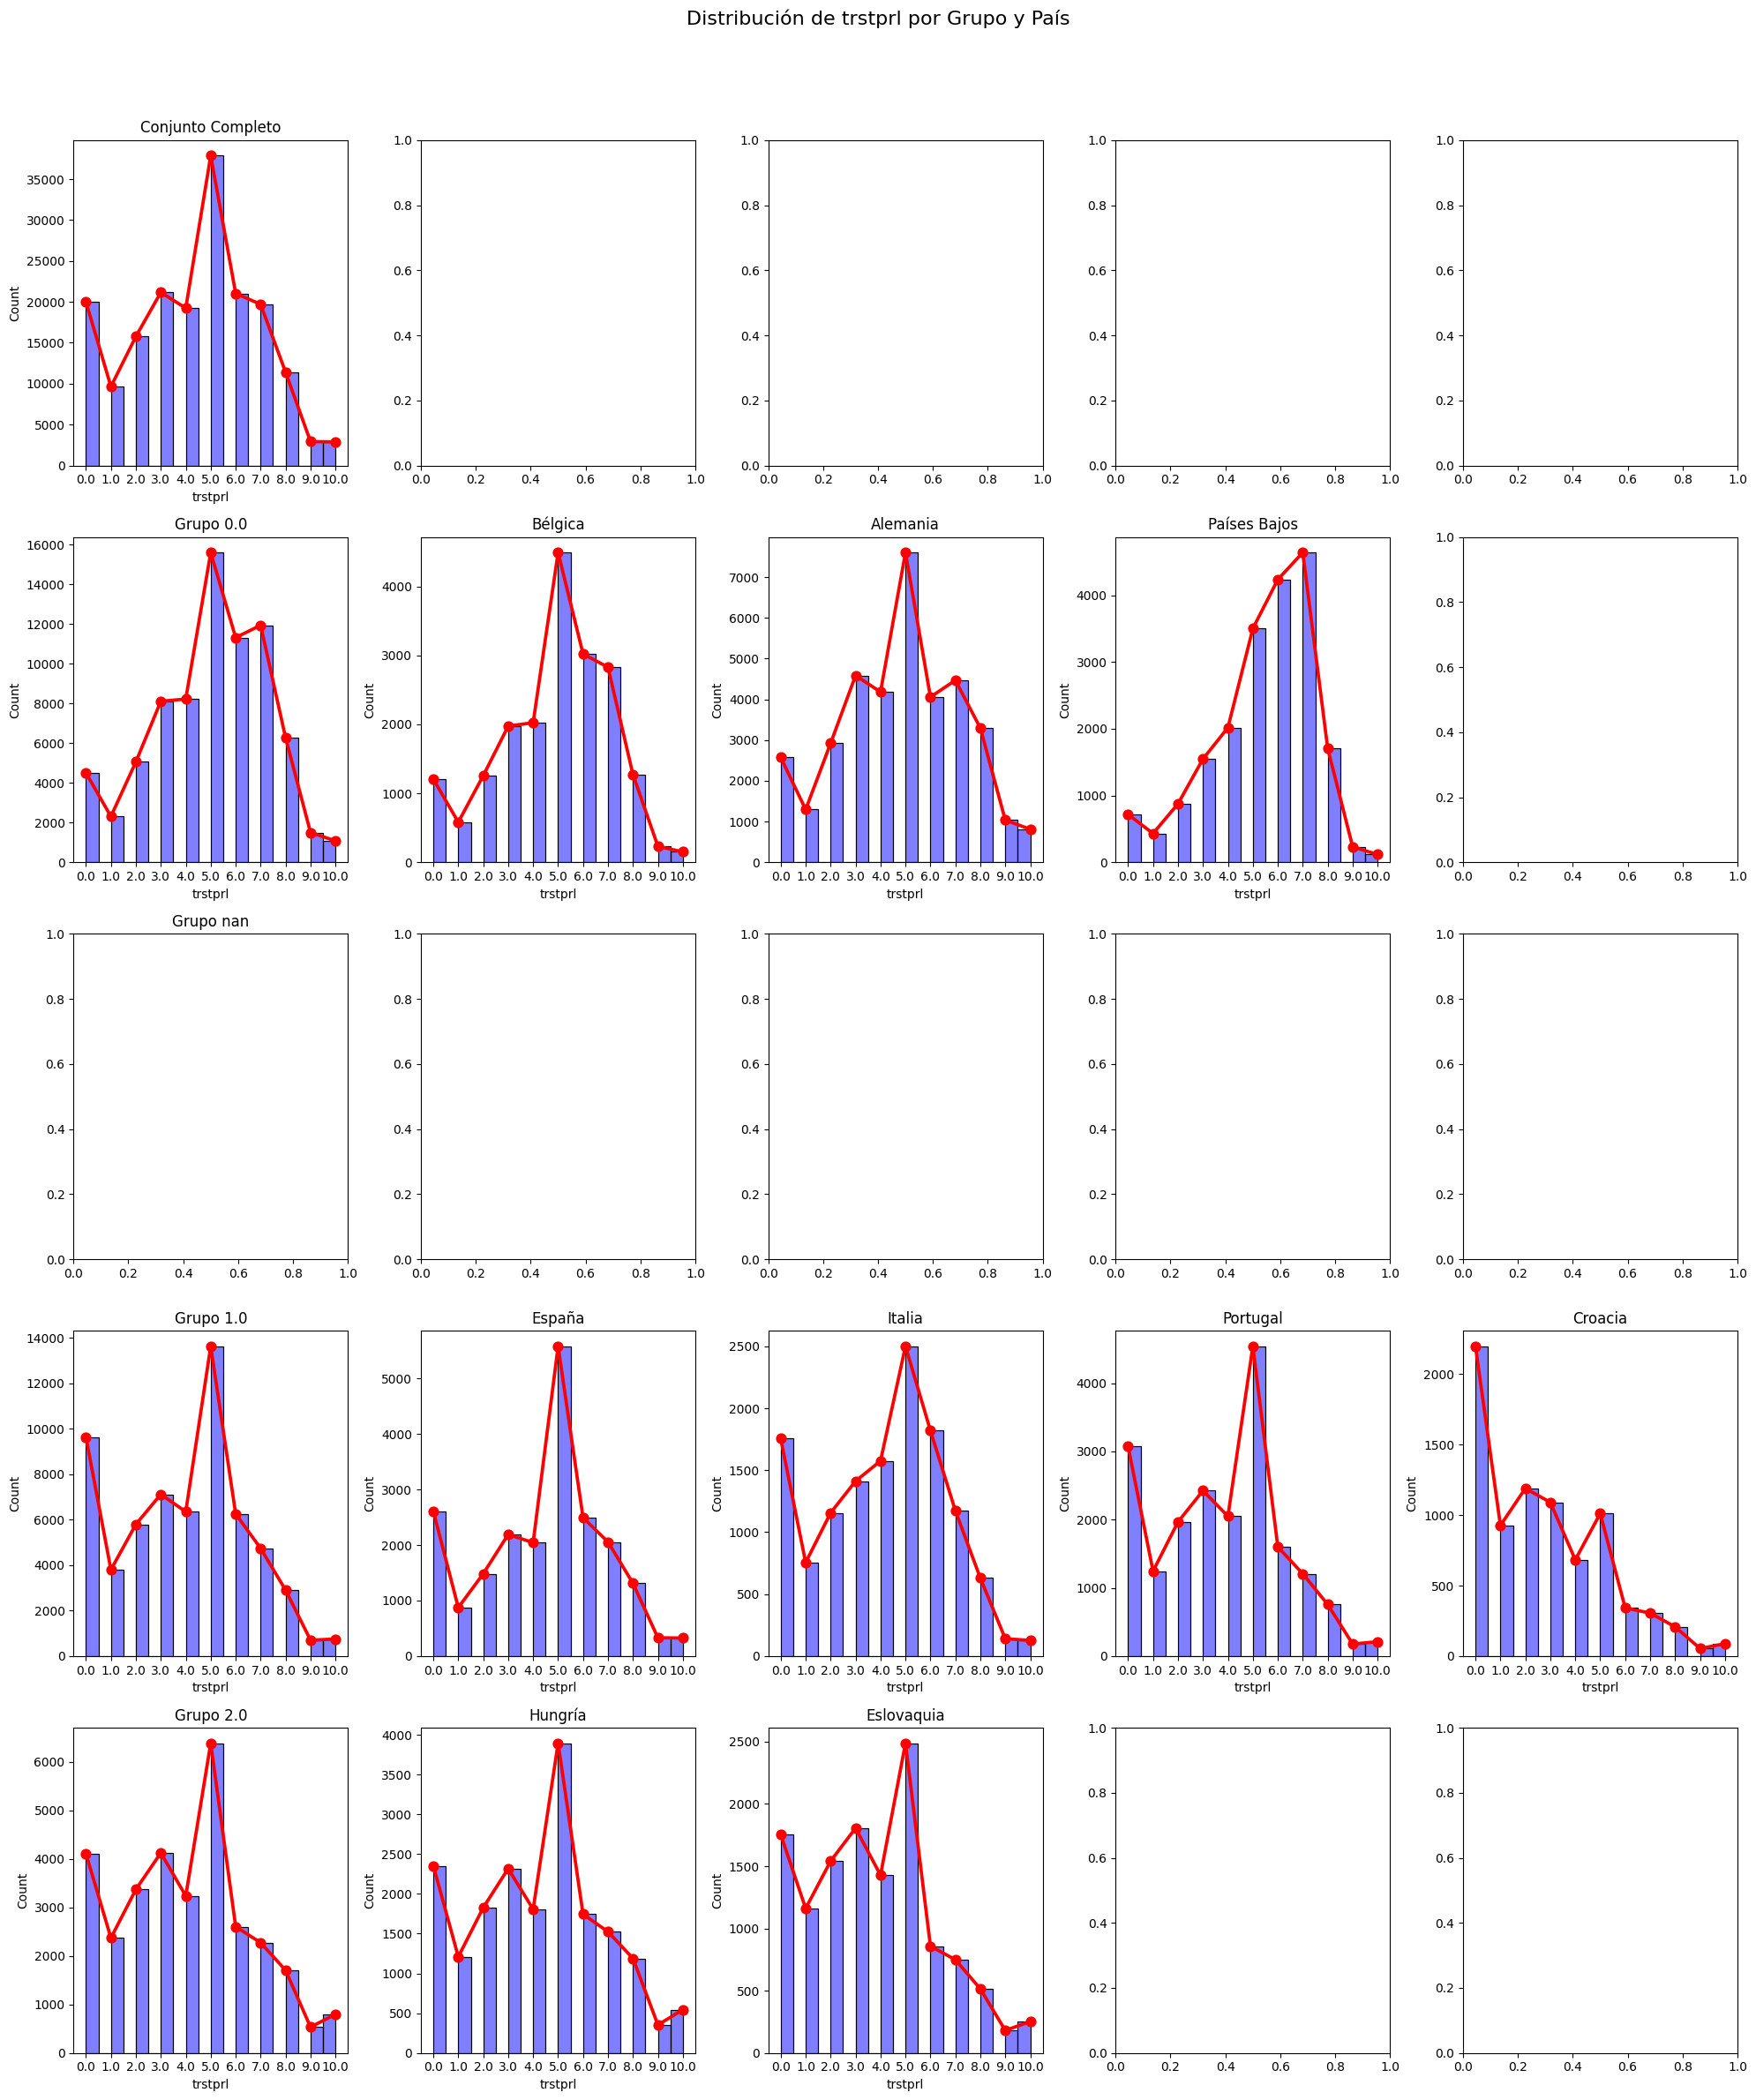

Estadísticas para trstprt - Conjunto Completo:
count    181568.000000
mean          3.315105
std           2.403166
min           0.000000
25%           1.000000
50%           3.000000
75%           5.000000
max          10.000000
Name: trstprt, dtype: float64
Moda: 0.0, Frecuencia: 36028
Varianza: 5.775206357955938


Estadísticas para trstprt - Grupo 0.0:
count    75914.000000
mean         4.263324
std          2.099818
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: trstprt, dtype: float64
Moda: 5.0, Frecuencia: 19305
Varianza: 4.409233563193101


Estadísticas para trstprt - País Bélgica (Grupo 0.0):
count    19045.000000
mean         4.210974
std          2.074848
min          0.000000
25%          3.000000
50%          5.000000
75%          5.000000
max         10.000000
Name: trstprt, dtype: float64
Moda: 5.0, Frecuencia: 5835
Varianza: 4.304994036554003


Estadísticas para trstprt - País Alemania (Grupo 0.0):
cou

In [48]:
#Variable 'trstprt'
GroupDist(dfeu, 'trstprl')
statsgroup(dfeu,'trstprt')


14-'trstprt': Escala de 0 a 10, grado de confianza con los partidos politicos, 0 siendo inexistente.

Variable discontinua con semantica y distribuciones muy similares a las dos anteriores que hacen referencia al circulo político

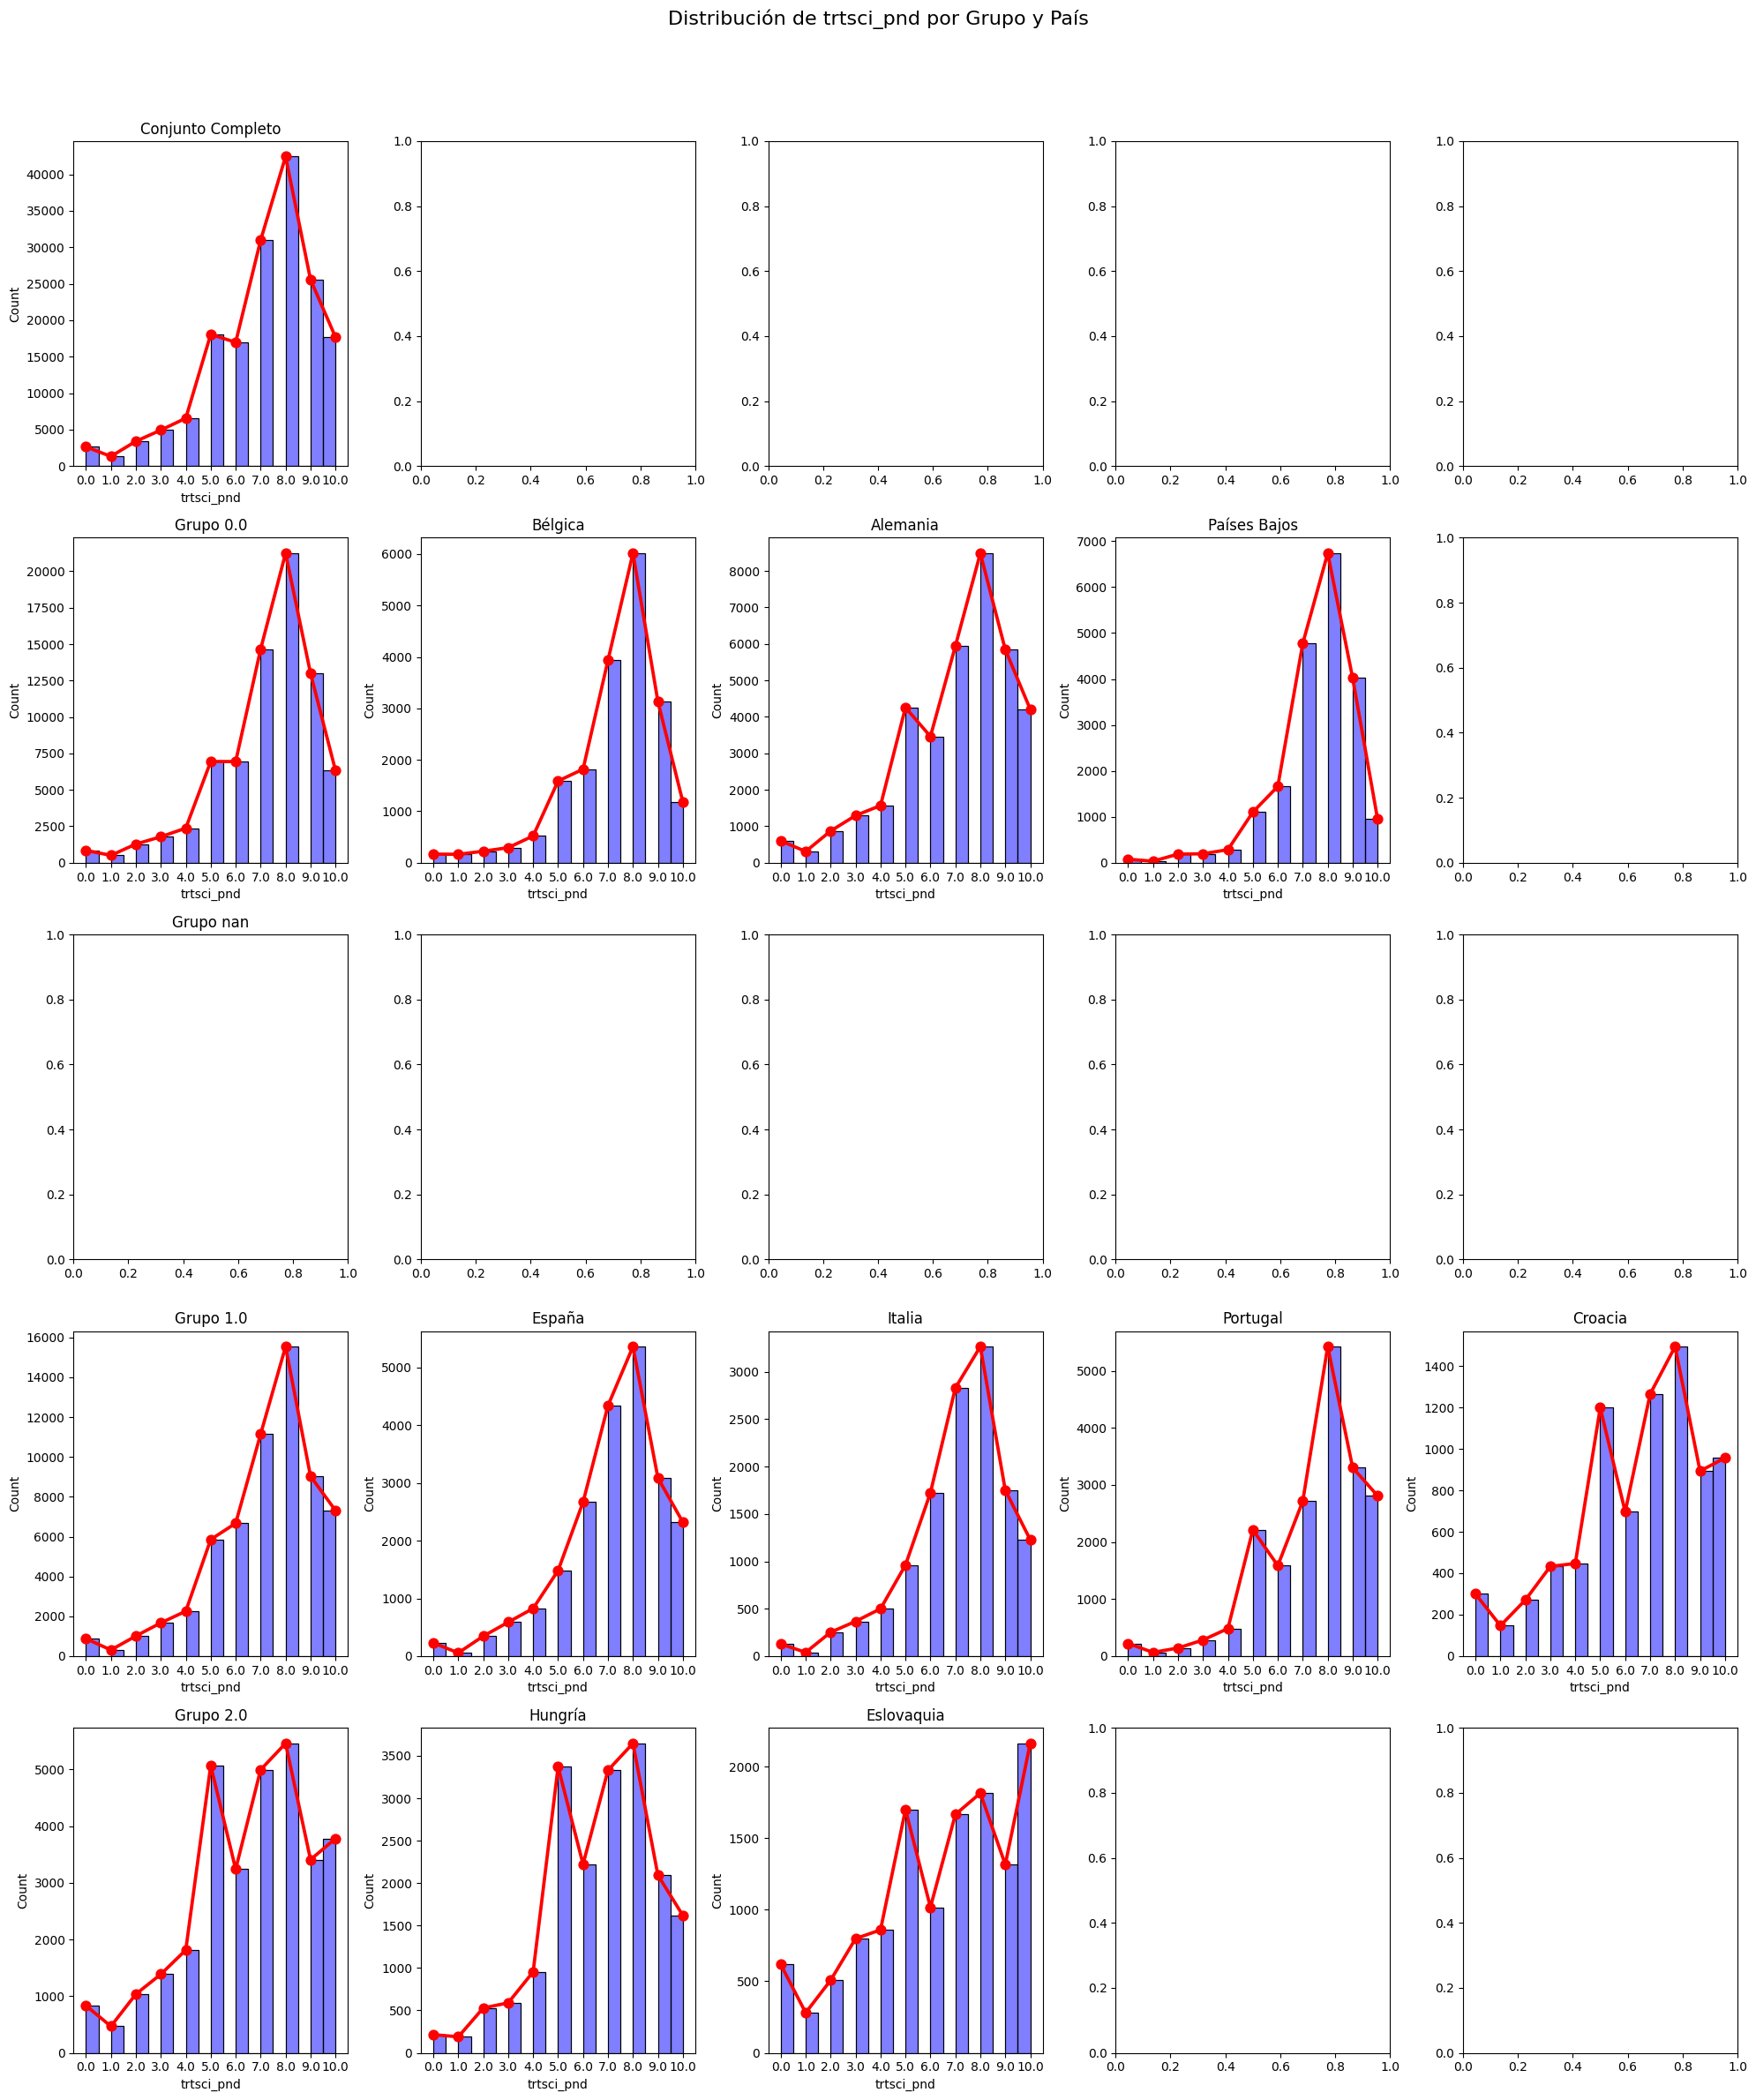

In [49]:
#Variable 'trtsci_pnd'
GroupDist(dfeu,'trtsci_pnd')

In [50]:
statsgroup(dfeu,'trtsci_pnd')

Estadísticas para trtsci_pnd - Conjunto Completo:
count    170488.000000
mean          7.063570
std           2.154509
min           0.000000
25%           6.000000
50%           8.000000
75%           9.000000
max          10.000000
Name: trtsci_pnd, dtype: float64
Moda: 8.0, Frecuencia: 42440
Varianza: 4.641908317887439


Estadísticas para trtsci_pnd - Grupo 0.0:
count    75914.000000
mean         7.207682
std          1.999479
min          0.000000
25%          6.000000
50%          8.000000
75%          9.000000
max         10.000000
Name: trtsci_pnd, dtype: float64
Moda: 8.0, Frecuencia: 21241
Varianza: 3.997914449929321


Estadísticas para trtsci_pnd - País Bélgica (Grupo 0.0):
count    19045.000000
mean         7.252875
std          1.851022
min          0.000000
25%          6.000000
50%          8.000000
75%          8.000000
max         10.000000
Name: trtsci_pnd, dtype: float64
Moda: 8.0, Frecuencia: 6016
Varianza: 3.426284137068217


Estadísticas para trtsci_pnd - País Alem

15-'trtsci_pnd': Escala de 0 a 10, grado de confianza con el lobby cientifico, 0 siendo inexistente.

Variable discontinua que a computo general de muestras describe una funcion asimétrica con el mayor(mas del 50%) de muestras
desplazada positivamente respecto al valor medio aritmetico del rango de la variable. Alcanzando su maximo local de muestras en el valor 8.

Gracias a los subconjuntos de muestras podemos apreciar como gran cantidad de muestras se desplazan de tercer cuartil al segundo cuartil, conforme los grupos de paises son mas pobres,creando funciones asimetricas bimodales mas cercanas a la media aritmetica del valor de la variable.

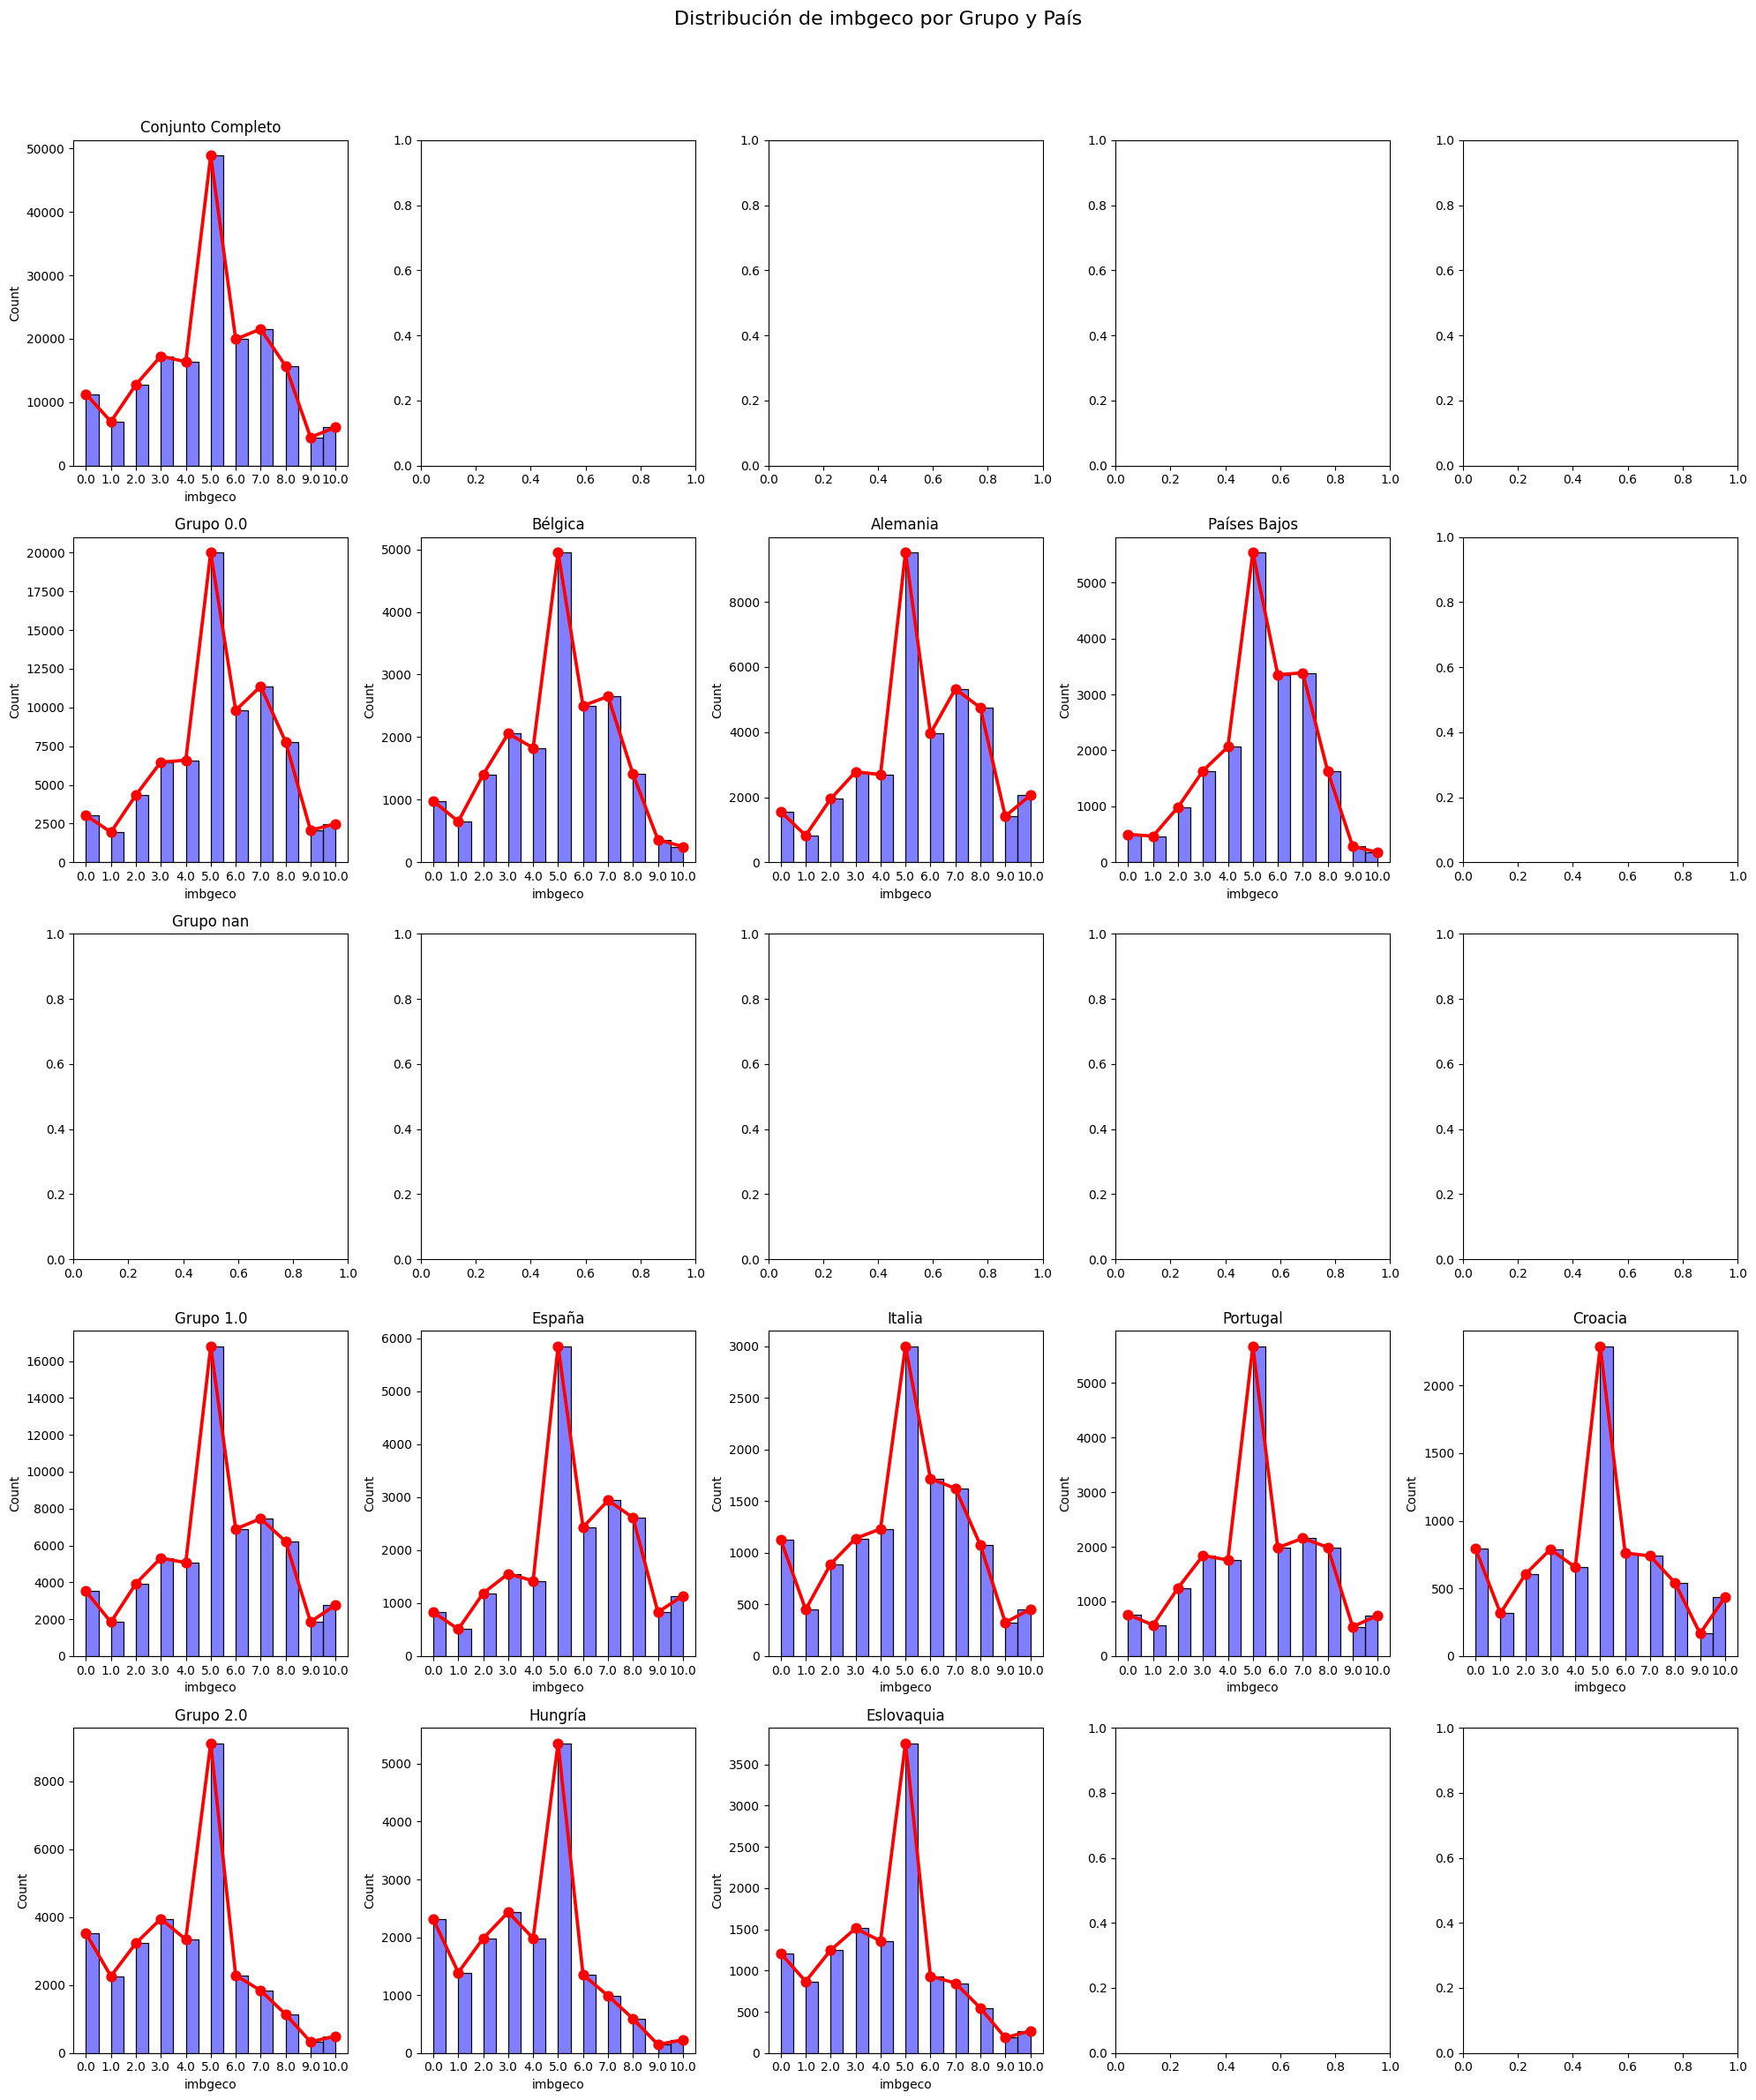

In [51]:
#Variable 'imbgeco'
GroupDist(dfeu, 'imbgeco')

In [52]:
statsgroup(dfeu, 'imbgeco')

Estadísticas para imbgeco - Conjunto Completo:
count    181030.000000
mean          4.915865
std           2.420084
min           0.000000
25%           3.000000
50%           5.000000
75%           7.000000
max          10.000000
Name: imbgeco, dtype: float64
Moda: 5.0, Frecuencia: 48880
Varianza: 5.856804911752606


Estadísticas para imbgeco - Grupo 0.0:
count    75914.000000
mean         5.278012
std          2.276471
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: imbgeco, dtype: float64
Moda: 5.0, Frecuencia: 20004
Varianza: 5.182321309461351


Estadísticas para imbgeco - País Bélgica (Grupo 0.0):
count    19045.000000
mean         4.846731
std          2.233502
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: imbgeco, dtype: float64
Moda: 5.0, Frecuencia: 4949
Varianza: 4.988532295276297


Estadísticas para imbgeco - País Alemania (Grupo 0.0):
cou

16-'imbgeco': Escala de 0 a 10, grado de opinion sobre si la inmigracion es buena para la economia, 0 siendo absolutamente mala.

Variable discontinua numerica donde en todos los diferentes conjuntos de muestras describe una funcion simetrica gaussiana(o funcion normal), hay que hacer mencion al tercer grupo de muestras por paises donde claramente hay una migracion de muestras del tercer cuartil al primero y al primer rango intercuartilico. Pero a nivel general no hay muchas diferencias.


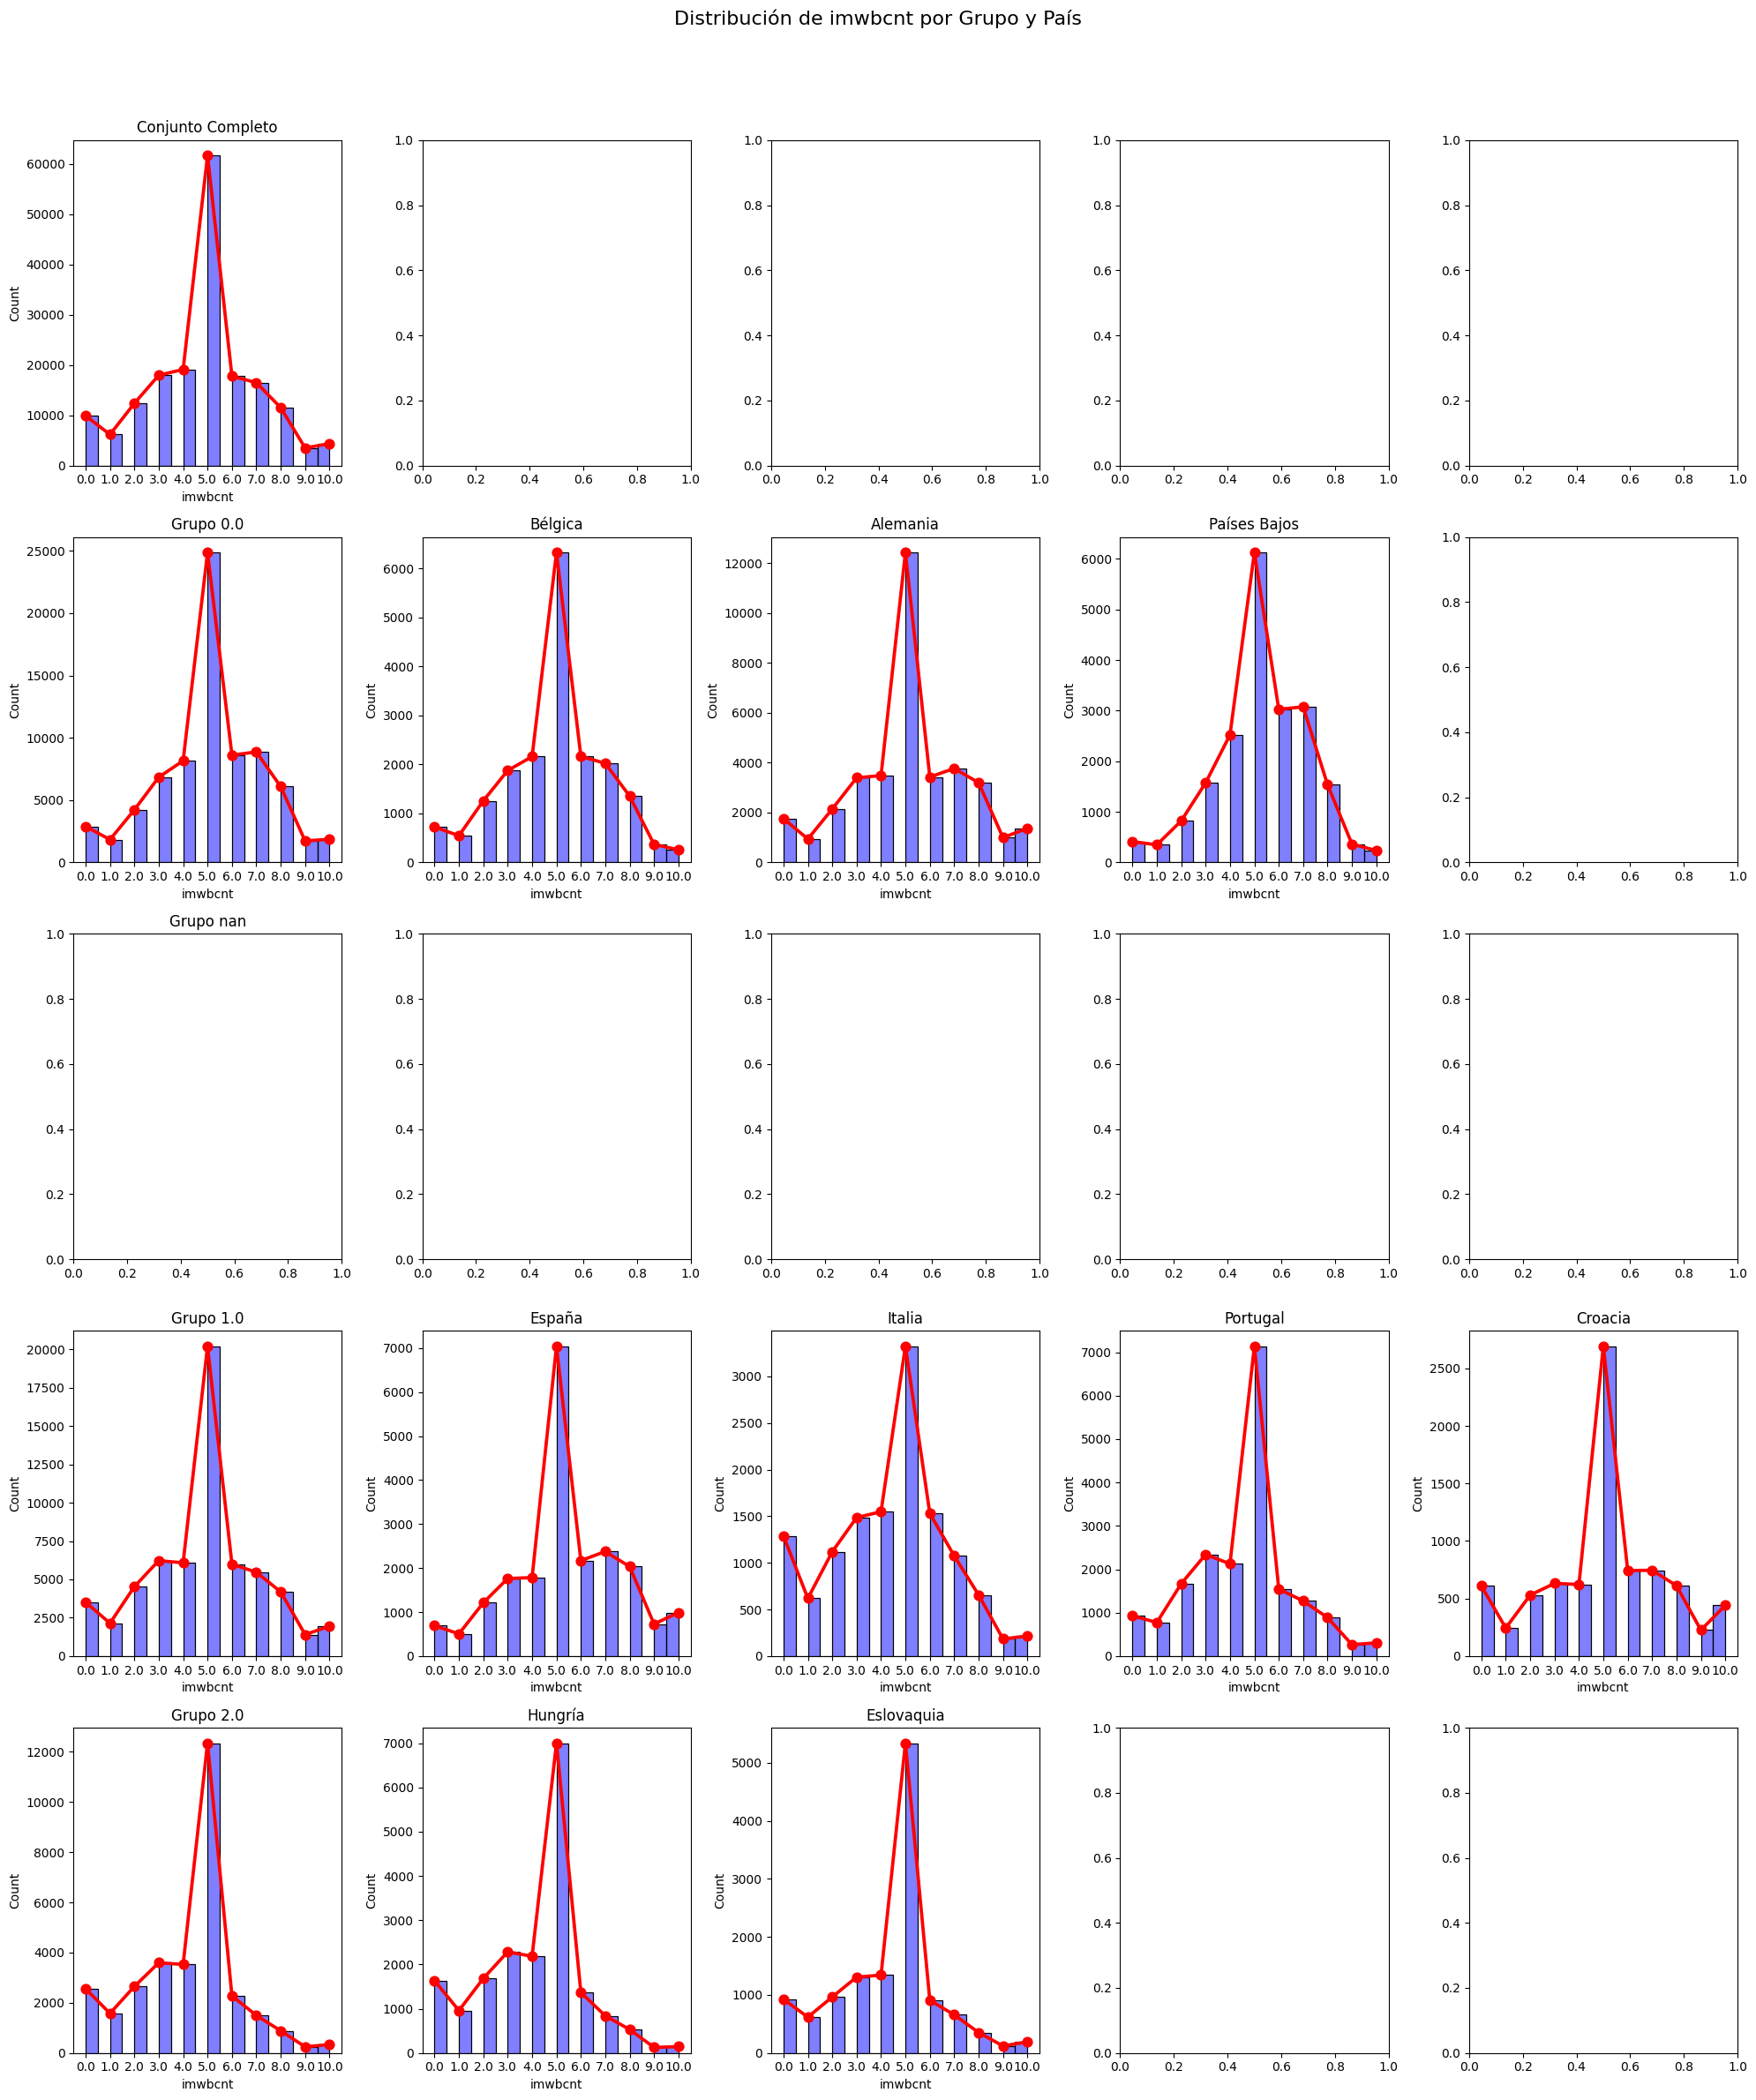

In [53]:
#Variable 'imwbcnt'
GroupDist(dfeu, 'imwbcnt')

In [54]:
statsgroup(dfeu, 'imwbcnt')


Estadísticas para imwbcnt - Conjunto Completo:
count    180754.000000
mean          4.749134
std           2.216896
min           0.000000
25%           3.000000
50%           5.000000
75%           6.000000
max          10.000000
Name: imwbcnt, dtype: float64
Moda: 5.0, Frecuencia: 61665
Varianza: 4.91462653178393


Estadísticas para imwbcnt - Grupo 0.0:
count    75914.000000
mean         5.059357
std          2.138619
min          0.000000
25%          4.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: imwbcnt, dtype: float64
Moda: 5.0, Frecuencia: 24870
Varianza: 4.57369013183931


Estadísticas para imwbcnt - País Bélgica (Grupo 0.0):
count    19045.000000
mean         4.870885
std          2.076634
min          0.000000
25%          4.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: imwbcnt, dtype: float64
Moda: 5.0, Frecuencia: 6326
Varianza: 4.312408401177216


Estadísticas para imwbcnt - País Alemania (Grupo 0.0):
count

17-'imwbcnt': Escala de 0 a 10, grado de opinión sobre si la inmigracion hace peor la calidad de vida nacional, 0 siendo afirmativo.

Variable discontinua que en su distribucion con el total de las muestras sigue un patron gaussiano, solo podemos apreciar una leve fuga de muestras del tercel cuartil al primer cuartil y segundo en el subconjunto del grupo pobre de paises, tambien se ovserva que italia en el subconjunto 1 hay mas muestras en el primer cuartil que el tercero.
Saquen sus conclusiones.

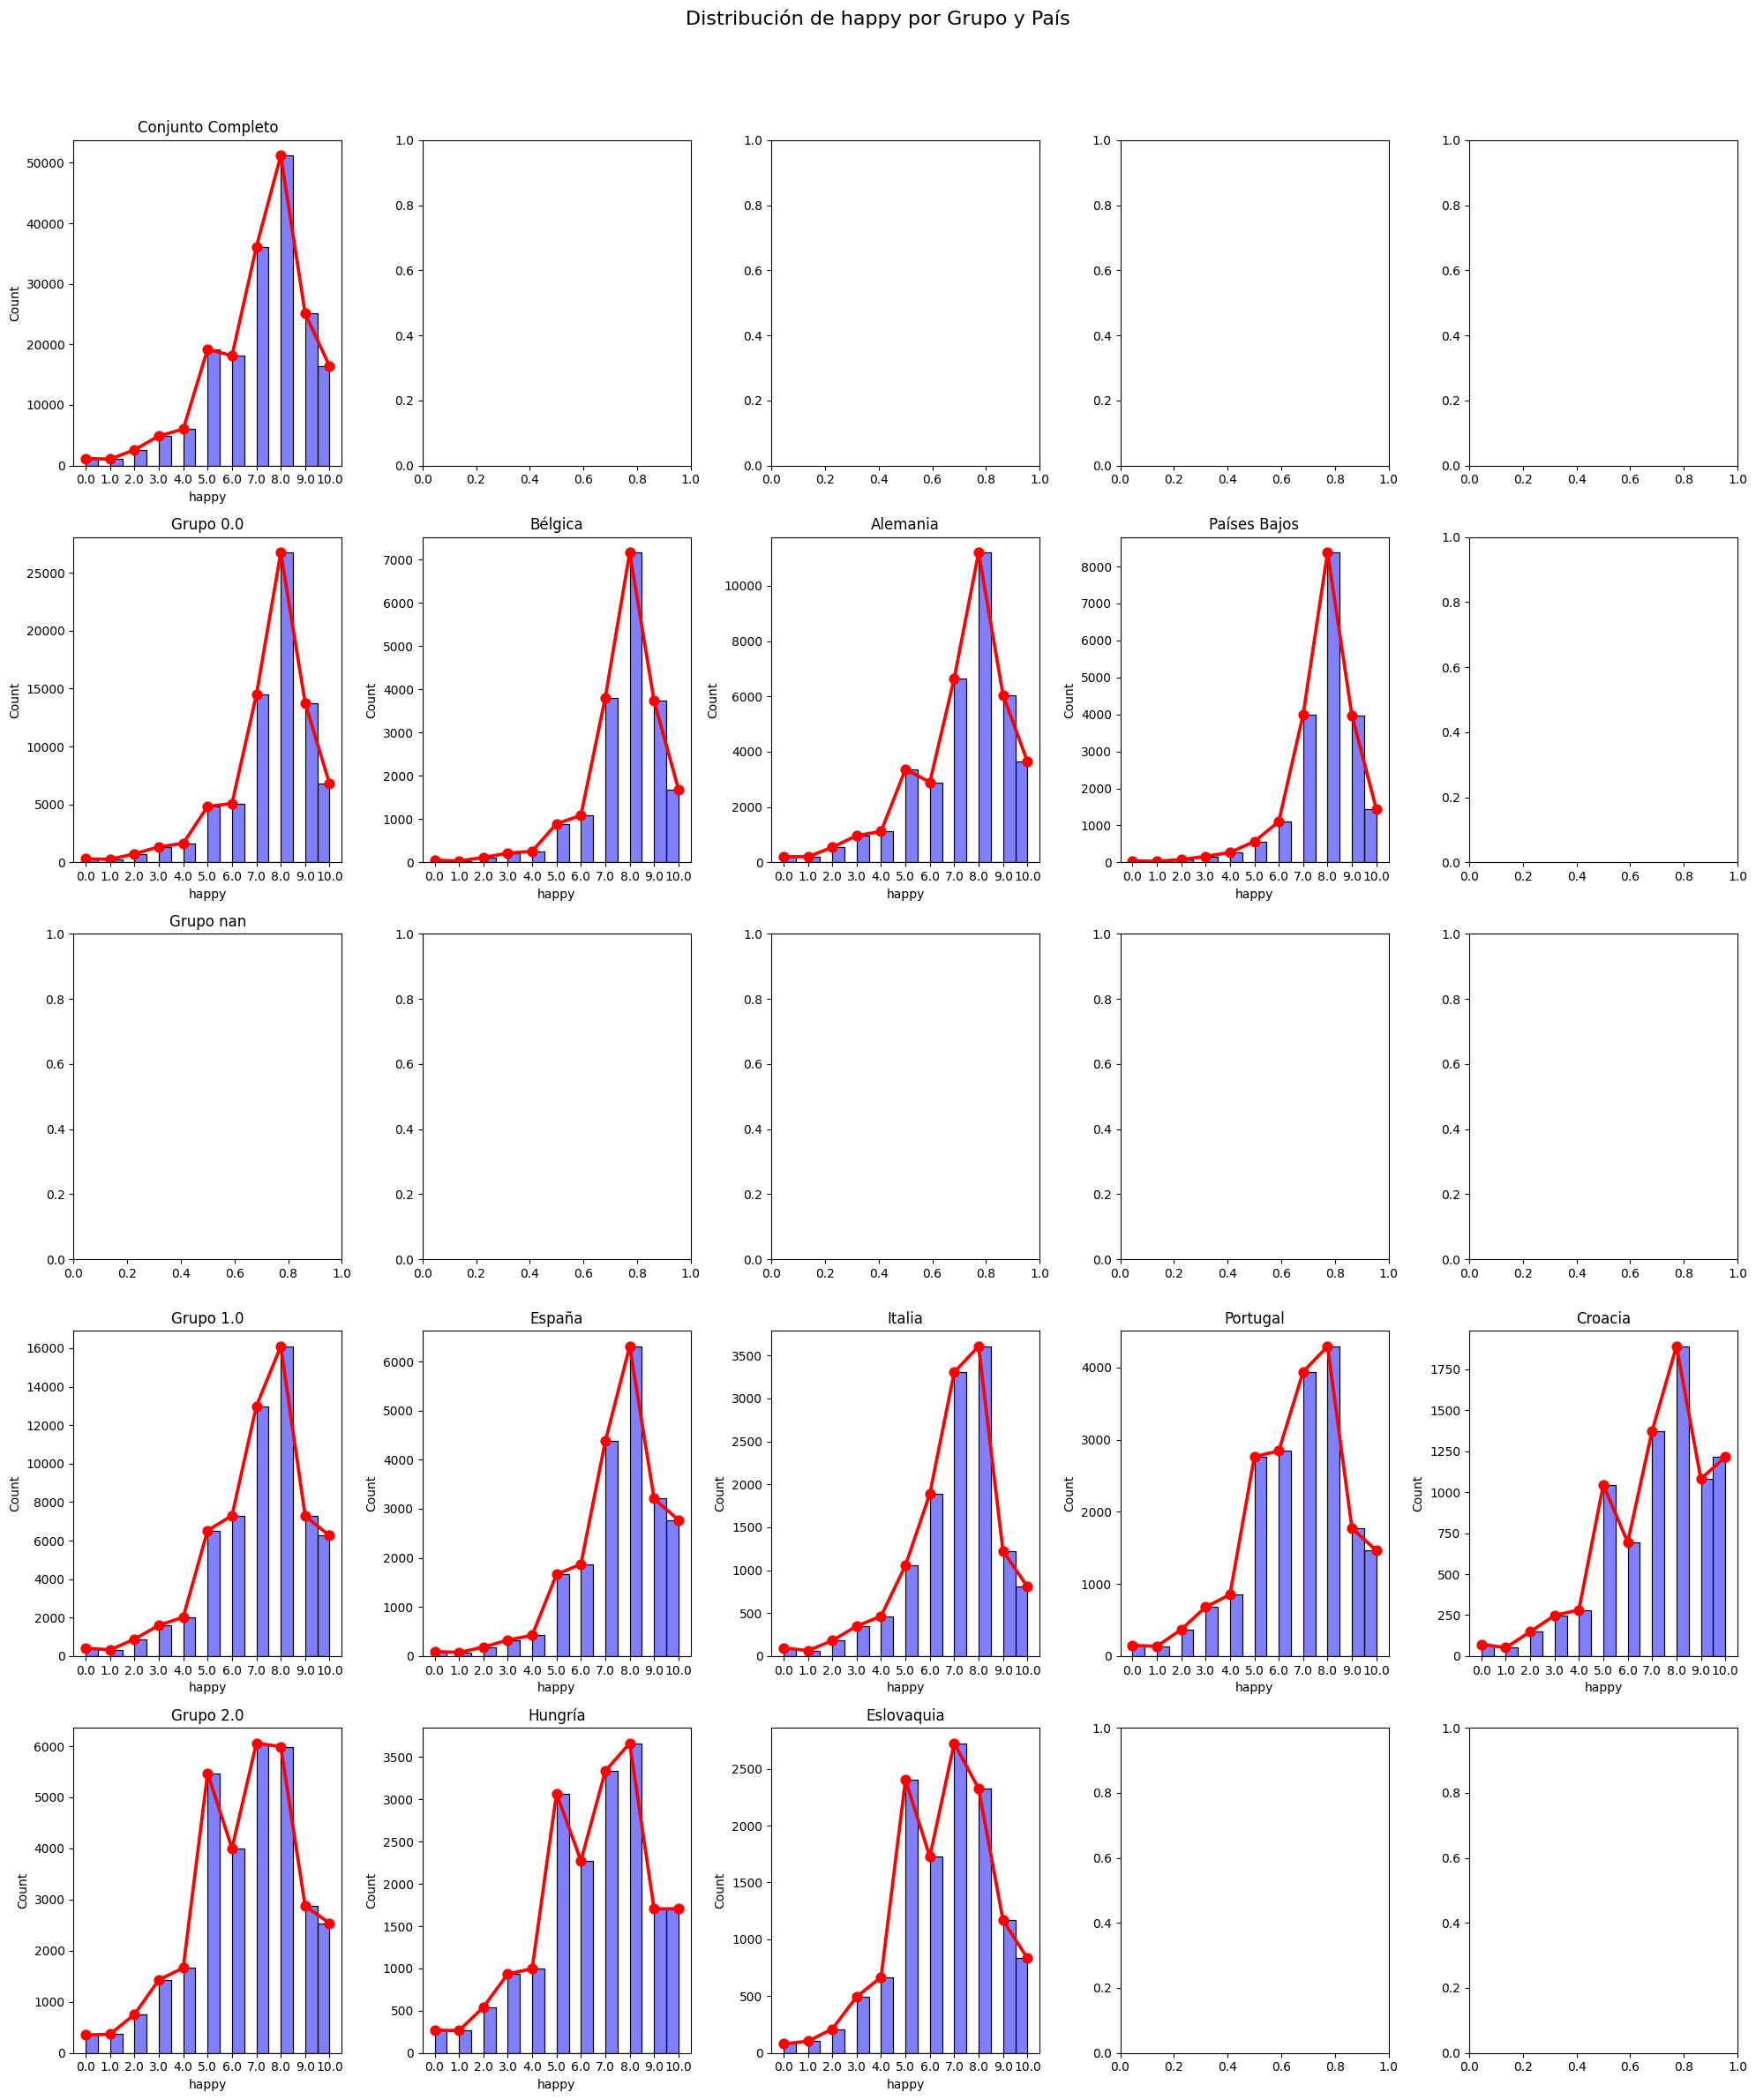

In [55]:
#Variable 'happy'
GroupDist(dfeu,'happy')

In [56]:
statsgroup(dfeu, 'happy')

Estadísticas para happy - Conjunto Completo:
count    181689.000000
mean          7.162013
std           1.933105
min           0.000000
25%           6.000000
50%           8.000000
75%           8.000000
max          10.000000
Name: happy, dtype: float64
Moda: 8.0, Frecuencia: 51164
Varianza: 3.7368950182993443


Estadísticas para happy - Grupo 0.0:
count    75914.000000
mean         7.557539
std          1.709191
min          0.000000
25%          7.000000
50%          8.000000
75%          9.000000
max         10.000000
Name: happy, dtype: float64
Moda: 8.0, Frecuencia: 26749
Varianza: 2.9213332439536313


Estadísticas para happy - País Bélgica (Grupo 0.0):
count    19045.000000
mean         7.741087
std          1.513960
min          0.000000
25%          7.000000
50%          8.000000
75%          9.000000
max         10.000000
Name: happy, dtype: float64
Moda: 8.0, Frecuencia: 7169
Varianza: 2.2920762182935


Estadísticas para happy - País Alemania (Grupo 0.0):
count    36845.00

18-'happy': Escala de 0 a 10, grado de cuan feliz eres, siendo 0 infeliz.

Variable discontinua numerica que por lo general no cambia en funcion del subgrupo de paises.
Describe una funcion gaussiana asimetrica, desplazada positivamente respecto al valor medio del rango de la variable.

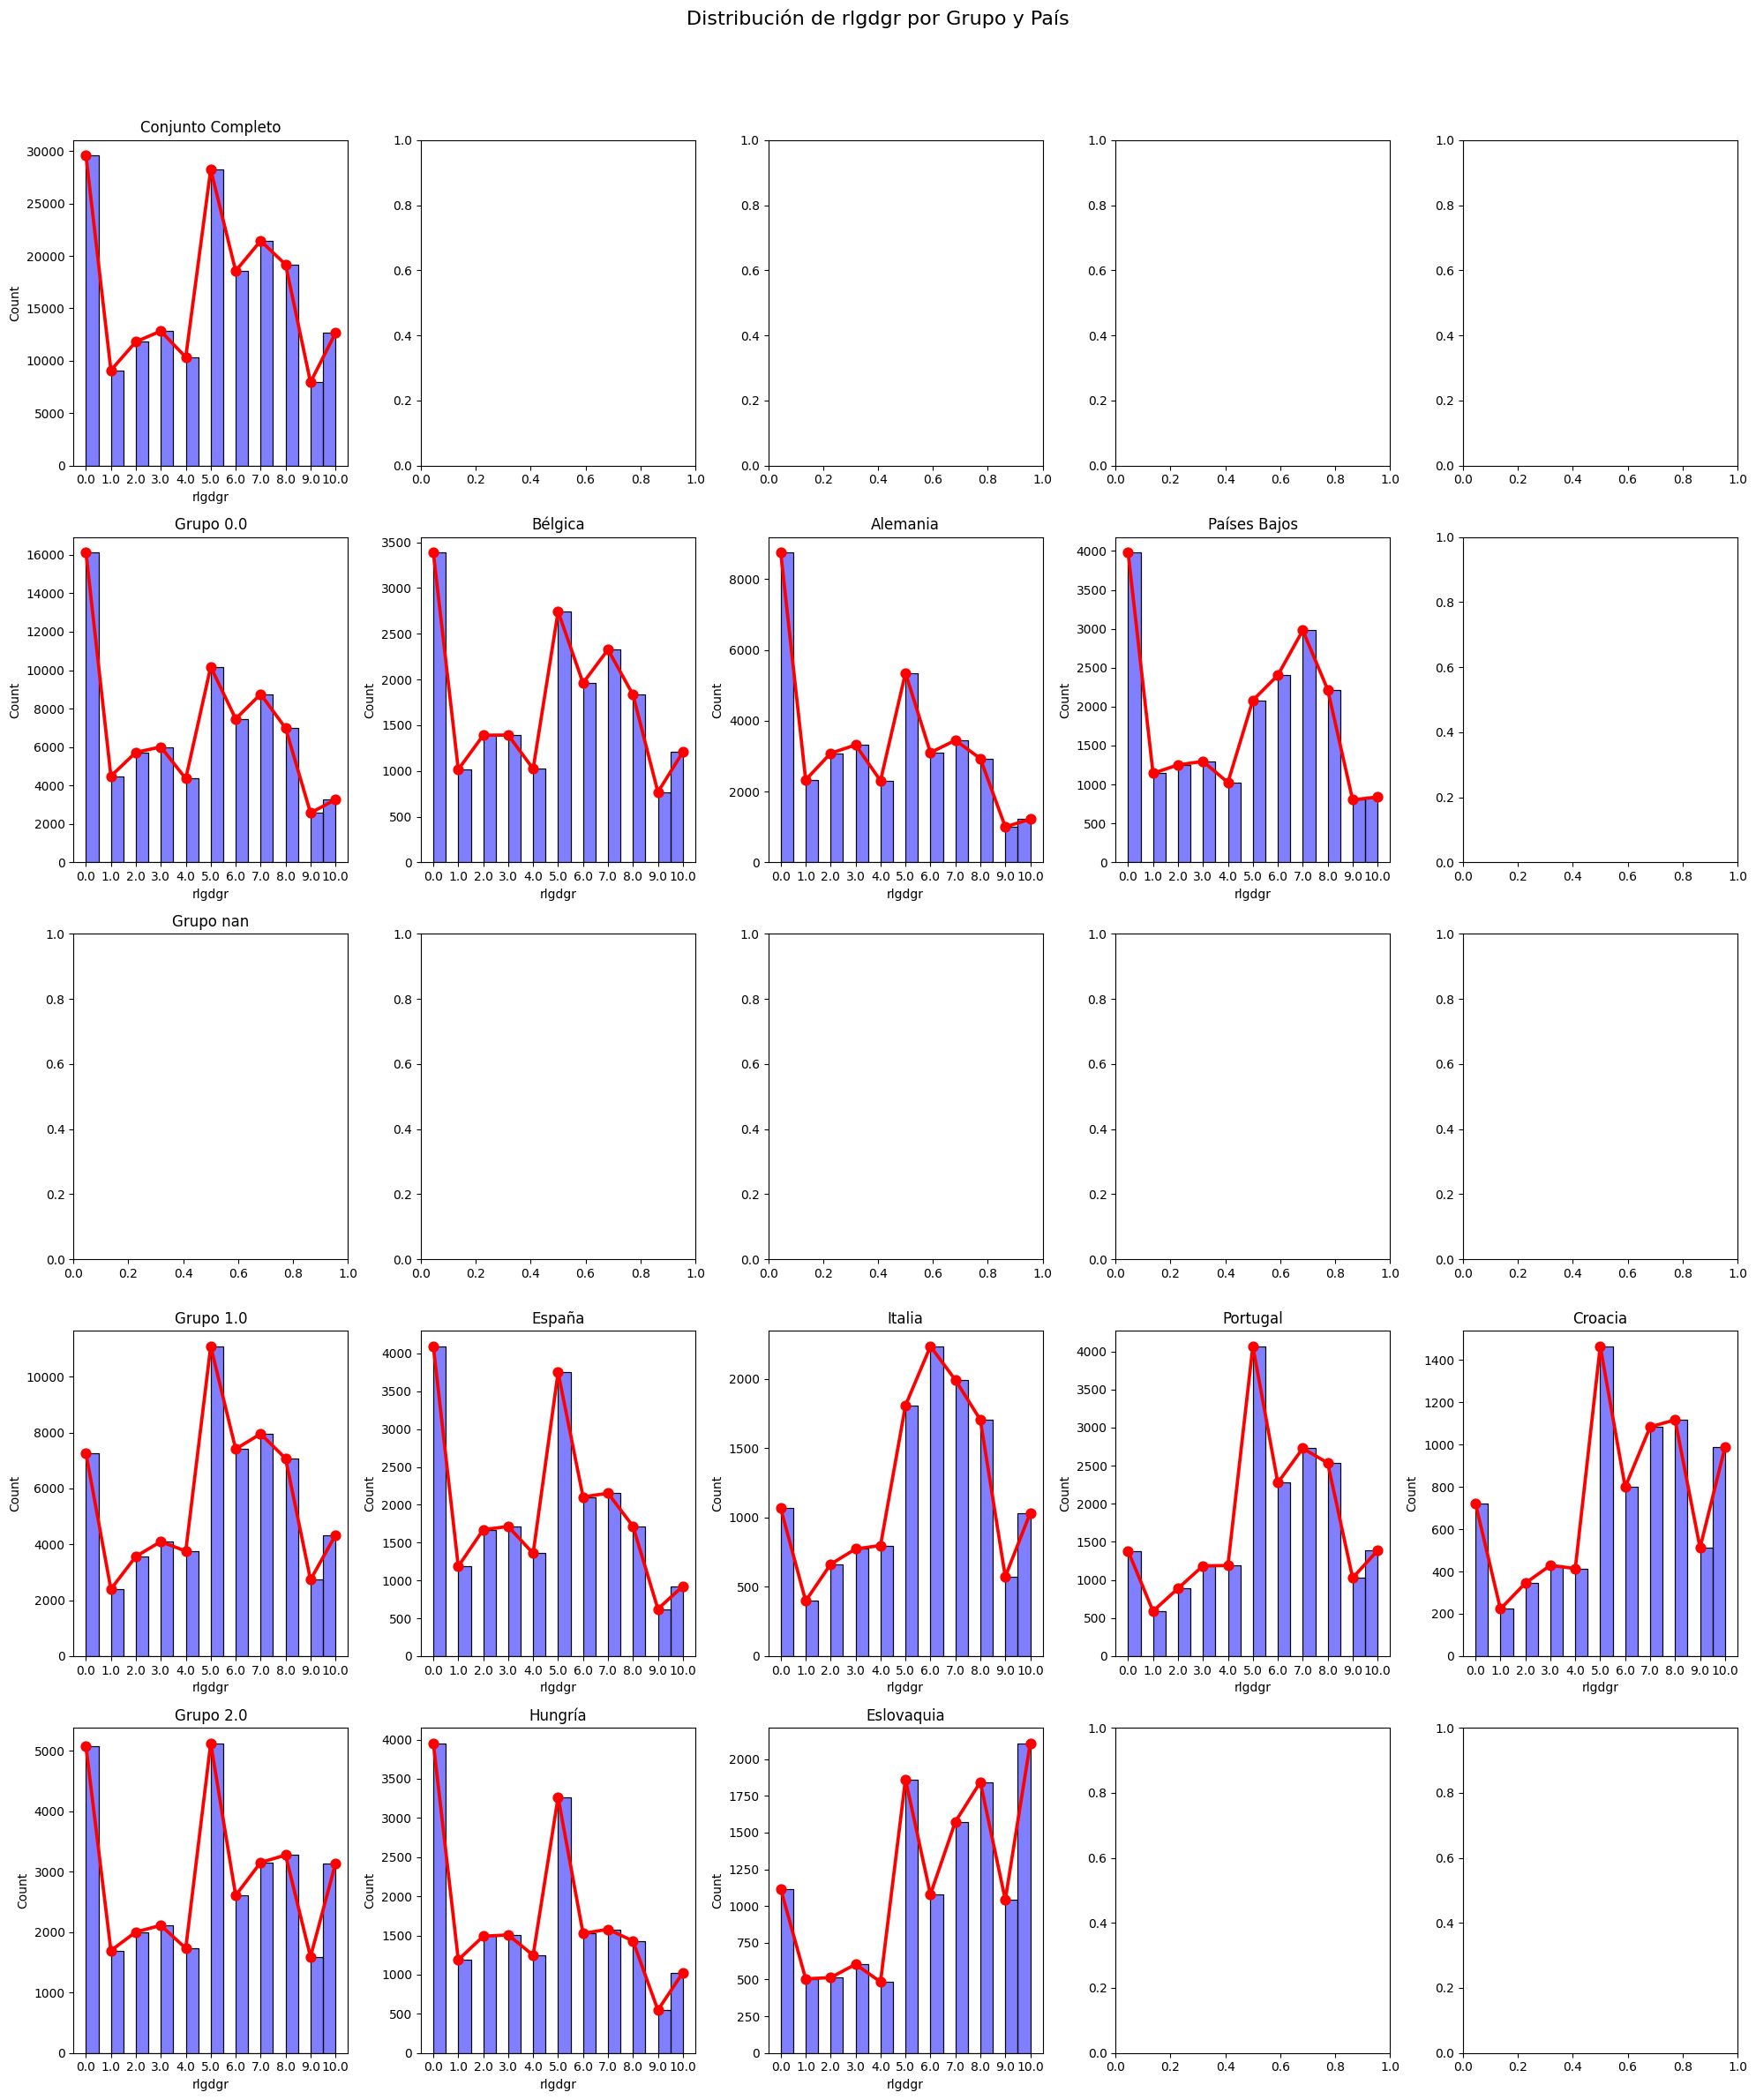

In [57]:
#Variable 'rlgdgr'
GroupDist(dfeu, 'rlgdgr')

In [58]:
statsgroup(dfeu, 'rlgdgr')

Estadísticas para rlgdgr - Conjunto Completo:
count    181638.000000
mean          4.770841
std           3.115496
min           0.000000
25%           2.000000
50%           5.000000
75%           7.000000
max          10.000000
Name: rlgdgr, dtype: float64
Moda: 0.0, Frecuencia: 29570
Varianza: 9.7063124900787


Estadísticas para rlgdgr - Grupo 0.0:
count    75914.000000
mean         4.215454
std          3.114046
min          0.000000
25%          1.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: rlgdgr, dtype: float64
Moda: 0.0, Frecuencia: 16122
Varianza: 9.697285431746366


Estadísticas para rlgdgr - País Bélgica (Grupo 0.0):
count    19045.000000
mean         4.592491
std          3.134243
min          0.000000
25%          2.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: rlgdgr, dtype: float64
Moda: 0.0, Frecuencia: 3388
Varianza: 9.82347859062505


Estadísticas para rlgdgr - País Alemania (Grupo 0.0):
count    3684

19-'rlgdgr': Escala de 0 a 10, cuan religioso eres, siendo 0 ateo. 

Variable discontinua que describe una funcion  antitónica, es decir que el mayor grueso de sus muestras se recogen cercanos a los valores minimos y maximos del rango de la variable, es una variable con bastante probabilidad de ser binarizada( es decir transformarla a binaria) ademas dada su significancia, no tiene sentido ser religioso moderado.
Se aprecian gruesos de muestras ubicados en el minimo y maximo distinto en cada subgrupo de paises.
Por lo general los paises del grupo 0 tienen mas muestras en el primer cuartil.

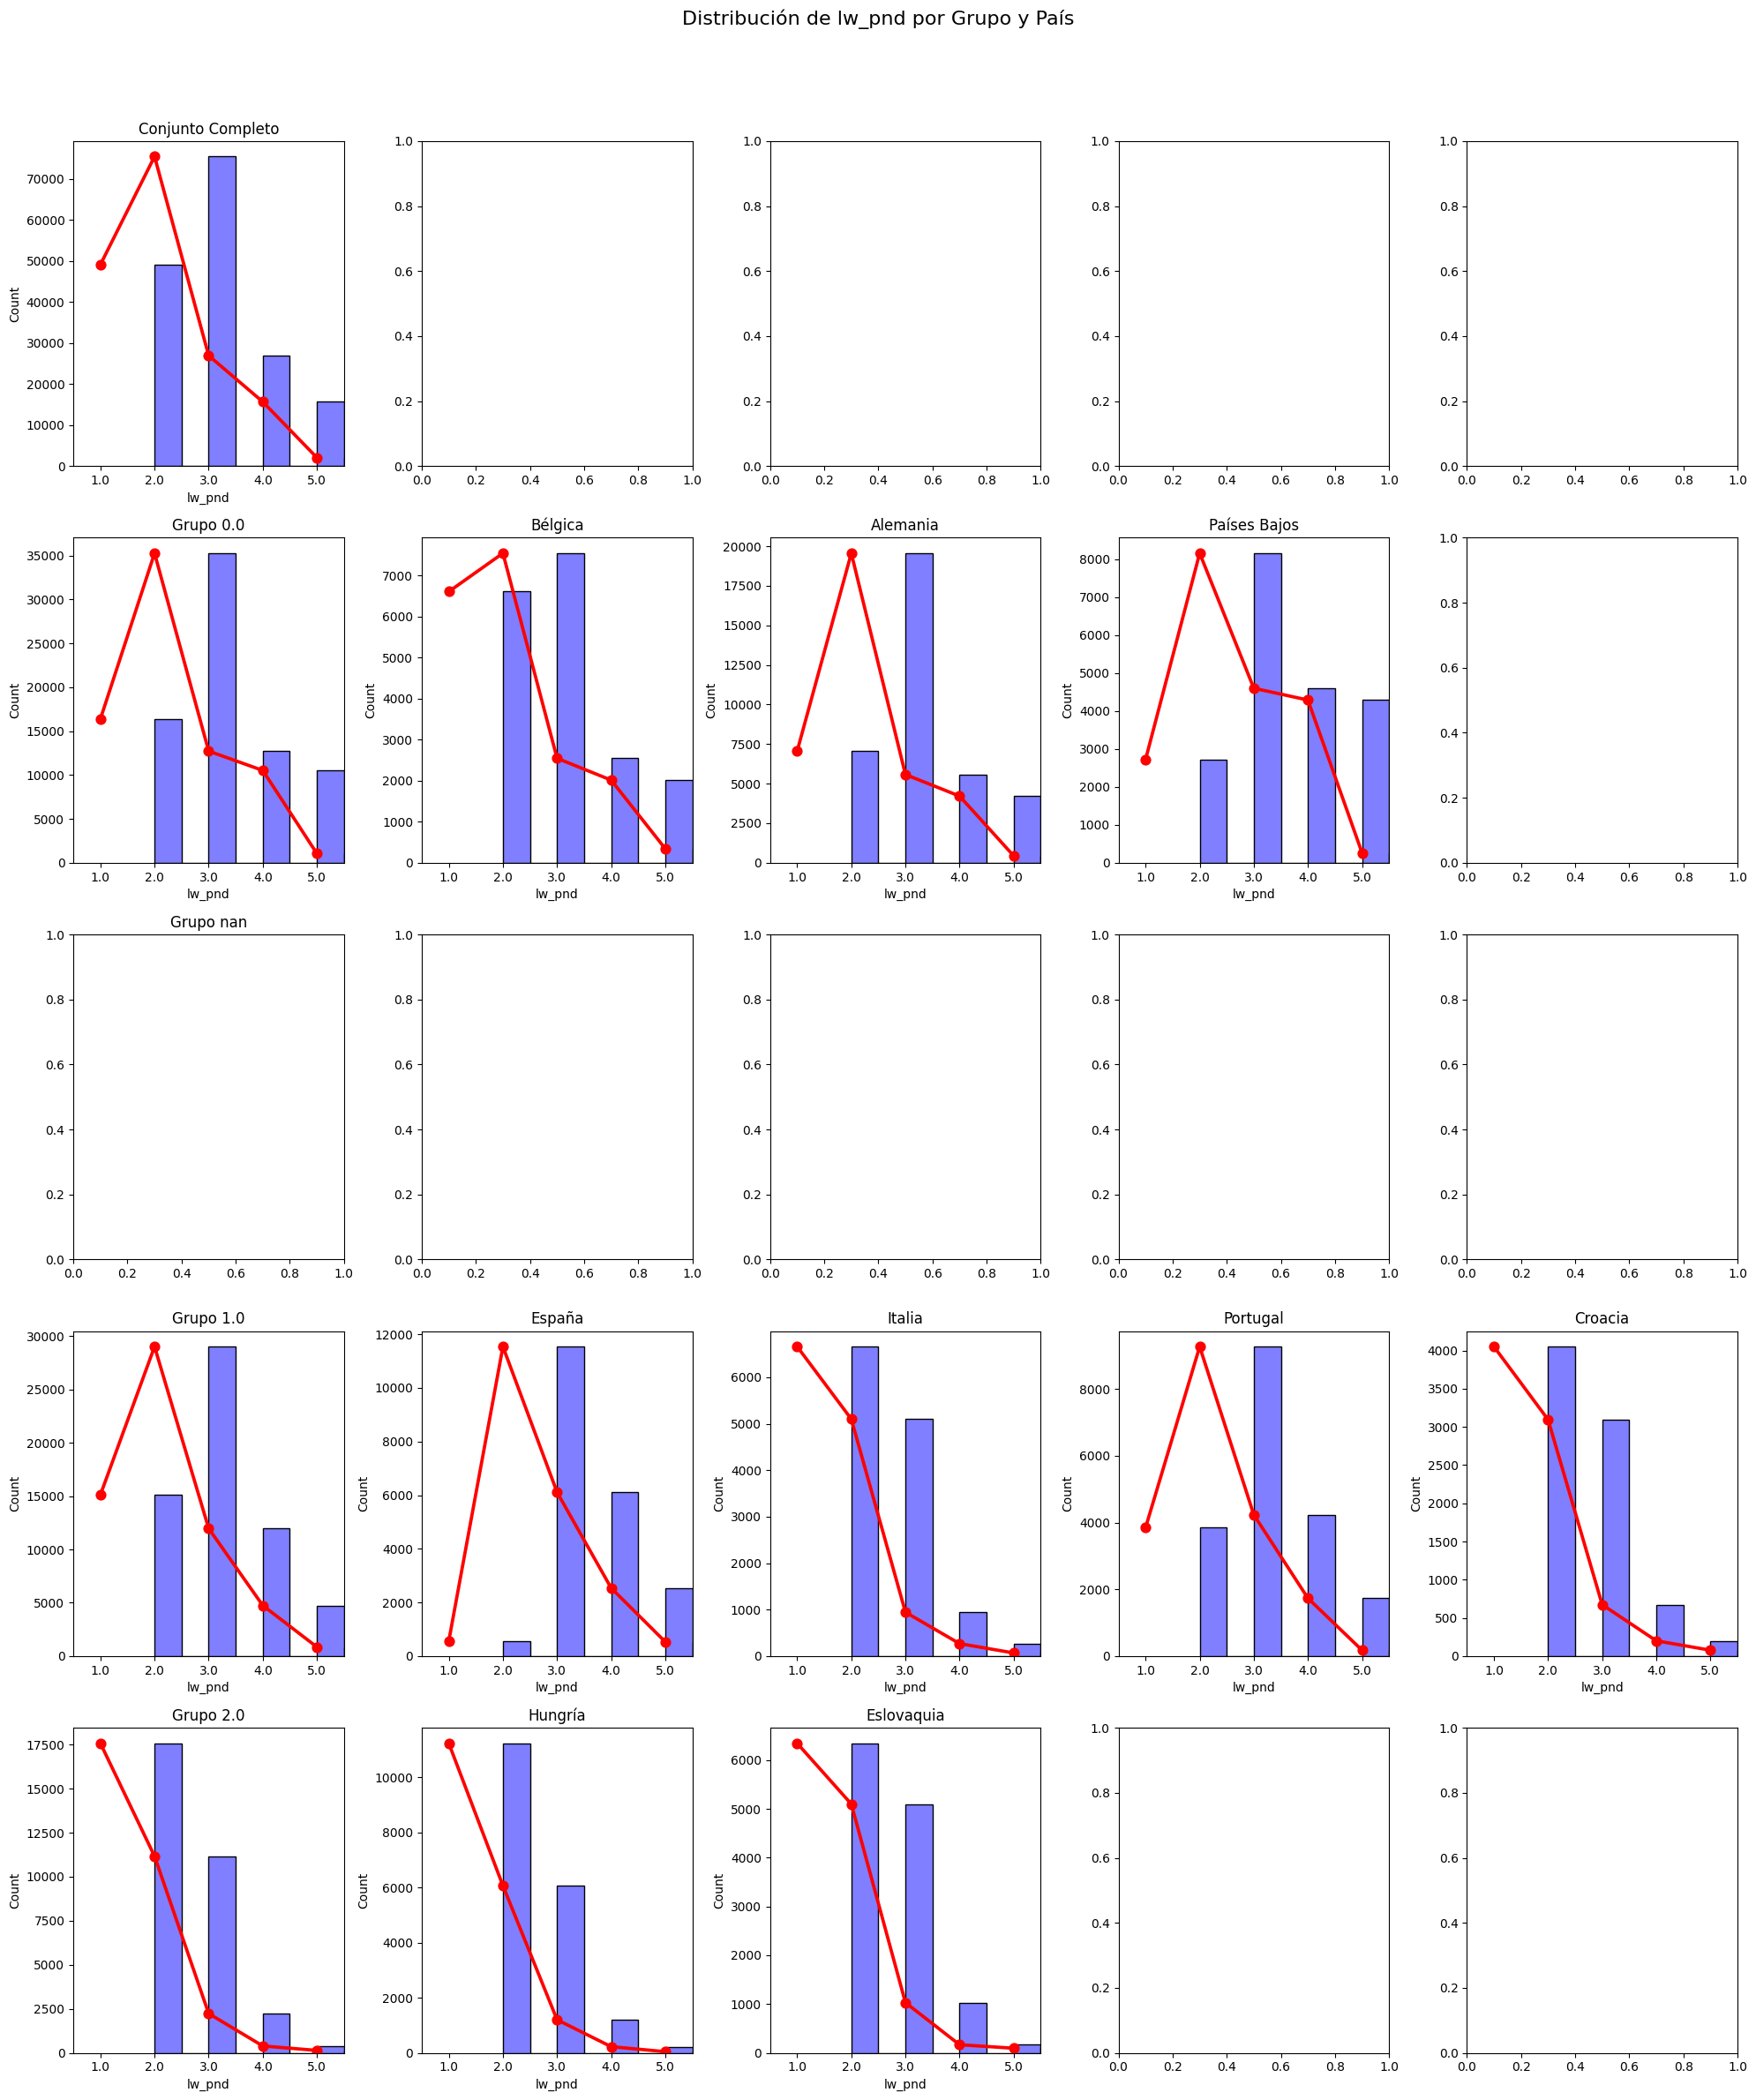

In [59]:
GroupDist(dfeu, 'lw_pnd')

In [60]:
statsgroup(dfeu,'lw_pnd')

Estadísticas para lw_pnd - Conjunto Completo:
count    169099.000000
mean          2.090196
std           0.959173
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max           5.000000
Name: lw_pnd, dtype: float64
Moda: 2.0, Frecuencia: 75416
Varianza: 0.9200128648760499


Estadísticas para lw_pnd - Grupo 0.0:
count    75914.000000
mean         2.269845
std          0.994003
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: lw_pnd, dtype: float64
Moda: 2.0, Frecuencia: 35256
Varianza: 0.9880419529202048


Estadísticas para lw_pnd - País Bélgica (Grupo 0.0):
count    19045.000000
mean         2.052087
std          1.030626
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: lw_pnd, dtype: float64
Moda: 2.0, Frecuencia: 7540
Varianza: 1.0621891165359751


Estadísticas para lw_pnd - País Alemania (Grupo 0.0):
count  

20-'lw_pnd': Escala de 1 a 5, grado de conformidad sobre si las leyes se han de cumplir, siendo 1 la opinión incondicional de que si.

Variable discontinua que describe una distribucion gaussiana asimetríca donde el mayor numero de muestras estan ubicadas en los rangos de la variable comprendidos entre 1 y 2.
Todos los subconjuntos describen funciones sin apenas cambios.

Visto en el analisis descriptivo de nuestras variables y el cambio de distribuciones que tienen muchas de nuestras variables al observarlas por subconjuntos de muestras a razon de grupos de paises, podemos sostener que la clusterizacion de muestras por grupos de paises discriminando por situacion economica similar, es un criterio acertado para discriminar las muestras.
Siguiente paso es el EDA, alojado en la subcarpeta PASO 5.